# 1. Dependencies

## 1.1. System and OS

In [1]:
import os
import sys

## 1.2. CUDA

In [2]:
use_cuda = True

In [3]:
if use_cuda:
    cuda_root = os.path.join(sys.prefix, "targets", "x86_64-linux")
    if os.path.isdir(os.path.join(cuda_root, "include")):
        os.environ.setdefault("CUDA_PATH", cuda_root)

## 1.3. Standard Library

In [4]:
import ast
import gc
import hashlib
import itertools
import math
import time
from typing import Any, cast
from contextlib import contextmanager

## 1.4. Serialization

In [5]:
import json

## 1.5. Parallel

In [6]:
import joblib
from joblib import Parallel, delayed, parallel_config

### 1.5.1. Utilities

In [ ]:
def run_tasks_in_parallel(tasks) -> Any:
    with parallel_config(backend="loky", inner_max_num_threads=1,verbose=0):
        return Parallel(n_jobs=-1, verbose=0)(tasks)

## 1.6. Data Processor

In [8]:
import numpy as np
import pandas as pd
import polars as pl

### 1.6.1. Utilities

In [9]:
def get_all_file_names_in_folder(folder:str,file_extension:str):
    files = []
    for file in os.listdir(folder):
        if len(folder) > 0:
            if file.endswith(f".{file_extension}"):
                files.append(file)
    return sorted(files)

In [ ]:
def filter_file_names(file_names: list[str], filter_word: str) -> list[str]:
    matching_file_names = []
    for file_name in file_names:
        if filter_word in file_name:
            matching_file_names.append(file_name)
    return matching_file_names

In [ ]:
def get_split_folder(folder_name: str, split_name: str) -> str:
    return os.path.join(folder_name, split_name)

In [ ]:
def create_split_folders(folder_name: str, split_names: tuple[str, ...]) -> None:
    for split_name in split_names:
        os.makedirs(get_split_folder(folder_name, split_name), exist_ok=True)

In [ ]:
def get_split_file_paths(folder_name: str, split_name: str) -> list[str]:
    split_folder = get_split_folder(folder_name, split_name)
    return [
        os.path.join(split_folder, file_name)
        for file_name in get_all_file_names_in_folder(split_folder, "parquet")
    ]

In [ ]:
def read_parquet_file(source_folder_name: str, file_name: str) -> pd.DataFrame:
    file_path = os.path.join(source_folder_name, file_name)
    pd.set_option("io.parquet.engine", "pyarrow")
    return pd.read_parquet(file_path)

In [ ]:
def write_dataframe_to_parquet(
    df: pd.DataFrame, target_folder_name: str, file_name: str
) -> str:
    output_path = os.path.join(target_folder_name, file_name)
    df.to_parquet(output_path, engine="pyarrow", compression="snappy", index=False)
    return output_path

In [ ]:
def process_all_splits(
    source_folder_name: str,
    target_folder_name: str,
    split_names: tuple[str, ...],
    process_file,
    *arguments,
) -> None:
    create_split_folders(target_folder_name, split_names)

    for split_name in split_names:
        source_split_folder = get_split_folder(source_folder_name, split_name)
        target_split_folder = get_split_folder(target_folder_name, split_name)
        file_names = get_all_file_names_in_folder(source_split_folder, "parquet")

        run_tasks_in_parallel(
            delayed(process_file)(
                source_split_folder, target_split_folder, file_name, *arguments
            )
            for file_name in file_names
        )

        print(f"{split_name}: {len(file_names)} files written to {target_split_folder}/.")

In [ ]:
def measure_feature_statistics(folder_name: str, split_name: str) -> pd.DataFrame:
    file_paths = get_split_file_paths(folder_name, split_name)

    frame = pl.scan_parquet(file_paths)
    column_names = frame.collect_schema().names()
    measured = frame.select(
        pl.col(column_names).mean().name.prefix("mean_"),
        pl.col(column_names).std().name.prefix("std_"),
    ).collect(engine="streaming").row(0, named=True)

    return pd.DataFrame(
        {
            "mean": {name: measured[f"mean_{name}"] for name in column_names},
            "std": {name: measured[f"std_{name}"] for name in column_names},
        }
    )

In [18]:
def load_label_classes(input_file: str) -> list[str]:
    with open(input_file) as file:
        return json.load(file)

In [19]:
def count_labels_in_file(folder_name: str, file_name: str, label_column: str) -> pd.Series:
    labels = read_parquet_file(folder_name, file_name)
    return labels[label_column].value_counts()

In [20]:
def count_labels_in_folder(folder_name: str, label_column: str) -> pd.Series:
    file_names = get_all_file_names_in_folder(folder_name, "parquet")

    counts_per_file = run_tasks_in_parallel(
        delayed(count_labels_in_file)(folder_name, file_name, label_column)
        for file_name in file_names
    )

    return pd.concat(counts_per_file).groupby(level=0).sum()

## 1.7. Pre-Processing

In [21]:
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import IncrementalPCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

## 1.8. Plotting

In [22]:
import matplotlib
import matplotlib.pyplot as plt

## 1.9. Models

### 1.9.1. K-Nearest Neighbours

In [23]:
if use_cuda:
    from cuml.neighbors import KNeighborsClassifier, NearestNeighbors
else:
    from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors

### 1.9.2. Support Vector Machine

In [24]:
if use_cuda:
    from cuml.svm import SVC
else:
    from sklearn.svm import SVC

### 1.9.3. Random Forest

In [25]:
if use_cuda:
    from cuml.ensemble import RandomForestClassifier
else:
    from sklearn.ensemble import RandomForestClassifier

### 1.9.4. Logistic Regression (Softmax)

In [26]:
import tensorflow as tf
from tensorflow import keras

if use_cuda:
    for gpu in tf.config.list_physical_devices("GPU"):
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    tf.config.set_visible_devices([], "GPU")

I0000 00:00:1790162989.255421    1896 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790162989.791848    1896 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790162991.457102    1896 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1790162992.521593    2052 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that

### 1.9.5. XGBoost

In [27]:
from xgboost import XGBClassifier

## 1.10. Evaluation

In [28]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
)

### 1.10.1. Utilities

In [29]:
def to_features(data) -> np.ndarray:
    if isinstance(data, (pl.DataFrame, pl.Series)):
        data = data.to_numpy()
    return np.ascontiguousarray(data, dtype=np.float32)

In [30]:
def to_labels(data) -> np.ndarray:
    if isinstance(data, (pl.DataFrame, pl.Series)):
        data = data.to_numpy()
    return np.asarray(data).ravel().astype(np.int32)

In [31]:
def to_numpy(data) -> np.ndarray:
    if hasattr(data, "to_numpy"):
        return np.asarray(data.to_numpy()).ravel()
    if hasattr(data, "get"):
        return data.get().ravel()
    return np.asarray(data).ravel()

In [32]:
def to_numpy_2d(data) -> np.ndarray:
    if hasattr(data, "to_numpy"):
        return np.asarray(data.to_numpy())
    if hasattr(data, "get"):
        return np.asarray(data.get())
    return np.asarray(data)

In [33]:
def free_gpu_memory() -> None:
    gc.collect()
    if not use_cuda:
        return
    try:
        import cupy as cp

        cp.get_default_memory_pool().free_all_blocks()
        cp.get_default_pinned_memory_pool().free_all_blocks()
    except Exception:
        pass

In [34]:
@contextmanager
def step(message: str):
    print(f"  {message} ...", end="", flush=True)
    try:
        yield
    except BaseException:
        print(" failed")
        raise
    print(" done")

In [35]:
def progress_bar(done: int, total: int, label: str = "", width: int = 30) -> None:
    filled = width if total <= 0 else int(width * done / total)
    line = f"  [{'#' * filled}{'-' * (width - filled)}] {done:,}/{total:,}"
    if label:
        line += f" {label}"
    print(line.ljust(100), end="\n" if done >= total else "\r", flush=True)

In [36]:
def stratified_subsample(
    x, y, n_samples: int | None, random_state: int, min_per_class: int = 1
) -> tuple[np.ndarray, np.ndarray]:
    labels = to_labels(y)
    total = labels.shape[0]

    if n_samples is None or n_samples >= total:
        return to_features(x), labels

    generator = np.random.default_rng(random_state)
    classes, counts = np.unique(labels, return_counts=True)

    quota = np.floor(counts / total * n_samples).astype(np.int64)
    quota = np.maximum(quota, np.minimum(min_per_class, counts))
    quota = np.minimum(quota, counts)

    selected = []
    for class_id, class_quota in zip(classes, quota):
        class_rows = np.flatnonzero(labels == class_id)
        if class_quota < class_rows.size:
            class_rows = generator.choice(class_rows, size=int(class_quota), replace=False)
        selected.append(class_rows)

    keep = np.zeros(total, dtype=bool)
    keep[np.sort(np.concatenate(selected))] = True
    subset = x.filter(pl.Series(keep)) if isinstance(x, pl.DataFrame) else x[keep]

    print(f"  subsampled {total:,} -> {int(keep.sum()):,} rows across {classes.size} classes")
    return to_features(subset), labels[keep]

In [37]:
def build_grid(*value_lists) -> list[tuple]:
    return [tuple(combination) for combination in itertools.product(*value_lists)]

In [38]:
def run_search(
    combinations: list[tuple],
    parameter_names: tuple[str, ...],
    fit_and_score,
    search_data: tuple,
    score_column: str,
) -> pd.DataFrame:
    rows = []
    total = len(combinations)

    for number, combination in enumerate(combinations, start=1):
        parameters = dict(zip(parameter_names, combination))
        described = " ".join(f"{name}={value}" for name, value in parameters.items())
        print(f"[{number}/{total}] {described}")

        try:
            measurements = fit_and_score(*combination, *search_data)
        except Exception as error:
            reason = f"{type(error).__name__}: {str(error).splitlines()[0][:120]}"
            print(f"  !! failed, skipped: {reason}")
            free_gpu_memory()
            rows.append({**parameters, "error": reason})
            continue

        rows.append({**parameters, **measurements})
        print(f"  {score_column}={measurements[score_column]:.4f}")

    results = pd.DataFrame(rows)
    failed = int(results["error"].notna().sum()) if "error" in results else 0
    print(f"Scored {total - failed} of {total} combinations" + (f", {failed} failed." if failed else "."))

    if score_column not in results:
        return results
    return results.sort_values(score_column, ascending=False, ignore_index=True)

In [39]:
def save_search_results(results: pd.DataFrame, file_name: str, folder_name: str) -> str:
    os.makedirs(folder_name, exist_ok=True)
    file_path = os.path.join(folder_name, file_name)
    results.to_csv(file_path, index=False)
    print(f"Saved search results to {file_path}.")
    return file_path

In [40]:
def get_best_hyperparameter(results: pd.DataFrame, score_column: str) -> dict:
    if score_column not in results:
        raise ValueError(
            f"None of the {len(results)} combinations in this grid was scored — every one of them "
            "failed, so there is nothing to choose between. The `error` column says why."
        )

    best = results.sort_values(score_column, ascending=False).iloc[0]
    print(f"Best by {score_column}:")
    for name, value in best.items():
        print(f"  {name:>18} = {value}")
    return best.to_dict()

In [41]:
def get_temporary_model_path(file_path: str) -> str:
    stem, extension = os.path.splitext(file_path)
    return f"{stem}.tmp{extension}"

In [42]:
def dump_trained_model(model, name: str, subfolder: str, folder_name: str) -> str:
    target_folder = os.path.join(folder_name, subfolder)
    os.makedirs(target_folder, exist_ok=True)
    file_path = os.path.join(target_folder, name)
    temporary_path = get_temporary_model_path(file_path)
    joblib.dump(model, temporary_path)
    os.replace(temporary_path, file_path)
    return file_path

In [43]:
def load_trained_model(name: str, subfolder: str, folder_name: str):
    return joblib.load(os.path.join(folder_name, subfolder, name))

In [44]:
def save_array_atomically(array: np.ndarray, file_path: str) -> None:
    temporary_path = file_path + ".tmp"
    with open(temporary_path, "wb") as file:
        np.save(file, array)
    os.replace(temporary_path, file_path)

In [45]:
def predict_in_chunks(
    predict_chunk, x, cache_folder: str, prefix: str, chunk_size: int
) -> np.ndarray:
    os.makedirs(cache_folder, exist_ok=True)
    total = len(x)
    if total == 0:
        print("Nothing to predict (0 rows).")
        return np.empty(0, dtype=np.int32)

    n_chunks = math.ceil(total / chunk_size)
    print(f"Predicting {total:,} rows in {n_chunks:,} chunks of {chunk_size:,} into {cache_folder}/")

    file_paths, computed, cached = [], 0, 0
    for number, start in enumerate(range(0, total, chunk_size), start=1):
        file_path = os.path.join(cache_folder, f"{prefix}_{number:05d}.npy")
        file_paths.append(file_path)

        if os.path.exists(file_path):
            cached += 1
        else:
            rows = (
                x.slice(start, chunk_size)
                if isinstance(x, (pl.DataFrame, pl.Series))
                else x[start : start + chunk_size]
            )
            save_array_atomically(np.asarray(predict_chunk(rows), dtype=np.int32), file_path)
            computed += 1

        progress_bar(number, n_chunks, f"chunks ({computed:,} computed, {cached:,} cached)")

    return np.concatenate([np.load(file_path) for file_path in file_paths])

In [46]:
def load_prediction_chunks(cache_folder: str) -> np.ndarray:
    if not os.path.isdir(cache_folder):
        raise FileNotFoundError(cache_folder)

    file_names = get_all_file_names_in_folder(cache_folder, "npy")
    if not file_names:
        raise FileNotFoundError(f"No prediction chunks in {cache_folder}/.")

    return np.concatenate(
        [np.load(os.path.join(cache_folder, file_name)) for file_name in file_names]
    )

In [47]:
def get_present_labels(true, pred) -> list[int]:
    return sorted({int(x) for x in np.unique(true)} | {int(x) for x in np.unique(pred)})

In [48]:
def evaluate(pred, true, labels: list[int] | None = None) -> pd.DataFrame:
    if labels is None:
        labels = get_present_labels(true, pred)

    return pd.DataFrame(
        [
            {
                "accuracy": accuracy_score(true, pred),
                "precision_macro": precision_score(
                    true, pred, labels=labels, average="macro", zero_division=0
                ),
                "recall_macro": recall_score(
                    true, pred, labels=labels, average="macro", zero_division=0
                ),
                "f1_macro": f1_score(
                    true, pred, labels=labels, average="macro", zero_division=0
                ),
            }
        ]
    )

In [49]:
def get_classification_report(pred, true, class_names: list[str]) -> pd.DataFrame:
    labels = get_present_labels(true, pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        true, pred, labels=labels, average=None, zero_division=0
    )
    return pd.DataFrame(
        {
            "class": [class_names[label] for label in labels],
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": support,
        }
    )

In [50]:
def get_confusion_matrix(pred, true, class_names: list[str]) -> pd.DataFrame:
    labels = get_present_labels(true, pred)
    present_names = [class_names[label] for label in labels]
    return pd.DataFrame(
        confusion_matrix(true, pred, labels=labels), index=present_names, columns=present_names
    )

In [51]:
def get_evaluation_results(
    cache_folder: str, true_labels, labels: list[int] | None = None
) -> pd.DataFrame:
    pred = load_prediction_chunks(cache_folder)
    true = to_labels(true_labels)

    if len(pred) != len(true):
        raise ValueError(
            f"{len(pred):,} predictions against {len(true):,} labels in {cache_folder}/ — "
            "the cache belongs to a different split, or was written by a different run."
        )
    return evaluate(pred=pred, true=true, labels=labels)

## 1.11. Re-entry

**Run this cell after section 1 and you can go straight to section 19.** A full top-to-bottom run does not need it.

In [ ]:
PATH_NOTEBOOK = "mlids.ipynb"

In [53]:
def is_definition_cell(source: str) -> bool:
    try:
        tree = ast.parse(source)
    except SyntaxError:
        return False
    if not tree.body:
        return False

    for node in tree.body:
        if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef,
                             ast.Import, ast.ImportFrom)):
            continue
        if isinstance(node, (ast.Assign, ast.AnnAssign)):
            targets = node.targets if isinstance(node, ast.Assign) else [node.target]
            if not all(isinstance(t, ast.Name) for t in targets):
                return False
            if all(t.id.isupper() for t in targets):
                continue
            if node.value is not None and not any(
                isinstance(child, (ast.Call, ast.Await, ast.Yield))
                for child in ast.walk(node.value)
            ):
                continue
        return False
    return True

In [54]:
def read_notebook_cells(notebook_file: str = PATH_NOTEBOOK) -> list[tuple[int, int, str, str]]:
    if not os.path.exists(notebook_file):
        raise FileNotFoundError(
            f"{notebook_file} not found. Set PATH_NOTEBOOK to this notebook's file name, and note"
            " that it is read from disk — save the notebook before calling this."
        )

    with open(notebook_file) as file:
        cells = json.load(file)["cells"]

    section, out = 0, []
    for number, cell in enumerate(cells):
        source = "".join(cell["source"])
        if cell["cell_type"] == "markdown":
            heading = source.lstrip().split("\n", 1)[0]
            if heading.startswith("# ") and heading[2:].split(".", 1)[0].strip().isdigit():
                section = int(heading[2:].split(".", 1)[0])
        out.append((number, section, cell["cell_type"], source))
    return out

In [55]:
def load_notebook_definitions(
    notebook_file: str = PATH_NOTEBOOK,
    namespace: dict | None = None,
    skip_sections: tuple[int, ...] = (1,),
    quiet: bool = False,
) -> list[int]:
    namespace = globals() if namespace is None else namespace

    pending = [
        (number, source)
        for number, section, cell_type, source in read_notebook_cells(notebook_file)
        if cell_type == "code" and section not in skip_sections and is_definition_cell(source)
    ]

    loaded = 0
    while pending:
        failed = []
        for number, source in pending:
            try:
                exec(compile(source, f"{notebook_file} cell {number}", "exec"), namespace)
            except NameError:
                failed.append((number, source))
        loaded += len(pending) - len(failed)
        if len(failed) == len(pending):
            break
        pending = failed

    if not quiet:
        print(f"  {loaded} definition cells loaded", end="")
        print(f", {len(pending)} still unresolved" if pending else "")
    return [number for number, _ in pending]

In [56]:
def find_trained_model_name(subfolder: str, folder_name: str | None = None) -> str | None:
    if folder_name is None:
        folder_name = globals().get("PATH_FOLDER_MODEL", "trained-model")

    folder = os.path.join(folder_name, subfolder)
    if not os.path.isdir(folder):
        return None

    file_names = sorted(
        name
        for name in os.listdir(folder)
        if not name.startswith(".")
        and ".tmp." not in name
        and os.path.getsize(os.path.join(folder, name)) > 0
    )
    if not file_names:
        return None
    if len(file_names) > 1:
        raise ValueError(
            f"{folder}/ holds {len(file_names)} models: {file_names}. Assign the one you want to"
            f" the matching `*_model_name` by hand, or delete the others."
        )
    return file_names[0]

In [57]:
def restore_notebook_state(
    notebook_file: str = PATH_NOTEBOOK,
    namespace: dict | None = None,
    split_name: str = "test",
) -> dict[str, Any]:
    namespace = globals() if namespace is None else namespace

    print(f"Reading {notebook_file}")
    load_notebook_definitions(notebook_file, namespace)

    restored: dict[str, Any] = {}
    missing: list[str] = []

    def restore(name: str, build, needs: str):
        if not os.path.exists(needs):
            missing.append(f"{name} (no {needs})")
            return
        namespace[name] = restored[name] = build()

    restore("CLASS_NAMES",
            lambda: namespace["load_label_classes"](namespace["PATH_LABEL_ENCODER"]),
            namespace["PATH_LABEL_ENCODER"])
    restore("IPCA_COMPONENTS",
            lambda: namespace["choose_component_count"](
                namespace["get_variance_curve"](namespace["PATH_IPCA"])),
            namespace["PATH_IPCA"])
    restore("test_y",
            lambda: namespace["load_split_frame"](
                namespace["PATH_FOLDER_ENCODED_LABEL"], split_name)[namespace["LABEL_COLUMN"]],
            namespace["PATH_FOLDER_ENCODED_LABEL"])

    for prefix, subfolder in (("knn", "KNN"), ("svm", "SVM"), ("rf", "RF"),
                              ("logreg", "LOGREG"), ("xgb", "XGB")):
        model_name = find_trained_model_name(subfolder, namespace.get("PATH_FOLDER_MODEL"))
        if model_name is None:
            missing.append(f"{prefix}_model_name (nothing saved for {subfolder})")
            continue
        namespace[f"{prefix}_model_name"] = restored[f"{prefix}_model_name"] = model_name

    unresolved = load_notebook_definitions(notebook_file, namespace, quiet=True)

    for name, value in restored.items():
        shown = value if not hasattr(value, "__len__") or isinstance(value, str) else f"{len(value):,} items"
        print(f"  {name:<18} = {shown}")
    if missing:
        print("  missing:")
        for item in missing:
            print(f"    - {item}")
    if unresolved:
        print(f"  cells that would not load: {unresolved}")

    restored["missing"] = missing
    return restored

In [58]:
restore_notebook_state()

Reading mlids-tidied.ipynb
  193 definition cells loaded, 4 still unresolved
  CLASS_NAMES        = 15 items
  IPCA_COMPONENTS    = 24
  test_y             = 3,246,594 items
  knn_model_name     = knn-k-11-m-manhattan-w-uniform.pkl
  svm_model_name     = svm-k-rbf-c-10.0-g-0.1.pkl
  rf_model_name      = rf-n-300-d-24-f-log2.pkl
  logreg_model_name  = logreg-lr-0.01-bs-2048-l2-0.0001.keras
  xgb_model_name     = xgb-d-6.0-lr-0.1-c-0.6.json


{'CLASS_NAMES': ['Benign',
  'Bot',
  'Brute Force -Web',
  'Brute Force -XSS',
  'DDOS attack-HOIC',
  'DDOS attack-LOIC-UDP',
  'DDoS attacks-LOIC-HTTP',
  'DoS attacks-GoldenEye',
  'DoS attacks-Hulk',
  'DoS attacks-SlowHTTPTest',
  'DoS attacks-Slowloris',
  'FTP-BruteForce',
  'Infilteration',
  'SQL Injection',
  'SSH-Bruteforce'],
 'IPCA_COMPONENTS': 24,
 'test_y': shape: (3_246_594,)
 Series: 'label' [i64]
 [
 	11
 	11
 	11
 	11
 	11
 	…
 	0
 	0
 	0
 	0
 	0
 ],
 'knn_model_name': 'knn-k-11-m-manhattan-w-uniform.pkl',
 'svm_model_name': 'svm-k-rbf-c-10.0-g-0.1.pkl',
 'rf_model_name': 'rf-n-300-d-24-f-log2.pkl',
 'logreg_model_name': 'logreg-lr-0.01-bs-2048-l2-0.0001.keras',
 'xgb_model_name': 'xgb-d-6.0-lr-0.1-c-0.6.json',
 'missing': []}

# 2. Reformatting

## 2.1. Change CSV to Parquet

### 2.1.1. Settings

In [22]:
PATH_FOLDER_CSV = "cse-cic-ids2018"
PATH_FOLDER_RAW = "data-raw"

In [23]:
CHUNK_SIZE = 100_000

In [24]:
LABEL_COLUMN = "label"
FEATURE_DTYPE = "float32"

In [25]:
COLUMNS_TO_DROP = {
    "flow id",
    "src ip",
    "source ip",
    "src port",
    "source port",
    "dst ip",
    "destination ip",
    "timestamp",
}

### 2.1.2. Column Schema

In [26]:
def normalize_column_names(column_names) -> list[str]:
    columns = []
    for column in column_names:
        columns.append(str(column).strip().lower())
    return columns

In [27]:
def exclude_unwanted_columns(
    column_names: list[str], columns_to_drop: set[str] = COLUMNS_TO_DROP
) -> list[str]:
    remaining_columns = []
    for column in column_names:
        if column not in columns_to_drop:
            remaining_columns.append(column)
    return remaining_columns

In [28]:
def read_csv_column_names(source_folder_name: str, file_name: str) -> list[str]:
    file_path = os.path.join(source_folder_name, file_name)
    header_only = pd.read_csv(file_path, nrows=0)
    return normalize_column_names(header_only.columns)

In [29]:
def create_column_schema(
    source_folder_name: str, columns_to_drop: set[str] = COLUMNS_TO_DROP
) -> list[str]:
    column_schema: list[str] = []
    for file_name in get_all_file_names_in_folder(source_folder_name, "csv"):
        file_columns = read_csv_column_names(source_folder_name, file_name)
        for column_name in exclude_unwanted_columns(file_columns, columns_to_drop):
            if column_name not in column_schema:
                column_schema.append(column_name)
    return column_schema

In [30]:
column_schema = create_column_schema(PATH_FOLDER_CSV)
print(f"{len(column_schema)} columns: {column_schema[:3]} ... {column_schema[-2:]}")

79 columns: ['dst port', 'protocol', 'flow duration'] ... ['idle min', 'label']


### 2.1.3. Cleaning One Chunk

In [31]:
def standardize_column_names(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = normalize_column_names(df.columns)
    return df

In [32]:
def align_to_column_schema(df: pd.DataFrame, column_schema: list[str]) -> pd.DataFrame:
    return df.reindex(columns=column_schema)

In [ ]:
def cast_features_to_numeric(
    df: pd.DataFrame, label_column: str = LABEL_COLUMN, datatype: Any = FEATURE_DTYPE
) -> pd.DataFrame:
    feature_columns = [name for name in df.columns if name != label_column]
    df[feature_columns] = df[feature_columns].apply(pd.to_numeric, errors="coerce").astype(datatype)
    return df

In [86]:
def drop_invalid_label_rows(df: pd.DataFrame, label_column: str = LABEL_COLUMN) -> pd.DataFrame:
    label_values = df[label_column].astype("string").str.strip().str.lower()
    is_repeated_header = label_values == label_column
    return df[~is_repeated_header].dropna(subset=[label_column])

In [ ]:
def clean_chunk(df: pd.DataFrame, column_schema: list[str]) -> pd.DataFrame:
    df = standardize_column_names(df)
    df = align_to_column_schema(df, column_schema)
    df = cast_features_to_numeric(df)
    df = drop_invalid_label_rows(df)
    return df

### 2.1.4. Writing Parquet Files

In [89]:
def build_parquet_file_name(csv_file_name: str, chunk_number: int) -> str:
    base_name = os.path.splitext(csv_file_name)[0]
    return f"{base_name}_{chunk_number:05d}.parquet"

### 2.1.5. Converting One CSV File

In [90]:
def read_csv_in_chunks(source_folder_name: str, file_name: str, chunk_size: int = CHUNK_SIZE):
    file_path = os.path.join(source_folder_name, file_name)
    return pd.read_csv(file_path, chunksize=chunk_size, low_memory=False)

In [91]:
def convert_csv_file_to_parquet(
    source_folder_name: str,
    target_folder_name: str,
    file_name: str,
    column_schema: list[str],
    chunk_size: int = CHUNK_SIZE,
) -> int:
    written_files = 0
    for chunk_number, chunk in enumerate(
        read_csv_in_chunks(source_folder_name, file_name, chunk_size), start=1
    ):
        cleaned_chunk = clean_chunk(chunk, column_schema)
        write_dataframe_to_parquet(
            cleaned_chunk,
            target_folder_name,
            build_parquet_file_name(file_name, chunk_number),
        )
        written_files += 1
    return written_files

### 2.1.6. Converting Every CSV File

In [99]:
def convert_all_csv_files_to_parquet(
    source_folder_name: str,
    target_folder_name: str,
    chunk_size: int = CHUNK_SIZE,
) -> None:
    csv_file_names = get_all_file_names_in_folder(source_folder_name, "csv")
    column_schema = create_column_schema(source_folder_name)
    os.makedirs(target_folder_name, exist_ok=True)

    written_per_file: list[int] = run_tasks_in_parallel(
        delayed(convert_csv_file_to_parquet)(
            source_folder_name,
            target_folder_name,
            file_name,
            column_schema,
            chunk_size,
        )
        for file_name in csv_file_names
    )

    print(
        f"Converted {len(csv_file_names)} CSV files "
        f"into {sum(written_per_file)} Parquet files in {target_folder_name}/."
    )

### 2.1.7. Run the Conversion

In [ ]:
convert_all_csv_files_to_parquet(PATH_FOLDER_CSV, PATH_FOLDER_RAW)

# 3. Exploratory Data Analysis (EDA)

# 4. Transform Infinite Values to NaN

## 4.1. Settings

In [ ]:
PATH_FOLDER_NO_INF = "data-no-inf"

## 4.2. Replacing the Infinite Values in One File

In [ ]:
def replace_infinite_values(df: pd.DataFrame) -> pd.DataFrame:
    numeric_columns = df.select_dtypes(include=np.number).columns
    df[numeric_columns] = df[numeric_columns].replace([np.inf, -np.inf], np.nan)
    return df

In [ ]:
def replace_infinite_values_in_file(
    source_folder_name: str, target_folder_name: str, file_name: str
) -> str:
    df = read_parquet_file(source_folder_name, file_name)
    df = replace_infinite_values(df)
    return write_dataframe_to_parquet(df, target_folder_name, file_name)

## 4.3. Replacing Them in Every File

In [ ]:
def replace_infinite_values_in_folder(source_folder_name: str, target_folder_name: str) -> None:
    file_names = get_all_file_names_in_folder(source_folder_name, "parquet")
    os.makedirs(target_folder_name, exist_ok=True)

    written_files = run_tasks_in_parallel(
        delayed(replace_infinite_values_in_file)(source_folder_name, target_folder_name, file_name)
        for file_name in file_names
    )

    print(f"Rewrote {len(written_files)} Parquet files into {target_folder_name}/.")

## 4.4. Run the Replacement

In [ ]:
replace_infinite_values_in_folder(PATH_FOLDER_RAW, PATH_FOLDER_NO_INF)

## 4.5. Check the Result

In [ ]:
def count_infinite_values_in_file(source_folder_name: str, file_name: str) -> pd.Series:
    df = read_parquet_file(source_folder_name, file_name)
    numeric_columns = df.select_dtypes(include=np.number)
    return np.isinf(numeric_columns).sum()

In [ ]:
def count_infinite_values(source_folder_name: str) -> pd.Series:
    file_names = get_all_file_names_in_folder(source_folder_name, "parquet")

    counts_per_file: list[pd.Series] = run_tasks_in_parallel(
        delayed(count_infinite_values_in_file)(source_folder_name, file_name)
        for file_name in file_names
    )

    counts_per_column = sum(counts_per_file, start=pd.Series(dtype="int64"))
    print(
        f"{int(counts_per_column.sum()):,} infinite values "
        f"in {len(file_names)} Parquet files in {source_folder_name}/."
    )
    return counts_per_column[counts_per_column > 0]

**Before the replacement:**

In [ ]:
count_infinite_values(PATH_FOLDER_RAW)

**After the replacement:**

In [ ]:
count_infinite_values(PATH_FOLDER_NO_INF)

# 5. Split Datasets

## 5.1. Settings

In [ ]:
PATH_FOLDER_SPLIT_FEATURE = "data-split-feature"
PATH_FOLDER_SPLIT_LABEL = "data-split-label"

In [ ]:
SPLIT_NAMES = ("train", "dev", "test")

In [ ]:
DEV_SIZE = 0.20
TEST_SIZE = 0.20
TRAIN_SIZE = 1.0 - DEV_SIZE - TEST_SIZE

In [ ]:
RANDOM_STATE = 42

In [ ]:
COLLECTION_DAYS = (
    "2018-02-14",
    "2018-02-15",
    "2018-02-16",
    "2018-02-20",
    "2018-02-21",
    "2018-02-22",
    "2018-02-23",
    "2018-02-28",
    "2018-03-01",
    "2018-03-02",
)

## 5.2. Where Each File Goes

In [ ]:
def create_feature_and_label_folders(
    features_folder_name: str, labels_folder_name: str, split_names: tuple[str, ...] = SPLIT_NAMES
) -> None:
    create_split_folders(features_folder_name, split_names)
    create_split_folders(labels_folder_name, split_names)

## 5.3. Splitting the Rows of One File

In [ ]:
def split_rows(
    df: pd.DataFrame,
    dev_size: float = DEV_SIZE,
    test_size: float = TEST_SIZE,
    label_column: str = LABEL_COLUMN,
    random_state: int = RANDOM_STATE,
) -> dict[str, pd.DataFrame]:
    held_out_size = dev_size + test_size
    if not 0.0 < held_out_size < 1.0:
        raise ValueError("dev_size + test_size must leave rows for training, so it must be < 1.0")

    train_rows, held_out_rows = train_test_split(
        df,
        test_size=held_out_size,
        random_state=random_state,
        stratify=df[label_column],
    )
    dev_rows, test_rows = train_test_split(
        held_out_rows,
        test_size=test_size / held_out_size,
        random_state=random_state,
        stratify=held_out_rows[label_column],
    )
    return {"train": train_rows, "dev": dev_rows, "test": test_rows}

## 5.4. Writing One Split

In [ ]:
def write_split_to_parquet(
    rows: pd.DataFrame,
    split_name: str,
    file_name: str,
    features_folder_name: str,
    labels_folder_name: str,
    label_column: str = LABEL_COLUMN,
) -> None:
    features = rows.drop(columns=[label_column])
    labels = rows[[label_column]]

    write_dataframe_to_parquet(
        features, get_split_folder(features_folder_name, split_name), file_name
    )
    write_dataframe_to_parquet(
        labels, get_split_folder(labels_folder_name, split_name), file_name
    )

## 5.5. Splitting One File

In [ ]:
def split_file(
    source_folder_name: str,
    file_name: str,
    features_folder_name: str,
    labels_folder_name: str,
    dev_size: float = DEV_SIZE,
    test_size: float = TEST_SIZE,
    label_column: str = LABEL_COLUMN,
    random_state: int = RANDOM_STATE,
) -> None:
    df = read_parquet_file(source_folder_name, file_name)
    rows_per_split = split_rows(df, dev_size, test_size, label_column, random_state)

    for split_name, rows in rows_per_split.items():
        write_split_to_parquet(
            rows, split_name, file_name, features_folder_name, labels_folder_name, label_column
        )

## 5.6. Splitting One Day

In [ ]:
def split_one_day(
    source_folder_name: str,
    features_folder_name: str,
    labels_folder_name: str,
    day: str,
    dev_size: float = DEV_SIZE,
    test_size: float = TEST_SIZE,
    label_column: str = LABEL_COLUMN,
    random_state: int = RANDOM_STATE,
) -> None:
    file_names = filter_file_names(
        get_all_file_names_in_folder(source_folder_name, "parquet"), day
    )
    if not file_names:
        raise ValueError(f"No Parquet files found for {day} in {source_folder_name}/.")

    create_feature_and_label_folders(features_folder_name, labels_folder_name)

    run_tasks_in_parallel(
        delayed(split_file)(
            source_folder_name,
            file_name,
            features_folder_name,
            labels_folder_name,
            dev_size,
            test_size,
            label_column,
            random_state,
        )
        for file_name in file_names
    )

    print(f"Split {len(file_names)} files of {day} into {', '.join(SPLIT_NAMES)}.")

## 5.7. Run the Split

In [ ]:
for day in COLLECTION_DAYS:
    split_one_day(
        PATH_FOLDER_NO_INF, PATH_FOLDER_SPLIT_FEATURE, PATH_FOLDER_SPLIT_LABEL, day
    )

## 5.8. Check the Result

In [ ]:
def summarize_splits(labels_folder_name: str = PATH_FOLDER_SPLIT_LABEL) -> pd.DataFrame:
    counts_per_split = {
        split_name: count_labels_in_folder(
            get_split_folder(labels_folder_name, split_name), LABEL_COLUMN
        )
        for split_name in SPLIT_NAMES
    }

    table = pd.DataFrame(counts_per_split).fillna(0).astype(int)
    table["total"] = table[list(SPLIT_NAMES)].sum(axis=1)
    for split_name in SPLIT_NAMES:
        table[f"{split_name} %"] = (table[split_name] / table["total"] * 100).round(1)

    print(
        f"{table['total'].sum():,} rows over {len(table)} classes. "
        f"Target share: {TRAIN_SIZE:.0%} train / {DEV_SIZE:.0%} dev / {TEST_SIZE:.0%} test."
    )
    return table.sort_values("total", ascending=False)

In [ ]:
summarize_splits(PATH_FOLDER_SPLIT_LABEL)

# 6. Imputation

## 6.1. Settings

In [ ]:
PATH_CACHE = "cache"
PATH_MEDIANS = os.path.join(PATH_CACHE, "median-imputer.json")

In [ ]:
PATH_FOLDER_IMPUTED = "data-imputed"

In [ ]:
FIT_SPLIT = "train"

In [ ]:
MEDIAN_FALLBACK = 0.0

## 6.2. Measuring the Medians

In [ ]:
def compute_medians(file_paths: list[str]) -> dict[str, float | None]:
    lazy_frame = pl.scan_parquet(file_paths)
    schema = lazy_frame.collect_schema()

    numeric_columns = []
    for column, dtype in zip(schema.names(), schema.dtypes()):
        if dtype.is_numeric():
            numeric_columns.append(column)

    medians = lazy_frame.select(pl.col(numeric_columns).median()).collect(engine="streaming")
    return medians.row(0, named=True)

In [ ]:
def replace_empty_medians(
    medians: dict[str, float | None], fallback: float = MEDIAN_FALLBACK
) -> dict[str, float]:
    complete_medians = {}
    empty_columns = []

    for column, median in medians.items():
        if median is None:
            empty_columns.append(column)
            complete_medians[column] = fallback
        else:
            complete_medians[column] = float(median)

    if empty_columns:
        print(
            f"Warning: {len(empty_columns)} columns had no value to take a median from and were "
            f"given {fallback}: {empty_columns}"
        )
    return complete_medians

## 6.3. Storing the Medians

In [ ]:
def save_medians(medians: dict[str, float], output_file: str) -> str:
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    with open(output_file, "w") as file:
        json.dump(medians, file, indent=4)
    return output_file

In [ ]:
def load_medians(input_file: str) -> dict[str, float]:
    with open(input_file) as file:
        return json.load(file)

## 6.4. Fit the Imputer

In [ ]:
def create_median_imputer(
    source_folder_name: str, output_file: str, split_name: str = FIT_SPLIT
) -> dict[str, float]:
    file_paths = get_split_file_paths(source_folder_name, split_name)
    medians = compute_medians(file_paths)
    medians = replace_empty_medians(medians)
    save_medians(medians, output_file)

    print(
        f"Fitted {len(medians)} medians on the {split_name} split "
        f"({len(file_paths)} files) and saved them to {output_file}."
    )
    return medians

In [ ]:
medians = create_median_imputer(PATH_FOLDER_SPLIT_FEATURE, PATH_MEDIANS)
pd.Series(medians, name="median")

## 6.5. Filling One File

In [ ]:
def fill_missing_values(df: pd.DataFrame, medians: dict[str, float]) -> pd.DataFrame:
    return df.fillna(medians)

In [ ]:
def impute_file(
    source_folder_name: str, target_folder_name: str, file_name: str, medians: dict[str, float]
) -> str:
    df = read_parquet_file(source_folder_name, file_name)
    df = fill_missing_values(df, medians)
    return write_dataframe_to_parquet(df, target_folder_name, file_name)

## 6.6. Filling Every Split

In [ ]:
def impute_all_splits(
    source_folder_name: str,
    target_folder_name: str,
    medians_file: str = PATH_MEDIANS,
    split_names: tuple[str, ...] = SPLIT_NAMES,
) -> None:
    medians = load_medians(medians_file)
    process_all_splits(
        source_folder_name, target_folder_name, split_names, impute_file, medians
    )

## 6.7. Run the Imputation

In [ ]:
impute_all_splits(PATH_FOLDER_SPLIT_FEATURE, PATH_FOLDER_IMPUTED)

## 6.8. Check the Result

In [ ]:
def count_missing_values_in_file(folder_name: str, file_name: str) -> pd.Series:
    df = read_parquet_file(folder_name, file_name)
    return df.isna().sum()

In [ ]:
def count_missing_values_in_split(folder_name: str, split_name: str) -> pd.Series:
    split_folder = get_split_folder(folder_name, split_name)
    file_names = get_all_file_names_in_folder(split_folder, "parquet")

    counts_per_file: list[pd.Series] = run_tasks_in_parallel(
        delayed(count_missing_values_in_file)(split_folder, file_name)
        for file_name in file_names
    )
    return sum(counts_per_file, start=pd.Series(dtype="int64"))

In [ ]:
def summarize_missing_values(
    folder_name: str, split_names: tuple[str, ...] = SPLIT_NAMES
) -> pd.DataFrame:
    counts_per_split = {
        split_name: count_missing_values_in_split(folder_name, split_name)
        for split_name in split_names
    }

    table = pd.DataFrame(counts_per_split)
    table["total"] = table[list(split_names)].sum(axis=1)

    print(f"{int(table['total'].sum()):,} missing cells in {folder_name}/.")
    return table[table["total"] > 0]

**Before the imputation:**

In [ ]:
summarize_missing_values(PATH_FOLDER_SPLIT_FEATURE)

**After the imputation:**

In [ ]:
summarize_missing_values(PATH_FOLDER_IMPUTED)

# 7. Label Encoding

## 7.1. Settings

In [59]:
PATH_LABEL_ENCODER = os.path.join(PATH_CACHE, "label-encoder.json")

In [60]:
PATH_FOLDER_ENCODED_LABEL = "data-encoded-label"

## 7.2. Deciding the Mapping

In [168]:
def get_label_classes(
    labels_folder_name: str, split_name: str = FIT_SPLIT, label_column: str = LABEL_COLUMN
) -> list[str]:
    file_paths = get_split_file_paths(labels_folder_name, split_name)

    distinct_labels = (
        pl.scan_parquet(file_paths)
        .select(pl.col(label_column).unique())
        .collect(engine="streaming")
    )
    return distinct_labels[label_column].to_list()

In [169]:
def create_label_encoder(class_names: list[str]) -> LabelEncoder:
    return LabelEncoder().fit(np.array(class_names))

## 7.3. Storing the Mapping

In [170]:
def save_label_classes(class_names: list[str], output_file: str) -> str:
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    with open(output_file, "w") as file:
        json.dump(class_names, file, indent=4)
    return output_file

In [59]:
def load_label_encoder(input_file: str) -> LabelEncoder:
    return create_label_encoder(load_label_classes(input_file))

## 7.4. Fit the Encoder

In [172]:
def create_and_save_label_encoder(
    labels_folder_name: str, output_file: str, split_name: str = FIT_SPLIT
) -> LabelEncoder:
    class_names = get_label_classes(labels_folder_name, split_name)
    encoder = create_label_encoder(class_names)
    save_label_classes([str(class_name) for class_name in encoder.classes_], output_file)

    print(
        f"Found {len(encoder.classes_)} classes in the {split_name} split "
        f"and saved them to {output_file}."
    )
    return encoder

In [173]:
label_encoder = create_and_save_label_encoder(PATH_FOLDER_SPLIT_LABEL, PATH_LABEL_ENCODER)
pd.Series(label_encoder.classes_, name="class").rename_axis("id").to_frame()

Found 15 classes in the train split and saved them to cache/label-encoder.json.


,class
id,
0,Benign
1,Bot
2,Brute Force -Web
3,Brute Force -XSS
4,DDOS attack-HOIC
5,DDOS attack-LOIC-UDP
6,DDoS attacks-LOIC-HTTP
7,DoS attacks-GoldenEye
8,DoS attacks-Hulk


## 7.5. Encoding One File

In [60]:
def encode_labels(
    labels: pd.DataFrame, encoder: LabelEncoder, label_column: str = LABEL_COLUMN
) -> pd.DataFrame:
    return pd.DataFrame({label_column: encoder.transform(labels[label_column])})

In [175]:
def encode_label_file(
    source_folder_name: str, target_folder_name: str, file_name: str, encoder: LabelEncoder
) -> str:
    labels = read_parquet_file(source_folder_name, file_name)
    encoded_labels = encode_labels(labels, encoder)
    return write_dataframe_to_parquet(encoded_labels, target_folder_name, file_name)

## 7.6. Encoding Every Split

In [176]:
def encode_all_splits(
    source_folder_name: str,
    target_folder_name: str,
    encoder_file: str = PATH_LABEL_ENCODER,
    split_names: tuple[str, ...] = SPLIT_NAMES,
) -> None:
    encoder = load_label_encoder(encoder_file)
    process_all_splits(
        source_folder_name, target_folder_name, split_names, encode_label_file, encoder
    )

## 7.7. Run the Encoding

In [177]:
encode_all_splits(PATH_FOLDER_SPLIT_LABEL, PATH_FOLDER_ENCODED_LABEL)

train: 168 files written to data-encoded-label/train/.
dev: 168 files written to data-encoded-label/dev/.
test: 168 files written to data-encoded-label/test/.


## 7.8. Turning Predictions Back Into Names

In [178]:
def decode_labels(encoded, encoder_file: str = PATH_LABEL_ENCODER) -> np.ndarray:
    encoder = load_label_encoder(encoder_file)
    return encoder.inverse_transform(np.asarray(encoded))

## 7.9. Check the Result

In [179]:
def summarize_encoded_labels(
    folder_name: str,
    encoder_file: str = PATH_LABEL_ENCODER,
    split_names: tuple[str, ...] = SPLIT_NAMES,
) -> pd.DataFrame:
    counts_per_split = {
        split_name: count_labels_in_folder(
            get_split_folder(folder_name, split_name), LABEL_COLUMN
        )
        for split_name in split_names
    }

    table = pd.DataFrame(counts_per_split).fillna(0).astype(int).sort_index()
    table.insert(0, "class", decode_labels(table.index, encoder_file))
    table["total"] = table[list(split_names)].sum(axis=1)

    print(f"{table['total'].sum():,} rows over {len(table)} classes in {folder_name}/.")
    return table

In [180]:
summarize_encoded_labels(PATH_FOLDER_ENCODED_LABEL)

16,232,943 rows over 15 classes in data-encoded-label/.


,class,train,dev,test,total
label,,,,,
0,Benign,8090820,2696938,2696950,13484708
1,Bot,171714,57239,57238,286191
2,Brute Force -Web,367,122,122,611
3,Brute Force -XSS,138,46,46,230
4,DDOS attack-HOIC,411607,137202,137203,686012
5,DDOS attack-LOIC-UDP,1038,346,346,1730
6,DDoS attacks-LOIC-HTTP,345715,115239,115237,576191
7,DoS attacks-GoldenEye,24905,8302,8301,41508
8,DoS attacks-Hulk,277146,92384,92382,461912


# 8. Feature Scaling

## 8.1. Settings

In [76]:
PATH_SCALER = os.path.join(PATH_CACHE, "standard-scaler.json")

In [77]:
PATH_FOLDER_SCALED = "data-scaled"

## 8.2. Measuring the Mean and the Standard Deviation

In [78]:
def fit_scaler(source_folder_name: str, split_name: str = FIT_SPLIT) -> StandardScaler:
    split_folder = get_split_folder(source_folder_name, split_name)
    file_names = get_all_file_names_in_folder(split_folder, "parquet")

    scaler = StandardScaler()
    rows_seen = 0
    for file_name in file_names:
        df = read_parquet_file(split_folder, file_name)
        if df.empty:
            continue
        scaler.partial_fit(df)
        rows_seen += len(df)

    if rows_seen == 0:
        raise ValueError(f"No rows to fit a scaler on in {split_folder}/.")

    print(f"Fitted on {rows_seen:,} rows from {len(file_names)} files in {split_folder}/.")
    return scaler

## 8.3. Storing the Statistics

In [79]:
def save_scaler_statistics(scaler: StandardScaler, output_file: str) -> str:
    if scaler.feature_names_in_ is None or scaler.mean_ is None or scaler.scale_ is None:
        raise ValueError("Scaler must be fitted before saving its statistics.")

    column_names = [str(name) for name in scaler.feature_names_in_]
    statistics = {
        "mean": {name: float(mean) for name, mean in zip(column_names, scaler.mean_)},
        "scale": {name: float(scale) for name, scale in zip(column_names, scaler.scale_)},
    }

    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    with open(output_file, "w") as file:
        json.dump(statistics, file, indent=4)
    return output_file

In [80]:
def load_scaler_statistics(input_file: str) -> dict[str, dict[str, float]]:
    with open(input_file) as file:
        return json.load(file)

## 8.4. Fit the Scaler

In [81]:
def create_and_save_scaler(
    source_folder_name: str, output_file: str, split_name: str = FIT_SPLIT
) -> StandardScaler:
    scaler = fit_scaler(source_folder_name, split_name)
    save_scaler_statistics(scaler, output_file)
    if scaler.mean_ is None:
        raise RuntimeError("Scaler was not fitted correctly.")
    print(f"Saved {len(scaler.mean_)} means and divisors to {output_file}.")
    return scaler

In [82]:
scaler = create_and_save_scaler(PATH_FOLDER_IMPUTED, PATH_SCALER)
pd.DataFrame(load_scaler_statistics(PATH_SCALER))

Fitted on 9,739,760 rows from 168 files in data-imputed/train/.
Saved 78 means and divisors to cache/standard-scaler.json.


,mean,scale
dst port,9.163139e+03,1.892082e+04
protocol,8.754414e+00,4.920073e+00
flow duration,1.167153e+07,5.940971e+08
tot fwd pkts,2.341001e+01,1.519999e+03
tot bwd pkts,6.278651e+00,1.618718e+02
...,...,...
active min,1.150710e+05,2.110502e+06
idle mean,5.030572e+06,2.726135e+08
idle std,2.987853e+05,1.758503e+08
idle max,5.500915e+06,6.854026e+08


## 8.5. Scaling One File

In [83]:
def scale_features(df: pd.DataFrame, statistics: dict[str, dict[str, float]]) -> pd.DataFrame:
    means = pd.Series(statistics["mean"])
    scales = pd.Series(statistics["scale"])

    if set(df.columns) != set(means.index):
        raise ValueError("this file's columns are not the columns the scaler was fitted on")

    return ((df - means) / scales).astype(FEATURE_DTYPE)

In [84]:
def scale_file(
    source_folder_name: str,
    target_folder_name: str,
    file_name: str,
    statistics: dict[str, dict[str, float]],
) -> str:
    df = read_parquet_file(source_folder_name, file_name)
    scaled_features = scale_features(df, statistics)
    return write_dataframe_to_parquet(scaled_features, target_folder_name, file_name)

## 8.6. Scaling Every Split

In [85]:
def scale_all_splits(
    source_folder_name: str,
    target_folder_name: str,
    statistics_file: str = PATH_SCALER,
    split_names: tuple[str, ...] = SPLIT_NAMES,
) -> None:
    statistics = load_scaler_statistics(statistics_file)
    process_all_splits(
        source_folder_name, target_folder_name, split_names, scale_file, statistics
    )

## 8.7. Run the Scaling

In [86]:
scale_all_splits(PATH_FOLDER_IMPUTED, PATH_FOLDER_SCALED)

train: 168 files written to data-scaled/train/.
dev: 168 files written to data-scaled/dev/.
test: 168 files written to data-scaled/test/.


## 8.8. Check the Result

In [87]:
def summarize_scaling(
    folder_name: str, split_names: tuple[str, ...] = SPLIT_NAMES
) -> pd.DataFrame:
    summary = {}
    for split_name in split_names:
        statistics = measure_feature_statistics(folder_name, split_name)
        summary[split_name] = {
            "columns": len(statistics),
            "largest |mean|": statistics["mean"].abs().max(),
            "at column": statistics["mean"].abs().idxmax(),
            "smallest std": statistics["std"].min(),
            "largest std": statistics["std"].max(),
            "at column ": statistics["std"].idxmax(),
        }

    print(f"Measured {folder_name}/.")
    return pd.DataFrame(summary).T

**Before the scaling:**

In [88]:
summarize_scaling(PATH_FOLDER_IMPUTED)

Measured data-imputed/.


,columns,largest |mean|,at column,smallest std,largest std,at column
train,78,11671527.134723,flow duration,0.0,783709289.190855,fwd iat min
dev,78,11886806.333263,flow duration,0.0,636893103.152144,fwd iat min
test,78,12167615.895862,flow duration,0.0,739240191.232696,fwd iat min


**After the scaling:**

In [89]:
summarize_scaling(PATH_FOLDER_SCALED)

Measured data-scaled/.


,columns,largest |mean|,at column,smallest std,largest std,at column
train,78,0.0,bwd pkt len min,0.0,1.0,fwd pkt len min
dev,78,0.002747,idle min,0.0,5.701161,idle min
test,78,0.001268,pkt size avg,0.0,1.153817,idle std


# 9. Incremental Principal Component Analysis

## 9.1. Settings

In [ ]:
PATH_IPCA = os.path.join(PATH_CACHE, "ipca.npz")

NameError: name 'os' is not defined

In [107]:
PATH_FOLDER_IPCA = "data-ipca"

In [108]:
MAX_COMPONENTS = 40

In [109]:
VARIANCE_TARGET = 0.95

## 9.2. Fitting the Projection

In [110]:
def fit_ipca(
    source_folder_name: str,
    split_name: str = FIT_SPLIT,
    n_components: int = MAX_COMPONENTS,
) -> IncrementalPCA:
    split_folder = get_split_folder(source_folder_name, split_name)
    file_names = get_all_file_names_in_folder(split_folder, "parquet")

    ipca = IncrementalPCA(n_components=n_components)
    rows_seen = 0
    for file_name in file_names:
        df = read_parquet_file(split_folder, file_name)
        if len(df) < n_components:
            continue
        ipca.partial_fit(df)
        rows_seen += len(df)

    if rows_seen == 0:
        raise ValueError(
            f"No file in {split_folder}/ has the {n_components} rows a fit of this size needs."
        )

    print(f"Fitted {n_components} components on {rows_seen:,} rows from {split_folder}/.")
    return ipca

## 9.3. Storing the Projection

In [111]:
def save_ipca(ipca: IncrementalPCA, output_file: str) -> str:
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    np.savez(
        output_file,
        components=ipca.components_,
        mean=ipca.mean_,
        explained_variance=ipca.explained_variance_,
        explained_variance_ratio=ipca.explained_variance_ratio_,
        columns=np.array([str(name) for name in ipca.feature_names_in_]),
    )
    return output_file

In [112]:
def load_ipca(input_file: str) -> dict[str, np.ndarray]:
    with np.load(input_file) as stored:
        return {name: stored[name] for name in stored.files}

## 9.4. Fit the Projection

In [113]:
def create_and_save_ipca(
    source_folder_name: str,
    output_file: str,
    split_name: str = FIT_SPLIT,
    n_components: int = MAX_COMPONENTS,
) -> IncrementalPCA:
    ipca = fit_ipca(source_folder_name, split_name, n_components)
    save_ipca(ipca, output_file)

    print(
        f"Saved {n_components} components of {ipca.n_features_in_} features to {output_file}."
    )
    return ipca

In [114]:
ipca = create_and_save_ipca(PATH_FOLDER_SCALED, PATH_IPCA)

Fitted 40 components on 9,739,760 rows from data-scaled/train/.
Saved 40 components of 78 features to cache/ipca.npz.


## 9.5. Choosing the Number of Components

In [115]:
def get_variance_curve(input_file: str = PATH_IPCA) -> pd.Series:
    explained_variance_ratio = load_ipca(input_file)["explained_variance_ratio"]

    return pd.Series(
        np.cumsum(explained_variance_ratio),
        index=range(1, len(explained_variance_ratio) + 1),
        name="cumulative variance",
    )

In [116]:
def choose_component_count(
    variance_curve: pd.Series, variance_target: float = VARIANCE_TARGET
) -> int:
    reaching_target = variance_curve[variance_curve >= variance_target]
    if reaching_target.empty:
        raise ValueError(
            f"{len(variance_curve)} components reach only {variance_curve.iloc[-1]:.1%}; "
            f"raise MAX_COMPONENTS or lower the {variance_target:.0%} target."
        )
    return int(reaching_target.index[0])

In [117]:
def plot_variance_curve(
    variance_curve: pd.Series, variance_target: float = VARIANCE_TARGET
) -> None:
    surface, grid, ink, muted, series = "#fcfcfb", "#e8e7e3", "#0b0b0b", "#52514e", "#2a78d6"
    chosen = choose_component_count(variance_curve, variance_target)

    figure, axes = plt.subplots(figsize=(8, 4.5))
    figure.patch.set_facecolor(surface)
    axes.set_facecolor(surface)

    axes.plot(variance_curve.index, variance_curve * 100, color=series, linewidth=2)
    axes.axhline(variance_target * 100, color=muted, linewidth=1, linestyle=(0, (4, 3)))
    axes.text(1, variance_target * 100 + 2, f"{variance_target:.0%} target", color=muted, fontsize=9)

    axes.plot(
        [chosen], [variance_curve[chosen] * 100], marker="o", markersize=8,
        color=series, markeredgecolor=surface, markeredgewidth=2, zorder=3,
    )
    axes.annotate(
        f"{chosen} components → {variance_curve[chosen]:.1%}",
        (chosen, variance_curve[chosen] * 100),
        xytext=(10, -18), textcoords="offset points", color=ink, fontsize=9,
    )

    axes.set_title(
        "Variance retained by the first n principal components", color=ink, fontsize=11, loc="left", pad=12
    )
    axes.set_xlabel("Principal components", color=muted, fontsize=9)
    axes.set_ylabel("Cumulative explained variance (%)", color=muted, fontsize=9)
    axes.set_xlim(0, variance_curve.index[-1])
    axes.set_ylim(0, 100)
    axes.set_xticks(range(0, variance_curve.index[-1] + 1, 5))
    axes.grid(axis="y", color=grid, linewidth=1)
    axes.set_axisbelow(True)
    for side in ("top", "right"):
        axes.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        axes.spines[side].set_color(grid)
    axes.tick_params(colors=muted, labelsize=9, length=0)

    figure.tight_layout()
    plt.show()

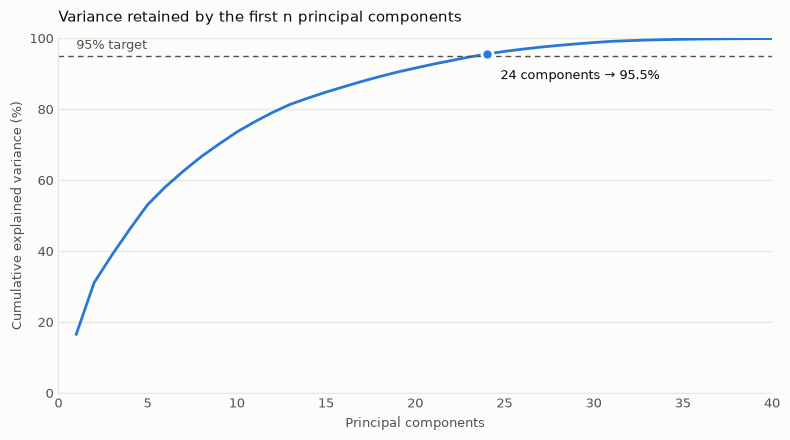

In [118]:
variance_curve = get_variance_curve(PATH_IPCA)
plot_variance_curve(variance_curve)

In [119]:
IPCA_COMPONENTS = choose_component_count(variance_curve)
print(
    f"{IPCA_COMPONENTS} of {len(variance_curve)} components keep "
    f"{variance_curve[IPCA_COMPONENTS]:.2%} of the training variance."
)

24 of 40 components keep 95.53% of the training variance.


## 9.6. Projecting One File

In [121]:
def project_features(
    df: pd.DataFrame, projection: dict[str, np.ndarray], n_components: int
) -> pd.DataFrame:
    if list(df.columns) != list(projection["columns"]):
        raise ValueError(
            "this file's columns are not, in order, the columns the projection was fitted on"
        )

    axes = projection["components"][:n_components]
    projected = (df.to_numpy() - projection["mean"]) @ axes.T

    column_names = [f"pc{number}" for number in range(1, n_components + 1)]
    return pd.DataFrame(projected, columns=column_names).astype(FEATURE_DTYPE)

In [122]:
def project_file(
    source_folder_name: str,
    target_folder_name: str,
    file_name: str,
    projection: dict[str, np.ndarray],
    n_components: int,
) -> str:
    df = read_parquet_file(source_folder_name, file_name)
    projected_features = project_features(df, projection, n_components)
    return write_dataframe_to_parquet(projected_features, target_folder_name, file_name)

## 9.7. Projecting Every Split

In [123]:
def project_all_splits(
    source_folder_name: str,
    target_folder_name: str,
    n_components: int,
    projection_file: str = PATH_IPCA,
    split_names: tuple[str, ...] = SPLIT_NAMES,
) -> None:
    projection = load_ipca(projection_file)
    process_all_splits(
        source_folder_name, target_folder_name, split_names, project_file, projection, n_components
    )

## 9.8. Run the Projection

In [124]:
project_all_splits(PATH_FOLDER_SCALED, PATH_FOLDER_IPCA, IPCA_COMPONENTS)

train: 168 files written to data-ipca/train/.
dev: 168 files written to data-ipca/dev/.
test: 168 files written to data-ipca/test/.


## 9.9. Check the Result

In [125]:
def summarize_projection(
    folder_name: str,
    projection_file: str = PATH_IPCA,
    split_names: tuple[str, ...] = SPLIT_NAMES,
) -> pd.DataFrame:
    fitted_variance = load_ipca(projection_file)["explained_variance"]

    summary = {}
    for split_name in split_names:
        measured = measure_feature_statistics(folder_name, split_name)
        summary[split_name] = {
            "components": len(measured),
            "variance carried": (measured["std"] ** 2).sum(),
            "variance predicted": fitted_variance[: len(measured)].sum(),
            "largest |mean|": measured["mean"].abs().max(),
        }

    return pd.DataFrame(summary).T

In [126]:
summarize_projection(PATH_FOLDER_IPCA)

,components,variance carried,variance predicted,largest |mean|
train,25.0,67.414255,67.412171,2.801714e-09
dev,25.0,87.480110,67.412171,1.797027e-03
test,25.0,60.815582,67.412171,2.720755e-03


# 10. Synthetic Minority Oversampling Technique

## 10.1. Settings

In [ ]:
PATH_FOLDER_SMOTE = "data-smote"

In [ ]:
SMOTE_K_NEIGHBORS = 5

## 10.2. Resampling the Rows of One File

In [ ]:
def choose_k_neighbors(labels: pd.Series, k_neighbors: int = SMOTE_K_NEIGHBORS) -> int:
    smallest_class_count = int(labels.value_counts().min())
    return max(1, min(k_neighbors, smallest_class_count - 1))

In [ ]:
def resample_rows(
    features: pd.DataFrame,
    labels: pd.Series,
    k_neighbors: int = SMOTE_K_NEIGHBORS,
    random_state: int = RANDOM_STATE,
) -> tuple[pd.DataFrame, pd.Series]:
    if labels.nunique() < 2:
        return features, labels

    smote = SMOTE(
        k_neighbors=choose_k_neighbors(labels, k_neighbors), random_state=random_state
    )
    result = smote.fit_resample(features, labels)
    resampled_features = cast(pd.DataFrame, result[0])
    resampled_labels = cast(pd.Series, result[1])
    return (
        cast(pd.DataFrame, resampled_features).astype(FEATURE_DTYPE),
        cast(pd.Series, resampled_labels),
    )

## 10.3. Resampling One File

In [ ]:
def resample_file(
    features_folder_name: str,
    labels_folder_name: str,
    target_folder_name: str,
    file_name: str,
    k_neighbors: int = SMOTE_K_NEIGHBORS,
    random_state: int = RANDOM_STATE,
) -> str:
    features = read_parquet_file(features_folder_name, file_name)
    labels = read_parquet_file(labels_folder_name, file_name)[LABEL_COLUMN]

    resampled_features, resampled_labels = resample_rows(
        features, labels, k_neighbors, random_state
    )
    resampled = resampled_features.assign(**{LABEL_COLUMN: resampled_labels.to_numpy()})

    return write_dataframe_to_parquet(resampled, target_folder_name, file_name)

## 10.4. Resampling the Training Split

In [ ]:
def resample_training_split(
    features_folder_name: str,
    labels_folder_name: str,
    target_folder_name: str,
    split_name: str = FIT_SPLIT,
    k_neighbors: int = SMOTE_K_NEIGHBORS,
    random_state: int = RANDOM_STATE,
) -> None:
    features_folder = get_split_folder(features_folder_name, split_name)
    labels_folder = get_split_folder(labels_folder_name, split_name)
    target_folder = get_split_folder(target_folder_name, split_name)
    create_split_folders(target_folder_name, (split_name,))

    file_names = get_all_file_names_in_folder(features_folder, "parquet")
    written_files = run_tasks_in_parallel(
        delayed(resample_file)(
            features_folder,
            labels_folder,
            target_folder,
            file_name,
            k_neighbors,
            random_state,
        )
        for file_name in file_names
    )

    print(f"Resampled {len(written_files)} {split_name} files into {target_folder}/.")

## 10.5. Run the Resampling

In [ ]:
resample_training_split(PATH_FOLDER_IPCA, PATH_FOLDER_ENCODED_LABEL, PATH_FOLDER_SMOTE)

## 10.6. Check the Result

In [ ]:
def compare_class_counts(
    labels_folder_name: str,
    resampled_folder_name: str,
    encoder_file: str = PATH_LABEL_ENCODER,
    split_name: str = FIT_SPLIT,
    label_column: str = LABEL_COLUMN,
) -> pd.DataFrame:
    before = count_labels_in_folder(
        get_split_folder(labels_folder_name, split_name), label_column
    )
    after = count_labels_in_folder(
        get_split_folder(resampled_folder_name, split_name), label_column
    )

    class_names = load_label_classes(encoder_file)
    table = pd.DataFrame({"before": before, "after": after}).fillna(0).astype(int).sort_index()
    table.insert(0, "class", [class_names[class_id] for class_id in table.index])
    table["synthetic"] = table["after"] - table["before"]
    table["share after %"] = (table["after"] / table["after"].sum() * 100).round(1)

    print(
        f"{table['before'].sum():,} rows in, {table['after'].sum():,} rows out, "
        f"{table['synthetic'].sum():,} of them synthetic."
    )
    return table

In [ ]:
def plot_class_counts(comparison: pd.DataFrame) -> None:
    surface, grid, ink, muted = "#fcfcfb", "#e8e7e3", "#0b0b0b", "#52514e"
    before_colour, after_colour = "#2a78d6", "#eb6834"

    ordered = comparison.sort_values("before")
    positions = np.arange(len(ordered))

    figure, axes = plt.subplots(figsize=(9, 6))
    figure.patch.set_facecolor(surface)
    axes.set_facecolor(surface)

    axes.hlines(positions, ordered["before"], ordered["after"], color=grid, linewidth=2, zorder=1)
    for column, colour, label, layer in (
        ("before", before_colour, "before", 2),
        ("after", after_colour, "after", 3),
    ):
        axes.plot(
            ordered[column], positions, "o", linestyle="none", markersize=8, color=colour,
            markeredgecolor=surface, markeredgewidth=2, label=label, zorder=layer,
        )

    axes.set_xscale("log")
    axes.set_yticks(positions)
    axes.set_yticklabels(ordered["class"], fontsize=9)
    axes.set_xlabel("Training rows (log scale)", color=muted, fontsize=9)
    axes.set_title(
        "Training rows per class, before and after SMOTE", color=ink, fontsize=11, loc="left", pad=12
    )
    axes.grid(axis="x", color=grid, linewidth=1)
    axes.set_axisbelow(True)
    for side in ("top", "right", "left"):
        axes.spines[side].set_visible(False)
    axes.spines["bottom"].set_color(grid)
    axes.tick_params(colors=muted, labelsize=9, length=0)

    legend = axes.legend(loc="lower right", frameon=False, fontsize=9)
    for text in legend.get_texts():
        text.set_color(muted)

    figure.tight_layout()
    plt.show()

In [ ]:
class_counts = compare_class_counts(PATH_FOLDER_ENCODED_LABEL, PATH_FOLDER_SMOTE)
class_counts

In [ ]:
plot_class_counts(class_counts)

# 11. Load Datasets

In [68]:
def load_split_frame(folder_name: str, split_name: str) -> pl.DataFrame:
    file_paths = get_split_file_paths(folder_name, split_name)
    return pl.scan_parquet(file_paths).collect(engine="streaming")

In [69]:
def split_features_and_labels(
    frame: pl.DataFrame, label_column: str = LABEL_COLUMN
) -> tuple[pl.DataFrame, pl.Series]:
    return frame.drop(label_column), frame[label_column]

In [70]:
def load_features_and_labels(
    features_folder_name: str,
    labels_folder_name: str,
    split_name: str,
    label_column: str = LABEL_COLUMN,
) -> tuple[pl.DataFrame, pl.Series]:
    features = load_split_frame(features_folder_name, split_name)
    labels = load_split_frame(labels_folder_name, split_name)[label_column]

    if features.height != labels.len():
        raise ValueError(
            f"{split_name}: {features.height:,} feature rows against {labels.len():,} labels — "
            "the two trees are no longer row-for-row."
        )
    return features, labels

In [71]:
def describe_dataset(name: str, features: pl.DataFrame, labels: pl.Series) -> None:
    print(
        f"{name}: {features.height:,} rows x {features.width} columns "
        f"({features.dtypes[0]}, {features.estimated_size('mb'):.0f} MB) | "
        f"labels {labels.dtype} over {labels.n_unique()} classes"
    )

## 11.1. Load Train Sets

In [72]:
train_x, train_y = split_features_and_labels(load_split_frame(PATH_FOLDER_SMOTE, FIT_SPLIT))
describe_dataset("train", train_x, train_y)

train: 11,365,674 rows x 25 columns (Float32, 1084 MB) | labels Int64 over 15 classes


## 11.2. Load Validation Sets

In [85]:
dev_x, dev_y = load_features_and_labels(PATH_FOLDER_IPCA, PATH_FOLDER_ENCODED_LABEL, "dev")
describe_dataset("dev", dev_x, dev_y)

dev: 3,246,589 rows x 25 columns (Float32, 310 MB) | labels Int64 over 15 classes


## 11.3. Load Test Sets

In [242]:
test_x, test_y = load_features_and_labels(PATH_FOLDER_IPCA, PATH_FOLDER_ENCODED_LABEL, "test")
describe_dataset("test", test_x, test_y)

test: 3,246,594 rows x 25 columns (Float32, 310 MB) | labels Int64 over 15 classes


# 12. Training and Evaluation Setup

**After retraining a model, delete the matching `prediction-result/<model>/` folder** — cached prediction chunks are never recomputed, so the old predictions would be reported as the new model's.

## 12.1. Settings

In [61]:
PATH_FOLDER_MODEL = "trained-model"
PATH_FOLDER_PREDICTION = "prediction-result"
PATH_FOLDER_SEARCH_RESULT = "hyperparameter-search"

In [62]:
PREDICT_CHUNK_SIZE = 10_000

In [63]:
SCORE_COLUMN = "f1_macro"
SEARCH_DEV_MIN_PER_CLASS = 200

In [64]:
CLASS_NAMES = load_label_classes(PATH_LABEL_ENCODER)
print(f"{len(CLASS_NAMES)} classes: {CLASS_NAMES[0]} ... {CLASS_NAMES[-1]}")

15 classes: Benign ... SSH-Bruteforce


# 13. K-Nearest Neighbours

## 13.1. Settings

In [65]:
KNN_SUBFOLDER = "KNN"

In [66]:
list_of_n_neighbors = [1, 3, 5, 7, 9, 11, 13]
list_of_distance_metrics = ["manhattan", "euclidean", "cosine"]
list_of_weightings = ["uniform", "distance"]

In [67]:
KNN_SEARCH_TRAIN_SAMPLES = 500_000
KNN_SEARCH_DEV_SAMPLES = 200_000
KNN_SEARCH_QUERY_CHUNK = 20_000

In [68]:
def get_knn_name(n_neighbors: int, metric: str, weighting: str) -> str:
    return f"knn-k-{n_neighbors}-m-{metric}-w-{weighting}.pkl"

## 13.2. Searching Without Refitting

In [ ]:
def knn_vote(
    neighbor_labels: np.ndarray,
    neighbor_distances: np.ndarray,
    n_classes: int,
    weighting: str,
) -> np.ndarray:
    n_query, n_neighbors = neighbor_labels.shape

    if weighting == "uniform":
        weights = np.ones((n_query, n_neighbors), dtype=np.float64)
    else:
        with np.errstate(divide="ignore"):
            weights = 1.0 / neighbor_distances.astype(np.float64)

        exact_match = ~np.isfinite(weights)
        rows_with_exact_match = exact_match.any(axis=1)
        if rows_with_exact_match.any():
            weights[rows_with_exact_match] = exact_match[rows_with_exact_match].astype(np.float64)

    row_offset = np.arange(n_query, dtype=np.int64)[:, None] * n_classes
    flat_index = (row_offset + neighbor_labels).ravel()
    scores = np.bincount(flat_index, weights=weights.ravel(), minlength=n_query * n_classes)

    return scores.reshape(n_query, n_classes).argmax(axis=1).astype(np.int32)

In [ ]:
def kneighbors_in_chunks(
    index, query: np.ndarray, n_neighbors: int, chunk_size: int
) -> tuple[np.ndarray, np.ndarray]:
    total = query.shape[0]
    n_chunks = math.ceil(total / chunk_size)
    distances, indices = [], []
    started = time.time()

    for number, start in enumerate(range(0, total, chunk_size), start=1):
        chunk_distances, chunk_indices = index.kneighbors(
            query[start : start + chunk_size], n_neighbors=n_neighbors
        )
        distances.append(to_numpy_2d(chunk_distances).astype(np.float32, copy=False))
        indices.append(to_numpy_2d(chunk_indices).astype(np.int64, copy=False))

        elapsed = time.time() - started
        progress_bar(
            number, n_chunks, f"neighbours (elapsed {elapsed:,.0f}s, eta {elapsed / number * (n_chunks - number):,.0f}s)"
        )

    return np.vstack(distances), np.vstack(indices)

In [ ]:
def search_knn(
    train_x,
    train_y,
    dev_x,
    dev_y,
    list_n_neighbors: list[int] = list_of_n_neighbors,
    list_metrics: list[str] = list_of_distance_metrics,
    list_weightings: list[str] = list_of_weightings,
    train_samples: int | None = KNN_SEARCH_TRAIN_SAMPLES,
    dev_samples: int | None = KNN_SEARCH_DEV_SAMPLES,
    dev_min_per_class: int = SEARCH_DEV_MIN_PER_CLASS,
    chunk_size: int = KNN_SEARCH_QUERY_CHUNK,
    random_state: int = RANDOM_STATE,
    score_column: str = SCORE_COLUMN,
) -> pd.DataFrame:
    print("Preparing search subsamples...")
    search_train_x, search_train_y = stratified_subsample(
        train_x, train_y, train_samples, random_state
    )
    search_dev_x, search_dev_y = stratified_subsample(
        dev_x, dev_y, dev_samples, random_state, min_per_class=dev_min_per_class
    )

    n_classes = int(max(search_train_y.max(), search_dev_y.max())) + 1
    max_neighbors = max(list_n_neighbors)
    rows = []

    for metric in list_metrics:
        print(f"Fitting neighbour index (metric={metric})...")
        index = NearestNeighbors(n_neighbors=max_neighbors, metric=metric)
        index.fit(search_train_x)

        neighbor_distances, neighbor_indices = kneighbors_in_chunks(
            index, search_dev_x, max_neighbors, chunk_size
        )
        neighbor_labels = search_train_y[neighbor_indices]

        for n_neighbors in list_n_neighbors:
            for weighting in list_weightings:
                pred = knn_vote(
                    neighbor_labels[:, :n_neighbors],
                    neighbor_distances[:, :n_neighbors],
                    n_classes,
                    weighting,
                )
                scores = evaluate(pred=pred, true=search_dev_y).iloc[0].to_dict()
                rows.append(
                    {"n_neighbors": n_neighbors, "metric": metric, "weights": weighting, **scores}
                )
                print(
                    f"  k={n_neighbors:>3} metric={metric:<10} weights={weighting:<8}"
                    f" {score_column}={scores[score_column]:.4f}"
                )

        del index, neighbor_distances, neighbor_indices, neighbor_labels
        free_gpu_memory()

    return pd.DataFrame(rows).sort_values(score_column, ascending=False, ignore_index=True)

## 13.3. Run the Search

In [ ]:
knn_search_results = search_knn(train_x, train_y, dev_x, dev_y)
save_search_results(knn_search_results, "knn-search.csv", PATH_FOLDER_SEARCH_RESULT)
knn_search_results

In [ ]:
best_knn = get_best_hyperparameter(knn_search_results, SCORE_COLUMN)
KNN_N_NEIGHBORS = int(best_knn["n_neighbors"])
KNN_METRIC = str(best_knn["metric"])
KNN_WEIGHTING = str(best_knn["weights"])

## 13.4. Train

In [ ]:
def train_knn(
    train_x,
    train_y,
    n_neighbors: int,
    metric: str,
    weighting: str,
    subfolder: str = KNN_SUBFOLDER,
    folder_name: str = PATH_FOLDER_MODEL,
) -> str:
    print(f"Training KNN: k={n_neighbors} metric={metric} weights={weighting}")

    model = KNeighborsClassifier(n_neighbors=n_neighbors, metric=metric, weights=weighting)
    with step(f"indexing {len(train_y):,} rows"):
        model.fit(to_features(train_x), to_labels(train_y))

    with step("saving model"):
        file_path = dump_trained_model(
            model, get_knn_name(n_neighbors, metric, weighting), subfolder, folder_name
        )

    print(f"Saved model to {file_path}.")
    return file_path

In [ ]:
train_knn(train_x, train_y, KNN_N_NEIGHBORS, KNN_METRIC, KNN_WEIGHTING)

## 13.5. Predict

In [69]:
def knn_predict(
    model_name: str,
    x,
    split_name: str,
    subfolder: str = KNN_SUBFOLDER,
    chunk_size: int = PREDICT_CHUNK_SIZE,
) -> np.ndarray:
    with step(f"loading {model_name}"):
        model = load_trained_model(model_name, subfolder, PATH_FOLDER_MODEL)

    predictions = predict_in_chunks(
        lambda rows: to_numpy(model.predict(to_features(rows))),
        x,
        get_split_folder(os.path.join(PATH_FOLDER_PREDICTION, subfolder), split_name),
        "knn",
        chunk_size,
    )

    del model
    free_gpu_memory()
    return predictions

In [70]:
knn_model_name = get_knn_name(KNN_N_NEIGHBORS, KNN_METRIC, KNN_WEIGHTING)
knn_predict(knn_model_name, dev_x, "dev")

NameError: name 'KNN_N_NEIGHBORS' is not defined

In [ ]:
knn_predict(knn_model_name, test_x, "test")

NameError: name 'test_x' is not defined

## 13.6. Report

In [ ]:
knn_dev_folder = get_split_folder(os.path.join(PATH_FOLDER_PREDICTION, KNN_SUBFOLDER), "dev")
knn_test_folder = get_split_folder(os.path.join(PATH_FOLDER_PREDICTION, KNN_SUBFOLDER), "test")

pd.concat(
    [
        get_evaluation_results(knn_dev_folder, dev_y).assign(split="dev"),
        get_evaluation_results(knn_test_folder, test_y).assign(split="test"),
    ],
    ignore_index=True,
)

In [ ]:
knn_test_pred = load_prediction_chunks(knn_test_folder)
get_classification_report(pred=knn_test_pred, true=to_labels(test_y), class_names=CLASS_NAMES)

In [ ]:
get_confusion_matrix(pred=knn_test_pred, true=to_labels(test_y), class_names=CLASS_NAMES)

# 14. Support Vector Machine

## 14.1. Settings

In [71]:
SVM_SUBFOLDER = "SVM"

In [72]:
list_of_kernels = ["rbf", "linear"]
list_of_c = [0.1, 1.0, 10.0]
list_of_gamma = ["scale", 0.1]

In [73]:
SVM_SEARCH_TRAIN_SAMPLES = 50_000
SVM_SEARCH_DEV_SAMPLES = 100_000
SVM_TRAIN_SAMPLES = 300_000

In [74]:
SVM_CACHE_SIZE = 2048
SVM_TOLERANCE = 1e-3
SVM_MAX_ITER = -1

In [75]:
def get_svm_name(kernel: str, c: float, gamma) -> str:
    return f"svm-k-{kernel}-c-{c}-g-{gamma}.pkl"

## 14.2. Building and Scoring One SVM

**A `NaN` row in a search table is a combination that was never scored, not one that scored badly.**

In [ ]:
def build_svm_grid(kernels: list[str], list_c: list[float], list_gamma: list) -> list[tuple]:
    combinations = []
    for kernel, c in itertools.product(kernels, list_c):
        if kernel == "linear":
            combinations.append((kernel, c, "scale"))
            continue
        combinations.extend((kernel, c, gamma) for gamma in list_gamma)
    return combinations

In [ ]:
def build_svm(
    kernel: str,
    c: float,
    gamma,
    cache_size: int = SVM_CACHE_SIZE,
    tolerance: float = SVM_TOLERANCE,
    max_iter: int = SVM_MAX_ITER,
) -> SVC:
    return SVC(
        C=float(c),
        kernel=kernel,
        gamma=gamma,
        cache_size=cache_size,
        tol=tolerance,
        max_iter=max_iter,
    )

In [ ]:
def support_vector_count(model) -> float:
    try:
        n_support = getattr(model, "n_support_", None)
        if n_support is not None:
            return float(np.sum(to_numpy_2d(n_support)))

        support = getattr(model, "support_", None)
        if support is not None:
            return float(np.size(to_numpy_2d(support)))
    except Exception:
        pass
    return float("nan")

In [ ]:
def fit_and_score_svm(kernel, c, gamma, train_x, train_y, dev_x, dev_y) -> dict:
    model = build_svm(kernel, c, gamma)

    fit_started = time.time()
    with step(f"fitting on {train_x.shape[0]:,} rows"):
        model.fit(train_x, train_y)
    fit_seconds = time.time() - fit_started

    with step(f"predicting {dev_x.shape[0]:,} dev rows"):
        pred = to_numpy(model.predict(dev_x))

    scores = evaluate(pred=pred, true=dev_y).iloc[0].to_dict()
    measurements = {"fit_seconds": fit_seconds, "n_support": support_vector_count(model), **scores}

    del model
    free_gpu_memory()
    return measurements

## 14.3. Run the Search

In [ ]:
def search_svm(
    train_x,
    train_y,
    dev_x,
    dev_y,
    combinations: list[tuple] | None = None,
    train_samples: int | None = SVM_SEARCH_TRAIN_SAMPLES,
    dev_samples: int | None = SVM_SEARCH_DEV_SAMPLES,
    dev_min_per_class: int = SEARCH_DEV_MIN_PER_CLASS,
    random_state: int = RANDOM_STATE,
    score_column: str = SCORE_COLUMN,
) -> pd.DataFrame:
    if combinations is None:
        combinations = build_svm_grid(list_of_kernels, list_of_c, list_of_gamma)

    print(f"SVM search over {len(combinations)} combinations")
    free_gpu_memory()

    print("Preparing search subsamples...")
    search_data = (
        *stratified_subsample(train_x, train_y, train_samples, random_state),
        *stratified_subsample(dev_x, dev_y, dev_samples, random_state, min_per_class=dev_min_per_class),
    )

    return run_search(
        combinations, ("kernel", "C", "gamma"), fit_and_score_svm, search_data, score_column
    )

In [ ]:
svm_search_results = search_svm(train_x, train_y, dev_x, dev_y)
save_search_results(svm_search_results, "svm-search.csv", PATH_FOLDER_SEARCH_RESULT)
svm_search_results

In [ ]:
best_svm = get_best_hyperparameter(svm_search_results, SCORE_COLUMN)
SVM_KERNEL = str(best_svm["kernel"])
SVM_C = float(best_svm["C"])
SVM_GAMMA = best_svm["gamma"]

## 14.4. Train

In [ ]:
def train_svm(
    train_x,
    train_y,
    kernel: str,
    c: float,
    gamma,
    train_samples: int | None = SVM_TRAIN_SAMPLES,
    random_state: int = RANDOM_STATE,
    subfolder: str = SVM_SUBFOLDER,
    folder_name: str = PATH_FOLDER_MODEL,
) -> str:
    print(f"Training SVM: kernel={kernel} C={c} gamma={gamma}")

    print("Preparing training subsample...")
    features, labels = stratified_subsample(train_x, train_y, train_samples, random_state)
    n_rows, n_features = features.shape

    model = build_svm(kernel, c, gamma)
    with step(f"fitting on {n_rows:,} rows x {n_features} features"):
        model.fit(features, labels)
    print(f"  {support_vector_count(model):,.0f} support vectors")

    with step("saving model"):
        file_path = dump_trained_model(
            model, get_svm_name(kernel, c, gamma), subfolder, folder_name
        )

    print(f"Saved model to {file_path}.")
    return file_path

In [ ]:
train_svm(train_x, train_y, SVM_KERNEL, SVM_C, SVM_GAMMA)

## 14.5. Predict

In [76]:
def svm_predict(
    model_name: str,
    x,
    split_name: str,
    subfolder: str = SVM_SUBFOLDER,
    chunk_size: int = PREDICT_CHUNK_SIZE,
) -> np.ndarray:
    with step(f"loading {model_name}"):
        model = load_trained_model(model_name, subfolder, PATH_FOLDER_MODEL)
    print(f"  {support_vector_count(model):,.0f} support vectors")

    predictions = predict_in_chunks(
        lambda rows: to_numpy(model.predict(to_features(rows))),
        x,
        get_split_folder(os.path.join(PATH_FOLDER_PREDICTION, subfolder), split_name),
        "svm",
        chunk_size,
    )

    del model
    free_gpu_memory()
    return predictions

In [ ]:
svm_model_name = get_svm_name(SVM_KERNEL, SVM_C, SVM_GAMMA)
svm_predict(svm_model_name, dev_x, "dev")

In [ ]:
svm_predict(svm_model_name, test_x, "test")

## 14.6. Report

In [ ]:
svm_dev_folder = get_split_folder(os.path.join(PATH_FOLDER_PREDICTION, SVM_SUBFOLDER), "dev")
svm_test_folder = get_split_folder(os.path.join(PATH_FOLDER_PREDICTION, SVM_SUBFOLDER), "test")

pd.concat(
    [
        get_evaluation_results(svm_dev_folder, dev_y).assign(split="dev"),
        get_evaluation_results(svm_test_folder, test_y).assign(split="test"),
    ],
    ignore_index=True,
)

In [ ]:
svm_test_pred = load_prediction_chunks(svm_test_folder)
get_classification_report(pred=svm_test_pred, true=to_labels(test_y), class_names=CLASS_NAMES)

In [ ]:
get_confusion_matrix(pred=svm_test_pred, true=to_labels(test_y), class_names=CLASS_NAMES)

# 15. Random Forest

## 15.1. Settings

In [77]:
RF_SUBFOLDER = "RF"

In [78]:
list_of_n_estimators = [100, 300]
list_of_max_depth = [12, 16, 24]
list_of_max_features = ["sqrt", "log2"]

In [79]:
RF_SEARCH_TRAIN_SAMPLES = 1_000_000
RF_SEARCH_DEV_SAMPLES = 200_000
RF_TRAIN_SAMPLES = None

In [80]:
RF_SPLIT_CRITERION = "gini"
RF_N_BINS = 128
RF_N_STREAMS = 4

In [81]:
def get_rf_name(n_estimators: int, max_depth: int, max_features) -> str:
    return f"rf-n-{n_estimators}-d-{max_depth}-f-{max_features}.pkl"

## 15.2. Building and Scoring One Forest

In [64]:
def build_rf(
    n_estimators: int,
    max_depth: int,
    max_features,
    split_criterion: str = RF_SPLIT_CRITERION,
    n_bins: int = RF_N_BINS,
    n_streams: int = RF_N_STREAMS,
    random_state: int = RANDOM_STATE,
) -> RandomForestClassifier:
    if use_cuda:
        return RandomForestClassifier(
            n_estimators=int(n_estimators),
            max_depth=int(max_depth),
            max_features=max_features,
            split_criterion=split_criterion,
            n_bins=n_bins,
            n_streams=n_streams,
            random_state=random_state,
        )

    return RandomForestClassifier(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        max_features=max_features,
        criterion=split_criterion,
        random_state=random_state,
        n_jobs=-1,
    )

In [65]:
def fit_and_score_rf(
    n_estimators, max_depth, max_features, train_x, train_y, dev_x, dev_y
) -> dict:
    model = build_rf(n_estimators, max_depth, max_features)

    fit_started = time.time()
    with step(f"fitting {n_estimators} trees on {train_x.shape[0]:,} rows"):
        model.fit(train_x, train_y)
    fit_seconds = time.time() - fit_started

    predict_started = time.time()
    with step(f"predicting {dev_x.shape[0]:,} dev rows"):
        pred = to_numpy(model.predict(dev_x)).astype(np.int32)
    predict_seconds = time.time() - predict_started

    scores = evaluate(pred=pred, true=dev_y).iloc[0].to_dict()
    measurements = {
        "fit_seconds": fit_seconds,
        "predict_seconds": predict_seconds,
        **scores,
    }

    del model
    free_gpu_memory()
    return measurements

## 15.3. Run the Search

In [66]:
def search_rf(
    train_x,
    train_y,
    dev_x,
    dev_y,
    combinations: list[tuple] | None = None,
    train_samples: int | None = RF_SEARCH_TRAIN_SAMPLES,
    dev_samples: int | None = RF_SEARCH_DEV_SAMPLES,
    dev_min_per_class: int = SEARCH_DEV_MIN_PER_CLASS,
    random_state: int = RANDOM_STATE,
    score_column: str = SCORE_COLUMN,
) -> pd.DataFrame:
    if combinations is None:
        combinations = build_grid(list_of_n_estimators, list_of_max_depth, list_of_max_features)

    print(f"Random Forest search over {len(combinations)} combinations")
    free_gpu_memory()

    print("Preparing search subsamples...")
    search_data = (
        *stratified_subsample(train_x, train_y, train_samples, random_state),
        *stratified_subsample(dev_x, dev_y, dev_samples, random_state, min_per_class=dev_min_per_class),
    )

    return run_search(
        combinations,
        ("n_estimators", "max_depth", "max_features"),
        fit_and_score_rf,
        search_data,
        score_column,
    )

In [67]:
rf_search_results = search_rf(train_x, train_y, dev_x, dev_y)
save_search_results(rf_search_results, "rf-search.csv", PATH_FOLDER_SEARCH_RESULT)
rf_search_results

NameError: name 'train_x' is not defined

In [ ]:
best_rf = get_best_hyperparameter(rf_search_results, SCORE_COLUMN)
RF_N_ESTIMATORS = int(best_rf["n_estimators"])
RF_MAX_DEPTH = int(best_rf["max_depth"])
RF_MAX_FEATURES = best_rf["max_features"]

Best by f1_macro:
        n_estimators = 300
           max_depth = 24
        max_features = log2
         fit_seconds = 20.882568359375
     predict_seconds = 5.343972444534302
            accuracy = 0.8354863657909837
     precision_macro = 0.4307407779451979
        recall_macro = 0.1703108974897621
            f1_macro = 0.18349427166275573


## 15.4. Train

In [73]:
RF_N_ESTIMATORS = 300
RF_MAX_DEPTH = 24
RF_MAX_FEATURES = "log2"

In [74]:
def train_rf(
    train_x,
    train_y,
    n_estimators: int,
    max_depth: int,
    max_features,
    train_samples: int | None = RF_TRAIN_SAMPLES,
    random_state: int = RANDOM_STATE,
    subfolder: str = RF_SUBFOLDER,
    folder_name: str = PATH_FOLDER_MODEL,
) -> str:
    print(
        f"Training Random Forest: n_estimators={n_estimators} "
        f"max_depth={max_depth} max_features={max_features}"
    )

    print("Preparing training data...")
    features, labels = stratified_subsample(train_x, train_y, train_samples, random_state)
    n_rows, n_features = features.shape

    model = build_rf(n_estimators, max_depth, max_features, random_state=random_state)
    with step(f"fitting {n_estimators} trees on {n_rows:,} rows x {n_features} features"):
        model.fit(features, labels)

    with step("saving model"):
        file_path = dump_trained_model(
            model, get_rf_name(n_estimators, max_depth, max_features), subfolder, folder_name
        )

    print(f"Saved model to {file_path}.")
    return file_path

In [75]:
train_rf(train_x, train_y, RF_N_ESTIMATORS, RF_MAX_DEPTH, RF_MAX_FEATURES)

Training Random Forest: n_estimators=300 max_depth=24 max_features=log2
Preparing training data...
  fitting 300 trees on 11,365,674 rows x 25 features ... done
  saving model ... done
Saved model to trained-model/RF/rf-n-300-d-24-f-log2.pkl.


'trained-model/RF/rf-n-300-d-24-f-log2.pkl'

## 15.5. Predict

In [82]:
def rf_predict(
    model_name: str,
    x,
    split_name: str,
    subfolder: str = RF_SUBFOLDER,
    chunk_size: int = PREDICT_CHUNK_SIZE,
) -> np.ndarray:
    with step(f"loading {model_name}"):
        model = load_trained_model(model_name, subfolder, PATH_FOLDER_MODEL)

    predictions = predict_in_chunks(
        lambda rows: to_numpy(model.predict(to_features(rows))),
        x,
        get_split_folder(os.path.join(PATH_FOLDER_PREDICTION, subfolder), split_name),
        "rf",
        chunk_size,
    )

    del model
    free_gpu_memory()
    return predictions

In [ ]:
rf_model_name = get_rf_name(RF_N_ESTIMATORS, RF_MAX_DEPTH, RF_MAX_FEATURES)
rf_predict(rf_model_name, dev_x, "dev")

In [ ]:
rf_predict(rf_model_name, test_x, "test")

## 15.6. Report

In [ ]:
rf_dev_folder = get_split_folder(os.path.join(PATH_FOLDER_PREDICTION, RF_SUBFOLDER), "dev")
rf_test_folder = get_split_folder(os.path.join(PATH_FOLDER_PREDICTION, RF_SUBFOLDER), "test")

pd.concat(
    [
        get_evaluation_results(rf_dev_folder, dev_y).assign(split="dev"),
        get_evaluation_results(rf_test_folder, test_y).assign(split="test"),
    ],
    ignore_index=True,
)

In [ ]:
rf_test_pred = load_prediction_chunks(rf_test_folder)
get_classification_report(pred=rf_test_pred, true=to_labels(test_y), class_names=CLASS_NAMES)

In [ ]:
get_confusion_matrix(pred=rf_test_pred, true=to_labels(test_y), class_names=CLASS_NAMES)

# 16. Logistic Regression (Softmax)

## 16.1. Settings

In [83]:
LOGREG_SUBFOLDER = "LOGREG"

In [84]:
list_of_learning_rates = [1e-2, 1e-3]
list_of_batch_sizes = [2048, 8192]
list_of_l2 = [0.0, 1e-5, 1e-4]

In [85]:
LOGREG_SEARCH_TRAIN_SAMPLES = 1_000_000
LOGREG_SEARCH_DEV_SAMPLES = 200_000
LOGREG_TRAIN_SAMPLES = None

In [86]:
LOGREG_N_CLASSES = len(CLASS_NAMES)
LOGREG_MAX_EPOCHS = 30
LOGREG_PATIENCE = 3
LOGREG_PREDICT_BATCH = 8192

In [87]:
def get_logreg_name(learning_rate: float, batch_size: int, l2: float) -> str:
    return f"logreg-lr-{learning_rate}-bs-{batch_size}-l2-{l2}.keras"

## 16.2. Building and Scoring One Model

In [91]:
def build_logreg(
    n_features: int,
    learning_rate: float,
    l2: float,
    n_classes: int = LOGREG_N_CLASSES,
    random_state: int = RANDOM_STATE,
) -> keras.Model:
    keras.utils.set_random_seed(random_state)

    model = keras.Sequential(
        [
            keras.Input(shape=(n_features,)),
            keras.layers.Dense(
                n_classes,
                activation="softmax",
                kernel_regularizer=keras.regularizers.L2(l2) if l2 else None,
                name="softmax",
            ),
        ],
        name="logistic_regression",
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=float(learning_rate)),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [92]:
def fit_and_score_logreg(
    learning_rate,
    batch_size,
    l2,
    train_x,
    train_y,
    dev_x,
    dev_y,
    max_epochs: int = LOGREG_MAX_EPOCHS,
    patience: int = LOGREG_PATIENCE,
) -> dict:
    model = build_logreg(train_x.shape[1], learning_rate, l2)

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=patience, restore_best_weights=True
    )

    fit_started = time.time()
    with step(f"fitting {train_x.shape[0]:,} rows for up to {max_epochs} epochs"):
        history = model.fit(
            train_x,
            train_y,
            validation_data=(dev_x, dev_y),
            epochs=max_epochs,
            batch_size=int(batch_size),
            callbacks=[early_stopping],
            shuffle=True,
            verbose=0,
        )
    fit_seconds = time.time() - fit_started

    predict_started = time.time()
    with step(f"predicting {dev_x.shape[0]:,} dev rows"):
        probabilities = model.predict(dev_x, batch_size=LOGREG_PREDICT_BATCH, verbose=0)
        pred = probabilities.argmax(axis=1).astype(np.int32)
    predict_seconds = time.time() - predict_started

    scores = evaluate(pred=pred, true=dev_y).iloc[0].to_dict()
    measurements = {
        "epochs_run": len(history.history["loss"]),
        "fit_seconds": fit_seconds,
        "predict_seconds": predict_seconds,
        **scores,
    }

    del model
    keras.backend.clear_session()
    free_gpu_memory()
    return measurements

## 16.3. Run the Search

In [93]:
def search_logreg(
    train_x,
    train_y,
    dev_x,
    dev_y,
    combinations: list[tuple] | None = None,
    train_samples: int | None = LOGREG_SEARCH_TRAIN_SAMPLES,
    dev_samples: int | None = LOGREG_SEARCH_DEV_SAMPLES,
    dev_min_per_class: int = SEARCH_DEV_MIN_PER_CLASS,
    random_state: int = RANDOM_STATE,
    score_column: str = SCORE_COLUMN,
) -> pd.DataFrame:
    if combinations is None:
        combinations = build_grid(list_of_learning_rates, list_of_batch_sizes, list_of_l2)

    print(f"Logistic Regression search over {len(combinations)} combinations")
    free_gpu_memory()

    print("Preparing search subsamples...")
    search_data = (
        *stratified_subsample(train_x, train_y, train_samples, random_state),
        *stratified_subsample(dev_x, dev_y, dev_samples, random_state, min_per_class=dev_min_per_class),
    )

    return run_search(
        combinations,
        ("learning_rate", "batch_size", "l2"),
        fit_and_score_logreg,
        search_data,
        score_column,
    )

In [94]:
logreg_search_results = search_logreg(train_x, train_y, dev_x, dev_y)
save_search_results(logreg_search_results, "logreg-search.csv", PATH_FOLDER_SEARCH_RESULT)
logreg_search_results

Logistic Regression search over 12 combinations
Preparing search subsamples...
  subsampled 11,365,674 -> 999,993 rows across 15 classes
  subsampled 3,246,589 -> 200,415 rows across 15 classes
[1/12] learning_rate=0.01 batch_size=2048 l2=0.0
  fitting 999,993 rows for up to 30 epochs ... done
  predicting 200,415 dev rows ... done
  f1_macro=0.2284
[2/12] learning_rate=0.01 batch_size=2048 l2=1e-05
  fitting 999,993 rows for up to 30 epochs ... done
  predicting 200,415 dev rows ... done
  f1_macro=0.2287
[3/12] learning_rate=0.01 batch_size=2048 l2=0.0001
  fitting 999,993 rows for up to 30 epochs ... done
  predicting 200,415 dev rows ... done
  f1_macro=0.4304
[4/12] learning_rate=0.01 batch_size=8192 l2=0.0
  fitting 999,993 rows for up to 30 epochs ... done
  predicting 200,415 dev rows ... done
  f1_macro=0.1962
[5/12] learning_rate=0.01 batch_size=8192 l2=1e-05
  fitting 999,993 rows for up to 30 epochs ... done
  predicting 200,415 dev rows ... done
  f1_macro=0.1986
[6/12] le

,learning_rate,batch_size,l2,epochs_run,fit_seconds,predict_seconds,accuracy,precision_macro,recall_macro,f1_macro
0,0.010,2048,0.00010,22,12.928047,0.092494,0.890482,0.511715,0.423948,0.430428
1,0.010,8192,0.00010,30,8.230133,0.081620,0.887074,0.408962,0.360261,0.339772
2,0.001,2048,0.00010,30,19.620095,0.082278,0.879261,0.399050,0.345872,0.328292
3,0.001,2048,0.00001,16,9.114186,0.087943,0.823900,0.301453,0.235696,0.236447
4,0.010,2048,0.00001,5,3.338002,0.084106,0.818427,0.277125,0.216464,0.228748
5,0.010,2048,0.00000,5,4.190002,0.091101,0.818921,0.279215,0.216538,0.228374
6,0.001,8192,0.00010,30,11.281417,0.088250,0.834473,0.231777,0.211944,0.200887
7,0.010,8192,0.00001,9,5.642282,0.082965,0.816995,0.259567,0.204248,0.198601
8,0.001,2048,0.00000,15,8.542757,0.081789,0.815987,0.254846,0.204384,0.198230
9,0.010,8192,0.00000,8,2.436570,0.086957,0.817758,0.252152,0.202905,0.196204


In [95]:
best_logreg = get_best_hyperparameter(logreg_search_results, SCORE_COLUMN)
LOGREG_LEARNING_RATE = float(best_logreg["learning_rate"])
LOGREG_BATCH_SIZE = int(best_logreg["batch_size"])
LOGREG_L2 = float(best_logreg["l2"])
LOGREG_EPOCHS = int(best_logreg["epochs_run"])

Best by f1_macro:
       learning_rate = 0.01
          batch_size = 2048.0
                  l2 = 0.0001
          epochs_run = 22.0
         fit_seconds = 12.928047180175781
     predict_seconds = 0.09249448776245117
            accuracy = 0.8904822493326348
     precision_macro = 0.5117151426406561
        recall_macro = 0.42394787957334706
            f1_macro = 0.4304280417125835


## 16.4. Train

In [96]:
def dump_keras_model(model, name: str, subfolder: str, folder_name: str) -> str:
    target_folder = os.path.join(folder_name, subfolder)
    os.makedirs(target_folder, exist_ok=True)
    file_path = os.path.join(target_folder, name)
    temporary_path = get_temporary_model_path(file_path)
    model.save(temporary_path)
    os.replace(temporary_path, file_path)
    return file_path

In [97]:
def train_logreg(
    train_x,
    train_y,
    learning_rate: float,
    batch_size: int,
    l2: float,
    epochs: int,
    train_samples: int | None = LOGREG_TRAIN_SAMPLES,
    random_state: int = RANDOM_STATE,
    subfolder: str = LOGREG_SUBFOLDER,
    folder_name: str = PATH_FOLDER_MODEL,
) -> str:
    print(
        f"Training Logistic Regression: learning_rate={learning_rate} "
        f"batch_size={batch_size} l2={l2} epochs={epochs}"
    )

    print("Preparing training data...")
    features, labels = stratified_subsample(train_x, train_y, train_samples, random_state)
    n_rows, n_features = features.shape

    model = build_logreg(n_features, learning_rate, l2, random_state=random_state)
    model.summary()

    print(f"Fitting {epochs} epochs on {n_rows:,} rows x {n_features} features")
    model.fit(features, labels, epochs=int(epochs), batch_size=int(batch_size), shuffle=True, verbose=2)

    with step("saving model"):
        file_path = dump_keras_model(
            model, get_logreg_name(learning_rate, batch_size, l2), subfolder, folder_name
        )

    print(f"Saved model to {file_path}.")
    return file_path

In [98]:
train_logreg(train_x, train_y, LOGREG_LEARNING_RATE, LOGREG_BATCH_SIZE, LOGREG_L2, LOGREG_EPOCHS)

Training Logistic Regression: learning_rate=0.01 batch_size=2048 l2=0.0001 epochs=22
Preparing training data...


Model: "logistic_regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ softmax (Dense)                 │ (None, 15)             │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390 (1.52 KB)

 Trainable params: 390 (1.52 KB)

 Non-trainable params: 0 (0.00 B)

Fitting 22 epochs on 11,365,674 rows x 25 features
Epoch 1/22
5550/5550 - 5s - 967us/step - accuracy: 0.9066 - loss: 0.4103
Epoch 2/22
5550/5550 - 5s - 874us/step - accuracy: 0.9226 - loss: 0.3390
Epoch 3/22
5550/5550 - 5s - 863us/step - accuracy: 0.9227 - loss: 0.3385
Epoch 4/22
5550/5550 - 5s - 863us/step - accuracy: 0.9227 - loss: 0.3384
Epoch 5/22
5550/5550 - 8s - 1ms/step - accuracy: 0.9227 - loss: 0.3384
Epoch 6/22
5550/5550 - 5s - 862us/step - accuracy: 0.9227 - loss: 0.3383
Epoch 7/22
5550/5550 - 5s - 867us/step - accuracy: 0.9227 - loss: 0.3383
Epoch 8/22
5550/5550 - 5s - 865us/step - accuracy: 0.9227 - loss: 0.3384
Epoch 9/22
5550/5550 - 5s - 890us/step - accuracy: 0.9227 - loss: 0.3383
Epoch 10/22
5550/5550 - 5s - 869us/step - accuracy: 0.9227 - loss: 0.3383
Epoch 11/22
5550/5550 - 8s - 1ms/step - accuracy: 0.9227 - loss: 0.3383
Epoch 12/22
5550/5550 - 5s - 930us/step - accuracy: 0.9227 - loss: 0.3384
Epoch 13/22
5550/5550 - 5s - 907us/step - accuracy: 0.9227 - loss: 0.3383


'trained-model/LOGREG/logreg-lr-0.01-bs-2048-l2-0.0001.keras'

## 16.5. Predict

In [88]:
def logreg_predict(
    model_name: str,
    x,
    split_name: str,
    subfolder: str = LOGREG_SUBFOLDER,
    chunk_size: int = PREDICT_CHUNK_SIZE,
    batch_size: int = LOGREG_PREDICT_BATCH,
) -> np.ndarray:
    with step(f"loading {model_name}"):
        model = keras.models.load_model(
            os.path.join(PATH_FOLDER_MODEL, subfolder, model_name)
        )

    predictions = predict_in_chunks(
        lambda rows: model.predict(
            to_features(rows), batch_size=batch_size, verbose=0
        ).argmax(axis=1),
        x,
        get_split_folder(os.path.join(PATH_FOLDER_PREDICTION, subfolder), split_name),
        "logreg",
        chunk_size,
    )

    del model
    keras.backend.clear_session()
    free_gpu_memory()
    return predictions

In [89]:
logreg_model_name = get_logreg_name(LOGREG_LEARNING_RATE, LOGREG_BATCH_SIZE, LOGREG_L2)
logreg_predict(logreg_model_name, dev_x, "dev")

NameError: name 'LOGREG_LEARNING_RATE' is not defined

In [ ]:
logreg_predict(logreg_model_name, test_x, "test")

NameError: name 'test_x' is not defined

## 16.6. Report

In [ ]:
logreg_dev_folder = get_split_folder(os.path.join(PATH_FOLDER_PREDICTION, LOGREG_SUBFOLDER), "dev")
logreg_test_folder = get_split_folder(os.path.join(PATH_FOLDER_PREDICTION, LOGREG_SUBFOLDER), "test")

pd.concat(
    [
        get_evaluation_results(logreg_dev_folder, dev_y).assign(split="dev"),
        get_evaluation_results(logreg_test_folder, test_y).assign(split="test"),
    ],
    ignore_index=True,
)

In [ ]:
logreg_test_pred = load_prediction_chunks(logreg_test_folder)
get_classification_report(pred=logreg_test_pred, true=to_labels(test_y), class_names=CLASS_NAMES)

In [ ]:
get_confusion_matrix(pred=logreg_test_pred, true=to_labels(test_y), class_names=CLASS_NAMES)

# 17. XGBoost

## 17.1. Settings

In [90]:
XGB_SUBFOLDER = "XGB"

In [91]:
list_of_xgb_max_depth = [6, 8, 10]
list_of_xgb_learning_rates = [0.1, 0.3]
list_of_xgb_colsample_bytree = [0.6, 1.0]

In [92]:
XGB_SEARCH_TRAIN_SAMPLES = 1_000_000
XGB_SEARCH_DEV_SAMPLES = 200_000
XGB_TRAIN_SAMPLES = None

In [93]:
XGB_DEVICE = "cuda" if use_cuda else "cpu"
XGB_TREE_METHOD = "hist"
XGB_MAX_ROUNDS = 400
XGB_EARLY_STOPPING_ROUNDS = 20
XGB_MAX_BIN = 128
XGB_SUBSAMPLE = 0.8
XGB_MIN_CHILD_WEIGHT = 1.0

In [94]:
def get_xgb_name(max_depth: int, learning_rate: float, colsample_bytree: float) -> str:
    return f"xgb-d-{max_depth}-lr-{learning_rate}-c-{colsample_bytree}.json"

## 17.2. Building and Scoring One Booster

In [93]:
def build_xgb(
    max_depth: int,
    learning_rate: float,
    colsample_bytree: float,
    n_estimators: int = XGB_MAX_ROUNDS,
    early_stopping_rounds: int | None = None,
    subsample: float = XGB_SUBSAMPLE,
    min_child_weight: float = XGB_MIN_CHILD_WEIGHT,
    max_bin: int = XGB_MAX_BIN,
    tree_method: str = XGB_TREE_METHOD,
    device: str = XGB_DEVICE,
    random_state: int = RANDOM_STATE,
) -> XGBClassifier:
    return XGBClassifier(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        learning_rate=float(learning_rate),
        colsample_bytree=float(colsample_bytree),
        subsample=float(subsample),
        min_child_weight=float(min_child_weight),
        max_bin=int(max_bin),
        tree_method=tree_method,
        device=device,
        objective="multi:softprob",
        eval_metric="mlogloss",
        early_stopping_rounds=early_stopping_rounds,
        random_state=random_state,
    )

In [94]:
def to_xgb_features(x):
    features = to_features(x)
    if not use_cuda:
        return features

    import cupy as cp

    return cp.asarray(features)

In [ ]:
def fit_and_score_xgb(
    max_depth,
    learning_rate,
    colsample_bytree,
    train_x,
    train_y,
    dev_x,
    dev_y,
    max_rounds: int = XGB_MAX_ROUNDS,
    early_stopping_rounds: int = XGB_EARLY_STOPPING_ROUNDS,
) -> dict:
    model = build_xgb(
        max_depth,
        learning_rate,
        colsample_bytree,
        n_estimators=max_rounds,
        early_stopping_rounds=early_stopping_rounds,
    )

    fit_started = time.time()
    with step(f"boosting up to {max_rounds} rounds on {train_x.shape[0]:,} rows"):
        model.fit(train_x, train_y, eval_set=[(dev_x, dev_y)], verbose=False)
    fit_seconds = time.time() - fit_started

    best_iteration = getattr(model, "best_iteration", None)
    n_trees_used = max_rounds if best_iteration is None else int(best_iteration) + 1

    predict_started = time.time()
    with step(f"predicting {dev_x.shape[0]:,} dev rows"):
        pred = to_numpy(model.predict(to_xgb_features(dev_x))).astype(np.int32)
    predict_seconds = time.time() - predict_started

    scores = evaluate(pred=pred, true=dev_y).iloc[0].to_dict()
    measurements = {
        "n_trees_used": n_trees_used,
        "fit_seconds": fit_seconds,
        "predict_seconds": predict_seconds,
        **scores,
    }

    del model
    free_gpu_memory()
    return measurements

## 17.3. Run the Search

In [96]:
def search_xgb(
    train_x,
    train_y,
    dev_x,
    dev_y,
    combinations: list[tuple] | None = None,
    train_samples: int | None = XGB_SEARCH_TRAIN_SAMPLES,
    dev_samples: int | None = XGB_SEARCH_DEV_SAMPLES,
    dev_min_per_class: int = SEARCH_DEV_MIN_PER_CLASS,
    random_state: int = RANDOM_STATE,
    score_column: str = SCORE_COLUMN,
) -> pd.DataFrame:
    if combinations is None:
        combinations = build_grid(
            list_of_xgb_max_depth, list_of_xgb_learning_rates, list_of_xgb_colsample_bytree
        )

    print(f"XGBoost search over {len(combinations)} combinations")
    free_gpu_memory()

    print("Preparing search subsamples...")
    search_data = (
        *stratified_subsample(train_x, train_y, train_samples, random_state),
        *stratified_subsample(dev_x, dev_y, dev_samples, random_state, min_per_class=dev_min_per_class),
    )

    return run_search(
        combinations,
        ("max_depth", "learning_rate", "colsample_bytree"),
        fit_and_score_xgb,
        search_data,
        score_column,
    )

In [97]:
xgb_search_results = search_xgb(train_x, train_y, dev_x, dev_y)
save_search_results(xgb_search_results, "xgb-search.csv", PATH_FOLDER_SEARCH_RESULT)
xgb_search_results

NameError: name 'train_x' is not defined

In [ ]:
best_xgb = get_best_hyperparameter(xgb_search_results, SCORE_COLUMN)
XGB_MAX_DEPTH = int(best_xgb["max_depth"])
XGB_LEARNING_RATE = float(best_xgb["learning_rate"])
XGB_COLSAMPLE_BYTREE = float(best_xgb["colsample_bytree"])
XGB_N_ESTIMATORS = int(best_xgb["n_trees_used"])

## 17.4. Train

In [ ]:
def dump_xgb_model(model, name: str, subfolder: str, folder_name: str) -> str:
    target_folder = os.path.join(folder_name, subfolder)
    os.makedirs(target_folder, exist_ok=True)
    file_path = os.path.join(target_folder, name)
    temporary_path = get_temporary_model_path(file_path)
    model.save_model(temporary_path)
    os.replace(temporary_path, file_path)
    return file_path

In [ ]:
def train_xgb(
    train_x,
    train_y,
    max_depth: int,
    learning_rate: float,
    colsample_bytree: float,
    n_estimators: int,
    train_samples: int | None = XGB_TRAIN_SAMPLES,
    random_state: int = RANDOM_STATE,
    subfolder: str = XGB_SUBFOLDER,
    folder_name: str = PATH_FOLDER_MODEL,
) -> str:
    print(
        f"Training XGBoost: max_depth={max_depth} learning_rate={learning_rate} "
        f"colsample_bytree={colsample_bytree} n_estimators={n_estimators}"
    )

    print("Preparing training data...")
    features, labels = stratified_subsample(train_x, train_y, train_samples, random_state)
    n_rows, n_features = features.shape

    model = build_xgb(
        max_depth, learning_rate, colsample_bytree, n_estimators=n_estimators, random_state=random_state
    )
    with step(f"boosting {n_estimators} rounds on {n_rows:,} rows x {n_features} features ({XGB_DEVICE})"):
        model.fit(features, labels, verbose=False)

    with step("saving model"):
        file_path = dump_xgb_model(
            model, get_xgb_name(max_depth, learning_rate, colsample_bytree), subfolder, folder_name
        )

    print(f"Saved model to {file_path}.")
    return file_path

In [ ]:
train_xgb(
    train_x, train_y, XGB_MAX_DEPTH, XGB_LEARNING_RATE, XGB_COLSAMPLE_BYTREE, XGB_N_ESTIMATORS
)

## 17.5. Predict

In [95]:
def load_xgb_model(model_name: str, subfolder: str, folder_name: str) -> XGBClassifier:
    model = XGBClassifier()
    model.load_model(os.path.join(folder_name, subfolder, model_name))
    model.set_params(device=XGB_DEVICE, tree_method=XGB_TREE_METHOD)
    return model

In [96]:
def xgb_predict(
    model_name: str,
    x,
    split_name: str,
    subfolder: str = XGB_SUBFOLDER,
    chunk_size: int = PREDICT_CHUNK_SIZE,
) -> np.ndarray:
    with step(f"loading {model_name}"):
        model = load_xgb_model(model_name, subfolder, PATH_FOLDER_MODEL)

    predictions = predict_in_chunks(
        lambda rows: to_numpy(model.predict(to_xgb_features(rows))),
        x,
        get_split_folder(os.path.join(PATH_FOLDER_PREDICTION, subfolder), split_name),
        "xgb",
        chunk_size,
    )

    del model
    free_gpu_memory()
    return predictions

In [ ]:
xgb_model_name = get_xgb_name(XGB_MAX_DEPTH, XGB_LEARNING_RATE, XGB_COLSAMPLE_BYTREE)
xgb_predict(xgb_model_name, dev_x, "dev")

In [ ]:
xgb_predict(xgb_model_name, test_x, "test")

## 17.6. Report

In [ ]:
xgb_dev_folder = get_split_folder(os.path.join(PATH_FOLDER_PREDICTION, XGB_SUBFOLDER), "dev")
xgb_test_folder = get_split_folder(os.path.join(PATH_FOLDER_PREDICTION, XGB_SUBFOLDER), "test")

pd.concat(
    [
        get_evaluation_results(xgb_dev_folder, dev_y).assign(split="dev"),
        get_evaluation_results(xgb_test_folder, test_y).assign(split="test"),
    ],
    ignore_index=True,
)

In [ ]:
xgb_test_pred = load_prediction_chunks(xgb_test_folder)
get_classification_report(pred=xgb_test_pred, true=to_labels(test_y), class_names=CLASS_NAMES)

In [ ]:
get_confusion_matrix(pred=xgb_test_pred, true=to_labels(test_y), class_names=CLASS_NAMES)

# 18. Results

## 18.1. Overall

In [ ]:
MODEL_SUBFOLDERS = {
    "KNN": KNN_SUBFOLDER,
    "SVM": SVM_SUBFOLDER,
    "Random Forest": RF_SUBFOLDER,
    "Softmax": LOGREG_SUBFOLDER,
    "XGBoost": XGB_SUBFOLDER,
}

In [ ]:
def get_prediction_folder(subfolder: str, split_name: str) -> str:
    return get_split_folder(os.path.join(PATH_FOLDER_PREDICTION, subfolder), split_name)

In [ ]:
def compare_models(
    subfolders: dict[str, str],
    true_labels_per_split: dict[str, object],
    score_column: str = SCORE_COLUMN,
) -> pd.DataFrame:
    rows = []
    for model_name, subfolder in subfolders.items():
        for split_name, true_labels in true_labels_per_split.items():
            folder = get_prediction_folder(subfolder, split_name)
            try:
                scores = get_evaluation_results(folder, true_labels).iloc[0]
            except FileNotFoundError:
                print(f"{model_name} / {split_name}: no cached predictions, skipped.")
                continue
            rows.append({"model": model_name, "split": split_name, **scores.to_dict()})

    results = pd.DataFrame(rows)
    if results.empty:
        return results

    return results.sort_values(
        ["split", score_column], ascending=[True, False], ignore_index=True
    )

In [ ]:
model_comparison = compare_models(MODEL_SUBFOLDERS, {"dev": dev_y, "test": test_y})
model_comparison

## 18.2. Per Class

In [ ]:
def compare_per_class_f1(
    subfolders: dict[str, str],
    true_labels,
    split_name: str,
    class_names: list[str],
) -> pd.DataFrame:
    true = to_labels(true_labels)
    columns = {}

    for model_name, subfolder in subfolders.items():
        folder = get_prediction_folder(subfolder, split_name)
        try:
            pred = load_prediction_chunks(folder)
        except FileNotFoundError:
            print(f"{model_name}: no cached predictions for {split_name}, skipped.")
            continue

        report = get_classification_report(pred=pred, true=true, class_names=class_names)
        columns[model_name] = report.set_index("class")["f1"]

    return pd.DataFrame(columns).reindex(class_names)

In [ ]:
def plot_per_class_f1(per_class_f1: pd.DataFrame, split_name: str = "test") -> None:
    surface, ink, muted = "#fcfcfb", "#0b0b0b", "#52514e"
    ramp = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
    colours = matplotlib.colors.LinearSegmentedColormap.from_list("f1", ramp)

    values = per_class_f1.to_numpy(dtype=float)
    figure, axes = plt.subplots(figsize=(1.6 * per_class_f1.shape[1] + 3, 0.42 * len(per_class_f1) + 2))
    figure.patch.set_facecolor(surface)

    axes.imshow(values, cmap=colours, vmin=0.0, vmax=1.0, aspect="auto")

    axes.set_xticks(range(per_class_f1.shape[1]))
    axes.set_xticklabels([str(c) for c in per_class_f1.columns], fontsize=9)
    axes.set_yticks(range(len(per_class_f1)))
    axes.set_yticklabels([str(i) for i in per_class_f1.index], fontsize=9)
    axes.set_title(f"Per-class F1 on the {split_name} split", color=ink, fontsize=11, loc="left", pad=12)
    axes.tick_params(colors=muted, length=0)
    for side in ("top", "right", "bottom", "left"):
        axes.spines[side].set_visible(False)

    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            value = values[row, column]
            if np.isnan(value):
                continue
            axes.text(
                column, row, f"{value:.2f}",
                ha="center", va="center", fontsize=9,
                color="#ffffff" if value > 0.55 else ink,
            )

    figure.tight_layout()
    plt.show()

In [ ]:
per_class_f1 = compare_per_class_f1(MODEL_SUBFOLDERS, test_y, "test", CLASS_NAMES)
per_class_f1.round(3)

In [ ]:
plot_per_class_f1(per_class_f1)

## 18.3. Cost

In [ ]:
def compare_search_cost(
    search_results: dict[str, pd.DataFrame], score_column: str = SCORE_COLUMN
) -> pd.DataFrame:
    rows = []
    for model_name, results in search_results.items():
        if results is None or results.empty or score_column not in results:
            continue

        best = results.sort_values(score_column, ascending=False).iloc[0]
        rows.append(
            {
                "model": model_name,
                score_column: best[score_column],
                "fit_seconds": best.get("fit_seconds", float("nan")),
                "predict_seconds": best.get("predict_seconds", float("nan")),
                "n_support": best.get("n_support", float("nan")),
                "n_trees_used": best.get("n_trees_used", float("nan")),
                "epochs_run": best.get("epochs_run", float("nan")),
            }
        )

    return pd.DataFrame(rows).sort_values(score_column, ascending=False, ignore_index=True)

In [ ]:
compare_search_cost(
    {
        "KNN": knn_search_results,
        "SVM": svm_search_results,
        "Random Forest": rf_search_results,
        "Softmax": logreg_search_results,
        "XGBoost": xgb_search_results,
    }
)

# 19. Robustness Test

**The intensity is a share of the test *records*, not the size of the disturbance.** `gaussian-20` means one record in five is corrupted; how badly it is corrupted is fixed by `NOISE_MAGNITUDES` and is the same at 10%, 20% and 30%.

## 19.1. Settings

In [97]:
PATH_FOLDER_NOISE = "data-noise"
PATH_FOLDER_NOISE_IMPUTED = "data-noise-imputed"
PATH_FOLDER_NOISE_SCALED = "data-noise-scaled"
PATH_FOLDER_NOISE_IPCA = "data-noise-ipca"

In [ ]:
NOISE_TYPES = ("gaussian", "uniform", "multiplicative", "missing")

NOISE_INTENSITIES = (0.10, 0.20, 0.30)
NOISE_SPLIT = "test"
NOISE_SEED = 42

In [ ]:
NOISE_SCOPE = "row"

In [ ]:
NOISE_MAGNITUDES = {
    "gaussian": 1.0,
    "uniform": 1.0,
    "multiplicative": 0.5,
    "missing": None,        
}

In [ ]:
NOISE_UNIFORM_MATCH_VARIANCE = True

In [102]:
def get_noise_scenario_name(noise_type: str, intensity: float) -> str:
    return f"{noise_type}-{round(intensity * 100):02d}"


def list_noise_scenarios(
    noise_types: tuple[str, ...] = NOISE_TYPES,
    intensities: tuple[float, ...] = NOISE_INTENSITIES,
) -> list[tuple[str, float, str]]:
    return [
        (noise_type, intensity, get_noise_scenario_name(noise_type, intensity))
        for noise_type in noise_types
        for intensity in intensities
    ]


def get_scenario_folder(folder_name: str, scenario: str) -> str:
    return os.path.join(folder_name, scenario)

## 19.2. Noising One Frame

In [103]:
def get_feature_deviations(statistics_file: str = PATH_SCALER) -> pd.Series:
    return pd.Series(load_scaler_statistics(statistics_file)["scale"])

In [104]:
def make_file_rng(scenario: str, file_name: str, seed: int = NOISE_SEED) -> np.random.Generator:
    digest = hashlib.blake2b(f"{seed}/{scenario}/{file_name}".encode(), digest_size=8).digest()
    return np.random.default_rng(int.from_bytes(digest, "big"))

In [105]:
def add_gaussian_noise(values, magnitude, deviations, rng):
    return values + rng.standard_normal(values.shape) * (magnitude * deviations)


def add_uniform_noise(values, magnitude, deviations, rng):
    half_width = magnitude * deviations * (math.sqrt(3.0) if NOISE_UNIFORM_MATCH_VARIANCE else 1.0)
    return values + rng.uniform(-1.0, 1.0, values.shape) * half_width


def add_multiplicative_noise(values, magnitude, deviations, rng):
    del deviations
    return values * rng.normal(1.0, magnitude, values.shape)


def blank_values(values, magnitude, deviations, rng):
    del magnitude, deviations, rng
    return np.full(values.shape, np.nan)

In [106]:
def draw_coverage_mask(
    shape: tuple[int, int], intensity: float, rng: np.random.Generator, scope: str = NOISE_SCOPE
) -> np.ndarray:
    n_rows, n_columns = shape

    if scope == "row":
        selected = np.zeros(n_rows, dtype=bool)
        selected[rng.choice(n_rows, round(intensity * n_rows), replace=False)] = True
        return np.repeat(selected[:, None], n_columns, axis=1)

    if scope == "cell":
        n_cells = n_rows * n_columns
        selected = np.zeros(n_cells, dtype=bool)
        selected[rng.choice(n_cells, round(intensity * n_cells), replace=False)] = True
        return selected.reshape(shape)

    raise ValueError(f"unknown NOISE_SCOPE {scope!r}; expected 'row' or 'cell'")

In [107]:
NOISE_INJECTORS = {
    "gaussian": add_gaussian_noise,
    "uniform": add_uniform_noise,
    "multiplicative": add_multiplicative_noise,
    "missing": blank_values,
}


def add_noise_to_features(
    df: pd.DataFrame,
    noise_type: str,
    intensity: float,
    deviations: pd.Series,
    rng: np.random.Generator,
) -> pd.DataFrame:
    if noise_type not in NOISE_INJECTORS:
        raise ValueError(f"unknown noise type {noise_type!r}; expected one of {sorted(NOISE_INJECTORS)}")

    if list(df.columns) != list(deviations.index):
        raise ValueError("this file's columns are not, in order, the columns the scaler was fitted on")

    values = df.to_numpy(dtype="float64")
    damaged = NOISE_INJECTORS[noise_type](
        values, NOISE_MAGNITUDES[noise_type], deviations.to_numpy(), rng
    )
    selected = draw_coverage_mask(values.shape, intensity, rng)

    return pd.DataFrame(np.where(selected, damaged, values), columns=df.columns)

## 19.3. Noising One File

In [108]:
def add_noise_to_file(
    source_folder_name: str,
    target_folder_name: str,
    file_name: str,
    scenario: str,
    noise_type: str,
    intensity: float,
    deviations: pd.Series,
) -> str:
    df = read_parquet_file(source_folder_name, file_name)
    noisy_features = add_noise_to_features(
        df, noise_type, intensity, deviations, make_file_rng(scenario, file_name)
    )
    return write_dataframe_to_parquet(noisy_features, target_folder_name, file_name)

## 19.4. Building One Scenario

In [109]:
def add_noise_to_split(
    source_folder_name: str,
    target_folder_name: str,
    scenario: str,
    noise_type: str,
    intensity: float,
    statistics_file: str = PATH_SCALER,
    split_name: str = NOISE_SPLIT,
) -> None:
    deviations = get_feature_deviations(statistics_file)
    process_all_splits(
        source_folder_name,
        target_folder_name,
        (split_name,),
        add_noise_to_file,
        scenario,
        noise_type,
        intensity,
        deviations,
    )

In [110]:
def count_scenario_files(
    folder_name: str, scenario: str, split_name: str = NOISE_SPLIT
) -> int:
    folder = get_split_folder(get_scenario_folder(folder_name, scenario), split_name)
    if not os.path.isdir(folder):
        return 0
    return len(get_all_file_names_in_folder(folder, "parquet"))


def build_noise_scenario(
    noise_type: str,
    intensity: float,
    scenario: str,
    source_folder_name: str = PATH_FOLDER_IMPUTED,
    n_components: int = None,
    split_name: str = NOISE_SPLIT,
    rebuild: bool = False,
) -> None:
    n_components = IPCA_COMPONENTS if n_components is None else n_components
    expected = len(get_all_file_names_in_folder(
        get_split_folder(source_folder_name, split_name), "parquet"
    ))

    if not rebuild and count_scenario_files(PATH_FOLDER_NOISE_IPCA, scenario, split_name) == expected:
        print(f"[{scenario}] already built ({expected} files), skipped.")
        return

    print(f"[{scenario}] {noise_type} at {intensity:.0%}, {expected} files")

    add_noise_to_split(
        source_folder_name,
        get_scenario_folder(PATH_FOLDER_NOISE, scenario),
        scenario,
        noise_type,
        intensity,
        split_name=split_name,
    )
    impute_all_splits(
        get_scenario_folder(PATH_FOLDER_NOISE, scenario),
        get_scenario_folder(PATH_FOLDER_NOISE_IMPUTED, scenario),
        split_names=(split_name,),
    )
    scale_all_splits(
        get_scenario_folder(PATH_FOLDER_NOISE_IMPUTED, scenario),
        get_scenario_folder(PATH_FOLDER_NOISE_SCALED, scenario),
        split_names=(split_name,),
    )
    project_all_splits(
        get_scenario_folder(PATH_FOLDER_NOISE_SCALED, scenario),
        get_scenario_folder(PATH_FOLDER_NOISE_IPCA, scenario),
        n_components,
        split_names=(split_name,),
    )

In [111]:
def build_all_noise_scenarios(
    scenarios: list[tuple[str, float, str]] | None = None,
    source_folder_name: str = PATH_FOLDER_IMPUTED,
    rebuild: bool = False,
) -> None:
    scenarios = list_noise_scenarios() if scenarios is None else scenarios

    for noise_type, intensity, scenario in scenarios:
        build_noise_scenario(
            noise_type, intensity, scenario, source_folder_name, rebuild=rebuild
        )

    print(f"\n{len(scenarios)} scenarios under {PATH_FOLDER_NOISE_IPCA}/.")

## 19.5. Run the Build

In [112]:
build_all_noise_scenarios()

[gaussian-10] already built (168 files), skipped.
[gaussian-20] already built (168 files), skipped.
[gaussian-30] already built (168 files), skipped.
[uniform-10] already built (168 files), skipped.
[uniform-20] already built (168 files), skipped.
[uniform-30] already built (168 files), skipped.
[multiplicative-10] already built (168 files), skipped.
[multiplicative-20] already built (168 files), skipped.
[multiplicative-30] already built (168 files), skipped.
[missing-10] already built (168 files), skipped.
[missing-20] already built (168 files), skipped.
[missing-30] already built (168 files), skipped.

12 scenarios under data-noise-ipca/.


## 19.6. Check the Build

In [ ]:
def measure_noise_in_frames(
    clean: pd.DataFrame, noisy: pd.DataFrame, noise_type: str, deviations: pd.Series
) -> dict:
    clean_values = clean.to_numpy(dtype="float64")
    noisy_values = noisy.to_numpy(dtype="float64")

    changed = ~(noisy_values == clean_values)

    if noise_type == "missing":
        magnitude = float("nan")
    elif noise_type == "multiplicative":
        touched = changed & (clean_values != 0.0)
        magnitude = float(
            np.std((noisy_values[touched] - clean_values[touched]) / clean_values[touched])
        )
    else:
        scaled = (noisy_values - clean_values) / deviations.to_numpy()
        magnitude = float(np.std(scaled[changed]))

    return {
        "records changed": float(changed.any(axis=1).mean()),
        "cells changed": float(changed.mean()),
        "magnitude": magnitude,
    }

In [114]:
def summarize_noise_injection(
    scenarios: list[tuple[str, float, str]] | None = None,
    source_folder_name: str = PATH_FOLDER_IMPUTED,
    noise_folder_name: str = PATH_FOLDER_NOISE,
    split_name: str = NOISE_SPLIT,
    statistics_file: str = PATH_SCALER,
) -> pd.DataFrame:
    scenarios = list_noise_scenarios() if scenarios is None else scenarios
    deviations = get_feature_deviations(statistics_file)

    clean_folder = get_split_folder(source_folder_name, split_name)
    file_name = get_all_file_names_in_folder(clean_folder, "parquet")[0]
    clean = read_parquet_file(clean_folder, file_name)

    rows = []
    for noise_type, intensity, scenario in scenarios:
        noisy_folder = get_split_folder(get_scenario_folder(noise_folder_name, scenario), split_name)
        noisy = read_parquet_file(noisy_folder, file_name)
        rows.append(
            {
                "scenario": scenario,
                "noise": noise_type,
                "intensity": intensity,
                "magnitude set": NOISE_MAGNITUDES[noise_type],
                **measure_noise_in_frames(clean, noisy, noise_type, deviations),
            }
        )

    return pd.DataFrame(rows)

In [115]:
summarize_noise_injection()

,scenario,noise,intensity,magnitude set,records changed,cells changed,magnitude
0,gaussian-10,gaussian,0.1,1.0,0.1,0.100000,1.001031
1,gaussian-20,gaussian,0.2,1.0,0.2,0.200000,0.998853
2,gaussian-30,gaussian,0.3,1.0,0.3,0.300000,0.999563
3,uniform-10,uniform,0.1,1.0,0.1,0.100000,1.000339
4,uniform-20,uniform,0.2,1.0,0.2,0.200000,0.999941
5,uniform-30,uniform,0.3,1.0,0.3,0.300000,1.000308
6,multiplicative-10,multiplicative,0.1,0.5,0.1,0.024360,0.500159
7,multiplicative-20,multiplicative,0.2,0.5,0.2,0.048722,0.500379
8,multiplicative-30,multiplicative,0.3,0.5,0.3,0.073079,0.501193
9,missing-10,missing,0.1,NaN,0.1,0.100000,NaN


## 19.7. Predict

In [116]:
PATH_FOLDER_NOISE_SCORES = os.path.join(PATH_FOLDER_SEARCH_RESULT, "noise-scores")
NOISE_BASELINE = "clean"


def get_noise_split_name(scenario: str) -> str:
    return NOISE_SPLIT if scenario == NOISE_BASELINE else os.path.join("noise", scenario)


def get_model_file_path(model_name: str, model_file: str) -> str:
    return os.path.join(PATH_FOLDER_MODEL, MODEL_SUBFOLDERS[model_name], model_file)

### 19.7.1. Storing One Pass

In [117]:
_NOISE_LABEL_CACHE: list[int] = []


def get_noise_labels(true_labels=None) -> list[int]:
    if not _NOISE_LABEL_CACHE:
        true = to_labels(test_y if true_labels is None else true_labels)
        _NOISE_LABEL_CACHE.extend(sorted({int(label) for label in np.unique(true)}))
    return _NOISE_LABEL_CACHE


print(f"every pass scored over the same {len(get_noise_labels())} classes")

every pass scored over the same 15 classes


In [118]:
def get_noise_score_path(
    model_name: str, scenario: str, folder_name: str = PATH_FOLDER_NOISE_SCORES
) -> str:
    return os.path.join(folder_name, f"{model_name.replace(' ', '-')}__{scenario}.json")


def save_noise_score(record: dict, folder_name: str = PATH_FOLDER_NOISE_SCORES) -> str:
    os.makedirs(folder_name, exist_ok=True)
    file_path = get_noise_score_path(record["model"], record["scenario"], folder_name)
    temporary_path = file_path + ".tmp"
    with open(temporary_path, "w") as file:
        json.dump(record, file, indent=2)
    os.replace(temporary_path, file_path)
    return file_path


def load_noise_score(
    model_name: str, scenario: str, folder_name: str = PATH_FOLDER_NOISE_SCORES
) -> dict | None:
    file_path = get_noise_score_path(model_name, scenario, folder_name)
    if not os.path.exists(file_path):
        return None
    with open(file_path) as file:
        return json.load(file)

In [119]:
def score_noise_pass(
    model_name: str,
    scenario: str,
    noise_type: str,
    intensity: float,
    pred: np.ndarray | None = None,
    true_labels=None,
    labels: list[int] | None = None,
    folder_name: str = PATH_FOLDER_NOISE_SCORES,
) -> dict:
    true = to_labels(test_y if true_labels is None else true_labels)
    labels = get_noise_labels() if labels is None else labels

    if pred is None:
        pred = load_prediction_chunks(
            get_prediction_folder(MODEL_SUBFOLDERS[model_name], get_noise_split_name(scenario))
        )

    if len(pred) != len(true):
        raise ValueError(
            f"{model_name} / {scenario}: {len(pred):,} predictions against {len(true):,} labels"
        )

    scores = evaluate(pred=pred, true=true, labels=labels).iloc[0]
    record = {
        "model": model_name,
        "noise": noise_type,
        "intensity": intensity,
        "scenario": scenario,
        **{name: float(value) for name, value in scores.items()},
        "rows": int(len(pred)),
        "scored_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    }
    print(f"  stored {save_noise_score(record, folder_name)}")
    return record

### 19.7.2. Running One Pass

In [ ]:
_NOISE_SPLIT_CACHE: dict[str, Any] = {}


def load_noise_split(
    scenario: str,
    features_folder_name: str = PATH_FOLDER_NOISE_IPCA,
    split_name: str = NOISE_SPLIT,
) -> pl.DataFrame:
    key = os.path.join(scenario, split_name)
    if _NOISE_SPLIT_CACHE.get("key") == key:
        print(f"  using the '{key}' split already in memory")
        return cast(pl.DataFrame, _NOISE_SPLIT_CACHE["frame"])

    release_noise_split()
    with step(f"loading '{key}'"):
        frame = load_split_frame(get_scenario_folder(features_folder_name, scenario), split_name)

    print(f"  {frame.height:,} rows x {frame.width} components")
    _NOISE_SPLIT_CACHE["key"] = key
    _NOISE_SPLIT_CACHE["frame"] = frame
    return frame


def release_noise_split() -> None:
    key = _NOISE_SPLIT_CACHE.pop("key", None)
    if _NOISE_SPLIT_CACHE.pop("frame", None) is not None:
        print(f"Released the '{key}' split")
    gc.collect()
    free_gpu_memory()

In [121]:
def get_noise_predictors() -> dict[str, tuple]:
    functions = {
        "KNN": (knn_predict, "knn"),
        "SVM": (svm_predict, "svm"),
        "Random Forest": (rf_predict, "rf"),
        "Softmax": (logreg_predict, "logreg"),
        "XGBoost": (xgb_predict, "xgb"),
    }
    return {
        name: (predict, globals().get(f"{prefix}_model_name"))
        for name, (predict, prefix) in functions.items()
    }

In [122]:
def predict_noise_pass(
    model_name: str,
    noise_type: str,
    intensity: float,
    score: bool = True,
    features_folder_name: str = PATH_FOLDER_NOISE_IPCA,
    split_name: str = NOISE_SPLIT,
) -> dict | None:
    predictors = get_noise_predictors()
    if model_name not in predictors:
        raise ValueError(f"unknown model {model_name!r}; expected one of {tuple(predictors)}")

    scenario = get_noise_scenario_name(noise_type, intensity)
    predict, model_file = predictors[model_name]

    if model_file is None:
        print(f"{model_name} / {scenario}: no trained model to load, skipped.")
        return None

    model_path = get_model_file_path(model_name, model_file)
    if not os.path.exists(model_path):
        print(f"{model_name} / {scenario}: nothing saved at {model_path}, skipped.")
        return None

    print(f"=== {model_name} / {scenario} ({noise_type} at {intensity:.0%}) ===")
    x = load_noise_split(scenario, features_folder_name, split_name)
    pred = predict(model_file, x, get_noise_split_name(scenario))

    if not score:
        return None
    return score_noise_pass(model_name, scenario, noise_type, intensity, pred=pred)

In [123]:
def predict_noise_scenario(
    noise_type: str, intensity: float, models: list[str] | None = None, **keywords
) -> pd.DataFrame:
    models = list(get_noise_predictors()) if models is None else models
    records = [
        predict_noise_pass(model_name, noise_type, intensity, **keywords)
        for model_name in models
    ]
    return pd.DataFrame([record for record in records if record is not None])


def predict_all_noise_scenarios(
    scenarios: list[tuple[str, float, str]] | None = None,
    models: list[str] | None = None,
    **keywords,
) -> pd.DataFrame:
    scenarios = list_noise_scenarios() if scenarios is None else scenarios

    tables = [
        predict_noise_scenario(noise_type, intensity, models, **keywords)
        for noise_type, intensity, _ in scenarios
    ]
    release_noise_split()
    return pd.concat(tables, ignore_index=True) if tables else pd.DataFrame()

### 19.7.3. Where the Grid Has Got To

In [124]:
def count_scenario_rows(
    scenario: str,
    features_folder_name: str = PATH_FOLDER_NOISE_IPCA,
    split_name: str = NOISE_SPLIT,
) -> int:
    file_paths = get_split_file_paths(get_scenario_folder(features_folder_name, scenario), split_name)
    return int(pl.scan_parquet(file_paths).select(pl.len()).collect().item())


def noise_prediction_status(
    scenarios: list[tuple[str, float, str]] | None = None,
    models: list[str] | None = None,
    chunk_size: int = PREDICT_CHUNK_SIZE,
    features_folder_name: str = PATH_FOLDER_NOISE_IPCA,
    split_name: str = NOISE_SPLIT,
    scores_folder_name: str = PATH_FOLDER_NOISE_SCORES,
    only_unfinished: bool = False,
) -> pd.DataFrame:
    scenarios = list_noise_scenarios() if scenarios is None else scenarios
    models = list(get_noise_predictors()) if models is None else models

    rows = []
    for _, _, scenario in scenarios:
        expected = math.ceil(
            count_scenario_rows(scenario, features_folder_name, split_name) / chunk_size
        )
        for model_name in models:
            folder = get_prediction_folder(
                MODEL_SUBFOLDERS[model_name], get_noise_split_name(scenario)
            )
            written = (
                len(get_all_file_names_in_folder(folder, "npy")) if os.path.isdir(folder) else 0
            )
            rows.append(
                {
                    "model": model_name,
                    "scenario": scenario,
                    "chunks": written,
                    "of": expected,
                    "percent": round(100 * written / expected, 1) if expected else 0.0,
                    "predicted": written >= expected,
                    "scored": os.path.exists(
                        get_noise_score_path(model_name, scenario, scores_folder_name)
                    ),
                }
            )

    status = pd.DataFrame(rows)
    print(
        f"{int(status['predicted'].sum())}/{len(status)} passes predicted,"
        f" {int(status['scored'].sum())} scored"
    )
    return status[~status["predicted"]].reset_index(drop=True) if only_unfinished else status

In [125]:
noise_prediction_status()

55/60 passes predicted, 55 scored


,model,scenario,chunks,of,percent,predicted,scored
0,KNN,gaussian-10,325,325,100.0,True,True
1,SVM,gaussian-10,325,325,100.0,True,True
2,Random Forest,gaussian-10,325,325,100.0,True,True
3,Softmax,gaussian-10,325,325,100.0,True,True
4,XGBoost,gaussian-10,325,325,100.0,True,True
5,KNN,gaussian-20,325,325,100.0,True,True
6,SVM,gaussian-20,325,325,100.0,True,True
7,Random Forest,gaussian-20,325,325,100.0,True,True
8,Softmax,gaussian-20,325,325,100.0,True,True
9,XGBoost,gaussian-20,325,325,100.0,True,True


### 19.7.4. Run the Grid

#### Gaussian

In [126]:
predict_noise_scenario("gaussian", 0.10)

=== KNN / gaussian-10 (gaussian at 10%) ===
  loading 'gaussian-10/test' ... done
  3,246,594 rows x 25 components
  loading knn-k-11-m-manhattan-w-uniform.pkl ... done
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/KNN/noise/gaussian-10/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/KNN__gaussian-10.json
=== SVM / gaussian-10 (gaussian at 10%) ===
  using the 'gaussian-10/test' split already in memory
  loading svm-k-rbf-c-10.0-g-0.1.pkl ... done
  45,515 support vectors
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/SVM/noise/gaussian-10/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/SVM__gaussian-10.json
=== Random Forest / gaussian-10 (gaussian at 10%) ===
  using the 'gaussian-10/test' split already in memory
  loading rf-n-300-d-24-f-

,model,noise,intensity,scenario,accuracy,precision_macro,recall_macro,f1_macro,rows,scored_at
0,KNN,gaussian,0.1,gaussian-10,0.921454,0.628804,0.660655,0.553582,3246594,2026-09-23 18:31:41
1,SVM,gaussian,0.1,gaussian-10,0.907518,0.576376,0.326485,0.366108,3246594,2026-09-23 18:31:42
2,Random Forest,gaussian,0.1,gaussian-10,0.831002,0.291871,0.095395,0.098829,3246594,2026-09-23 18:31:44
3,Softmax,gaussian,0.1,gaussian-10,0.850757,0.368689,0.412230,0.356502,3246594,2026-09-23 18:31:45
4,XGBoost,gaussian,0.1,gaussian-10,0.840979,0.466279,0.226418,0.235187,3246594,2026-09-23 18:31:46


In [127]:
predict_noise_scenario("gaussian", 0.20)

=== KNN / gaussian-20 (gaussian at 20%) ===
Released the 'gaussian-10/test' split
  loading 'gaussian-20/test' ... done
  3,246,594 rows x 25 components
  loading knn-k-11-m-manhattan-w-uniform.pkl ... done
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/KNN/noise/gaussian-20/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/KNN__gaussian-20.json
=== SVM / gaussian-20 (gaussian at 20%) ===
  using the 'gaussian-20/test' split already in memory
  loading svm-k-rbf-c-10.0-g-0.1.pkl ... done
  45,515 support vectors
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/SVM/noise/gaussian-20/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/SVM__gaussian-20.json
=== Random Forest / gaussian-20 (gaussian at 20%) ===
  using the 'gaussian-20/test' split alread

,model,noise,intensity,scenario,accuracy,precision_macro,recall_macro,f1_macro,rows,scored_at
0,KNN,gaussian,0.2,gaussian-20,0.879072,0.509076,0.621566,0.443048,3246594,2026-09-23 18:31:53
1,SVM,gaussian,0.2,gaussian-20,0.898804,0.566208,0.298011,0.344473,3246594,2026-09-23 18:31:54
2,Random Forest,gaussian,0.2,gaussian-20,0.830975,0.292918,0.092987,0.096799,3246594,2026-09-23 18:31:55
3,Softmax,gaussian,0.2,gaussian-20,0.812442,0.330471,0.394798,0.331935,3246594,2026-09-23 18:31:56
4,XGBoost,gaussian,0.2,gaussian-20,0.836531,0.438992,0.215024,0.214479,3246594,2026-09-23 18:31:57


In [128]:
predict_noise_scenario("gaussian", 0.30)

=== KNN / gaussian-30 (gaussian at 30%) ===
Released the 'gaussian-20/test' split
  loading 'gaussian-30/test' ... done
  3,246,594 rows x 25 components
  loading knn-k-11-m-manhattan-w-uniform.pkl ... done
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/KNN/noise/gaussian-30/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/KNN__gaussian-30.json
=== SVM / gaussian-30 (gaussian at 30%) ===
  using the 'gaussian-30/test' split already in memory
  loading svm-k-rbf-c-10.0-g-0.1.pkl ... done
  45,515 support vectors
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/SVM/noise/gaussian-30/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/SVM__gaussian-30.json
=== Random Forest / gaussian-30 (gaussian at 30%) ===
  using the 'gaussian-30/test' split alread

,model,noise,intensity,scenario,accuracy,precision_macro,recall_macro,f1_macro,rows,scored_at
0,KNN,gaussian,0.3,gaussian-30,0.868546,0.513907,0.586248,0.411538,3246594,2026-09-23 18:32:02
1,SVM,gaussian,0.3,gaussian-30,0.890098,0.561269,0.269368,0.320852,3246594,2026-09-23 18:32:02
2,Random Forest,gaussian,0.3,gaussian-30,0.830939,0.361669,0.090232,0.094369,3246594,2026-09-23 18:32:04
3,Softmax,gaussian,0.3,gaussian-30,0.774657,0.306419,0.388254,0.312518,3246594,2026-09-23 18:32:05
4,XGBoost,gaussian,0.3,gaussian-30,0.832136,0.420632,0.202322,0.195967,3246594,2026-09-23 18:32:05


#### Uniform

In [129]:
predict_noise_scenario("uniform", 0.10)

=== KNN / uniform-10 (uniform at 10%) ===
Released the 'gaussian-30/test' split
  loading 'uniform-10/test' ... done
  3,246,594 rows x 25 components
  loading knn-k-11-m-manhattan-w-uniform.pkl ... done
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/KNN/noise/uniform-10/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/KNN__uniform-10.json
=== SVM / uniform-10 (uniform at 10%) ===
  using the 'uniform-10/test' split already in memory
  loading svm-k-rbf-c-10.0-g-0.1.pkl ... done
  45,515 support vectors
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/SVM/noise/uniform-10/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/SVM__uniform-10.json
=== Random Forest / uniform-10 (uniform at 10%) ===
  using the 'uniform-10/test' split already in memory
 

,model,noise,intensity,scenario,accuracy,precision_macro,recall_macro,f1_macro,rows,scored_at
0,KNN,uniform,0.1,uniform-10,0.889592,0.544578,0.674928,0.482498,3246594,2026-09-23 18:32:10
1,SVM,uniform,0.1,uniform-10,0.907632,0.579797,0.326660,0.366377,3246594,2026-09-23 18:32:10
2,Random Forest,uniform,0.1,uniform-10,0.831005,0.294905,0.096618,0.100723,3246594,2026-09-23 18:32:12
3,Softmax,uniform,0.1,uniform-10,0.850416,0.368391,0.410857,0.356092,3246594,2026-09-23 18:32:13
4,XGBoost,uniform,0.1,uniform-10,0.840903,0.472116,0.230424,0.237810,3246594,2026-09-23 18:32:14


In [130]:
predict_noise_scenario("uniform", 0.20)

=== KNN / uniform-20 (uniform at 20%) ===
Released the 'uniform-10/test' split
  loading 'uniform-20/test' ... done
  3,246,594 rows x 25 components
  loading knn-k-11-m-manhattan-w-uniform.pkl ... done
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/KNN/noise/uniform-20/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/KNN__uniform-20.json
=== SVM / uniform-20 (uniform at 20%) ===
  using the 'uniform-20/test' split already in memory
  loading svm-k-rbf-c-10.0-g-0.1.pkl ... done
  45,515 support vectors
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/SVM/noise/uniform-20/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/SVM__uniform-20.json
=== Random Forest / uniform-20 (uniform at 20%) ===
  using the 'uniform-20/test' split already in memory
  

,model,noise,intensity,scenario,accuracy,precision_macro,recall_macro,f1_macro,rows,scored_at
0,KNN,uniform,0.2,uniform-20,0.879044,0.510148,0.632222,0.443581,3246594,2026-09-23 18:32:18
1,SVM,uniform,0.2,uniform-20,0.898901,0.570470,0.297293,0.344345,3246594,2026-09-23 18:32:18
2,Random Forest,uniform,0.2,uniform-20,0.830976,0.293762,0.094925,0.098570,3246594,2026-09-23 18:32:20
3,Softmax,uniform,0.2,uniform-20,0.811966,0.330600,0.399769,0.332467,3246594,2026-09-23 18:32:21
4,XGBoost,uniform,0.2,uniform-20,0.836520,0.431399,0.216512,0.217497,3246594,2026-09-23 18:32:22


In [131]:
predict_noise_scenario("uniform", 0.30)

=== KNN / uniform-30 (uniform at 30%) ===
Released the 'uniform-20/test' split
  loading 'uniform-30/test' ... done
  3,246,594 rows x 25 components
  loading knn-k-11-m-manhattan-w-uniform.pkl ... done
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/KNN/noise/uniform-30/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/KNN__uniform-30.json
=== SVM / uniform-30 (uniform at 30%) ===
  using the 'uniform-30/test' split already in memory
  loading svm-k-rbf-c-10.0-g-0.1.pkl ... done
  45,515 support vectors
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/SVM/noise/uniform-30/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/SVM__uniform-30.json
=== Random Forest / uniform-30 (uniform at 30%) ===
  using the 'uniform-30/test' split already in memory
  

,model,noise,intensity,scenario,accuracy,precision_macro,recall_macro,f1_macro,rows,scored_at
0,KNN,uniform,0.3,uniform-30,0.868387,0.487113,0.584372,0.411805,3246594,2026-09-23 18:32:28
1,SVM,uniform,0.3,uniform-30,0.890266,0.564599,0.269122,0.321253,3246594,2026-09-23 18:32:29
2,Random Forest,uniform,0.3,uniform-30,0.830936,0.294929,0.090377,0.094440,3246594,2026-09-23 18:32:30
3,Softmax,uniform,0.3,uniform-30,0.773433,0.307390,0.378746,0.312270,3246594,2026-09-23 18:32:31
4,XGBoost,uniform,0.3,uniform-30,0.832061,0.441260,0.206892,0.199240,3246594,2026-09-23 18:32:32


#### Multiplicative

In [132]:
predict_noise_scenario("multiplicative", 0.10)

=== KNN / multiplicative-10 (multiplicative at 10%) ===
Released the 'uniform-30/test' split
  loading 'multiplicative-10/test' ... done
  3,246,594 rows x 25 components
  loading knn-k-11-m-manhattan-w-uniform.pkl ... done
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/KNN/noise/multiplicative-10/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/KNN__multiplicative-10.json
=== SVM / multiplicative-10 (multiplicative at 10%) ===
  using the 'multiplicative-10/test' split already in memory
  loading svm-k-rbf-c-10.0-g-0.1.pkl ... done
  45,515 support vectors
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/SVM/noise/multiplicative-10/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/SVM__multiplicative-10.json
=== Random Forest / multiplicative-10 

,model,noise,intensity,scenario,accuracy,precision_macro,recall_macro,f1_macro,rows,scored_at
0,KNN,multiplicative,0.1,multiplicative-10,0.894013,0.577091,0.674451,0.523258,3246594,2026-09-23 18:32:36
1,SVM,multiplicative,0.1,multiplicative-10,0.907998,0.535920,0.338405,0.354208,3246594,2026-09-23 18:32:36
2,Random Forest,multiplicative,0.1,multiplicative-10,0.831011,0.360122,0.099130,0.102178,3246594,2026-09-23 18:32:38
3,Softmax,multiplicative,0.1,multiplicative-10,0.880000,0.415797,0.416821,0.372946,3246594,2026-09-23 18:32:39
4,XGBoost,multiplicative,0.1,multiplicative-10,0.843846,0.556566,0.232689,0.248059,3246594,2026-09-23 18:32:39


In [133]:
predict_noise_scenario("multiplicative", 0.20)

=== KNN / multiplicative-20 (multiplicative at 20%) ===
Released the 'multiplicative-10/test' split
  loading 'multiplicative-20/test' ... done
  3,246,594 rows x 25 components
  loading knn-k-11-m-manhattan-w-uniform.pkl ... done
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/KNN/noise/multiplicative-20/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/KNN__multiplicative-20.json
=== SVM / multiplicative-20 (multiplicative at 20%) ===
  using the 'multiplicative-20/test' split already in memory
  loading svm-k-rbf-c-10.0-g-0.1.pkl ... done
  45,515 support vectors
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/SVM/noise/multiplicative-20/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/SVM__multiplicative-20.json
=== Random Forest / multiplicat

,model,noise,intensity,scenario,accuracy,precision_macro,recall_macro,f1_macro,rows,scored_at
0,KNN,multiplicative,0.2,multiplicative-20,0.887285,0.552085,0.625428,0.491119,3246594,2026-09-23 18:32:43
1,SVM,multiplicative,0.2,multiplicative-20,0.899576,0.507179,0.320414,0.327216,3246594,2026-09-23 18:32:44
2,Random Forest,multiplicative,0.2,multiplicative-20,0.830994,0.428896,0.099250,0.102504,3246594,2026-09-23 18:32:45
3,Softmax,multiplicative,0.2,multiplicative-20,0.871286,0.396698,0.405723,0.361857,3246594,2026-09-23 18:32:46
4,XGBoost,multiplicative,0.2,multiplicative-20,0.842316,0.547365,0.220409,0.231682,3246594,2026-09-23 18:32:47


In [134]:
predict_noise_scenario("multiplicative", 0.30)

=== KNN / multiplicative-30 (multiplicative at 30%) ===
Released the 'multiplicative-20/test' split
  loading 'multiplicative-30/test' ... done
  3,246,594 rows x 25 components
  loading knn-k-11-m-manhattan-w-uniform.pkl ... done
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/KNN/noise/multiplicative-30/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/KNN__multiplicative-30.json
=== SVM / multiplicative-30 (multiplicative at 30%) ===
  using the 'multiplicative-30/test' split already in memory
  loading svm-k-rbf-c-10.0-g-0.1.pkl ... done
  45,515 support vectors
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/SVM/noise/multiplicative-30/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/SVM__multiplicative-30.json
=== Random Forest / multiplicat

,model,noise,intensity,scenario,accuracy,precision_macro,recall_macro,f1_macro,rows,scored_at
0,KNN,multiplicative,0.3,multiplicative-30,0.880991,0.534843,0.604767,0.469401,3246594,2026-09-23 18:32:51
1,SVM,multiplicative,0.3,multiplicative-30,0.891261,0.482073,0.303543,0.303787,3246594,2026-09-23 18:32:51
2,Random Forest,multiplicative,0.3,multiplicative-30,0.830955,0.495751,0.100382,0.102560,3246594,2026-09-23 18:32:53
3,Softmax,multiplicative,0.3,multiplicative-30,0.862231,0.382344,0.400507,0.352507,3246594,2026-09-23 18:32:54
4,XGBoost,multiplicative,0.3,multiplicative-30,0.840733,0.528608,0.217647,0.223302,3246594,2026-09-23 18:32:55


#### Missing

In [135]:
predict_noise_scenario("missing", 0.10)

=== KNN / missing-10 (missing at 10%) ===
Released the 'multiplicative-30/test' split
  loading 'missing-10/test' ... done
  3,246,594 rows x 25 components
  loading knn-k-11-m-manhattan-w-uniform.pkl ... done
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/KNN/noise/missing-10/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/KNN__missing-10.json
=== SVM / missing-10 (missing at 10%) ===
  using the 'missing-10/test' split already in memory
  loading svm-k-rbf-c-10.0-g-0.1.pkl ... done
  45,515 support vectors
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/SVM/noise/missing-10/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/SVM__missing-10.json
=== Random Forest / missing-10 (missing at 10%) ===
  using the 'missing-10/test' split already in me

,model,noise,intensity,scenario,accuracy,precision_macro,recall_macro,f1_macro,rows,scored_at
0,KNN,missing,0.1,missing-10,0.893355,0.699316,0.649315,0.578965,3246594,2026-09-23 18:33:03
1,SVM,missing,0.1,missing-10,0.907783,0.604899,0.326964,0.367323,3246594,2026-09-23 18:33:03
2,Random Forest,missing,0.1,missing-10,0.831002,0.292537,0.095423,0.099080,3246594,2026-09-23 18:33:05
3,Softmax,missing,0.1,missing-10,0.883089,0.472998,0.392447,0.371450,3246594,2026-09-23 18:33:06
4,XGBoost,missing,0.1,missing-10,0.843937,0.459282,0.225737,0.252693,3246594,2026-09-23 18:33:06


In [136]:
predict_noise_scenario("missing", 0.20)

=== KNN / missing-20 (missing at 20%) ===
Released the 'missing-10/test' split
  loading 'missing-20/test' ... done
  3,246,594 rows x 25 components
  loading knn-k-11-m-manhattan-w-uniform.pkl ... done
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/KNN/noise/missing-20/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/KNN__missing-20.json
=== SVM / missing-20 (missing at 20%) ===
  using the 'missing-20/test' split already in memory
  loading svm-k-rbf-c-10.0-g-0.1.pkl ... done
  45,515 support vectors
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/SVM/noise/missing-20/
  [##############################] 325/325 chunks (0 computed, 325 cached)                          
  stored hyperparameter-search/noise-scores/SVM__missing-20.json
=== Random Forest / missing-20 (missing at 20%) ===
  using the 'missing-20/test' split already in memory
  

,model,noise,intensity,scenario,accuracy,precision_macro,recall_macro,f1_macro,rows,scored_at
0,KNN,missing,0.2,missing-20,0.886344,0.699097,0.575587,0.551596,3246594,2026-09-23 18:33:10
1,SVM,missing,0.2,missing-20,0.899132,0.607948,0.297687,0.345678,3246594,2026-09-23 18:33:10
2,Random Forest,missing,0.2,missing-20,0.830973,0.293261,0.093965,0.097683,3246594,2026-09-23 18:33:12
3,Softmax,missing,0.2,missing-20,0.877181,0.468371,0.356217,0.351003,3246594,2026-09-23 18:33:13
4,XGBoost,missing,0.2,missing-20,0.842513,0.463295,0.210086,0.240401,3246594,2026-09-23 18:33:14


In [137]:
predict_noise_scenario("missing", 0.30)

=== KNN / missing-30 (missing at 30%) ===
Released the 'missing-20/test' split
  loading 'missing-30/test' ... done
  3,246,594 rows x 25 components
  loading knn-k-11-m-manhattan-w-uniform.pkl ... done
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/KNN/noise/missing-30/
  [##############################] 325/325 chunks (322 computed, 3 cached)                          
  stored hyperparameter-search/noise-scores/KNN__missing-30.json
=== SVM / missing-30 (missing at 30%) ===
  using the 'missing-30/test' split already in memory
  loading svm-k-rbf-c-10.0-g-0.1.pkl ... done
  45,515 support vectors
Predicting 3,246,594 rows in 325 chunks of 10,000 into prediction-result/SVM/noise/missing-30/
  [##############################] 325/325 chunks (325 computed, 0 cached)                          
  stored hyperparameter-search/noise-scores/SVM__missing-30.json
=== Random Forest / missing-30 (missing at 30%) ===
  using the 'missing-30/test' split already in memory
  

,model,noise,intensity,scenario,accuracy,precision_macro,recall_macro,f1_macro,rows,scored_at
0,KNN,missing,0.3,missing-30,0.879417,0.696416,0.512255,0.513603,3246594,2026-09-23 18:55:15
1,SVM,missing,0.3,missing-30,0.890591,0.606168,0.268705,0.321651,3246594,2026-09-23 18:57:49
2,Random Forest,missing,0.3,missing-30,0.830941,0.292473,0.089931,0.093611,3246594,2026-09-23 19:26:04
3,Softmax,missing,0.3,missing-30,0.871393,0.467378,0.318173,0.326530,3246594,2026-09-23 19:26:23
4,XGBoost,missing,0.3,missing-30,0.840979,0.459532,0.187169,0.219568,3246594,2026-09-23 19:26:29


### 19.7.5. When the Grid Is Finished

In [138]:
release_noise_split()
noise_prediction_status(only_unfinished=True)

Released the 'missing-30/test' split
60/60 passes predicted, 60 scored


,model,scenario,chunks,of,percent,predicted,scored


## 19.8. Overall

In [139]:
def collect_noise_results(
    scenarios: list[tuple[str, float, str]] | None = None,
    models: list[str] | None = None,
    include_baseline: bool = True,
    true_labels=None,
    scores_folder_name: str = PATH_FOLDER_NOISE_SCORES,
    prefer_stored: bool = True,
) -> pd.DataFrame:
    scenarios = list_noise_scenarios() if scenarios is None else scenarios
    models = list(MODEL_SUBFOLDERS) if models is None else models
    true = to_labels(test_y if true_labels is None else true_labels)

    if include_baseline:
        scenarios = [(NOISE_BASELINE, 0.0, NOISE_BASELINE)] + list(scenarios)

    rows = []
    for noise_type, intensity, scenario in scenarios:
        for model_name in models:
            if prefer_stored:
                stored = load_noise_score(model_name, scenario, scores_folder_name)
                if stored is not None:
                    rows.append(stored)
                    continue

            folder = get_prediction_folder(
                MODEL_SUBFOLDERS[model_name], get_noise_split_name(scenario)
            )
            try:
                pred = load_prediction_chunks(folder)
            except FileNotFoundError:
                print(f"{model_name} / {scenario}: no cached predictions, skipped.")
                continue

            if len(pred) != len(true):
                print(
                    f"{model_name} / {scenario}: part-way through"
                    f" ({len(pred):,} of {len(true):,} rows), skipped."
                )
                continue

            print(f"scoring {model_name} / {scenario}")
            rows.append(
                score_noise_pass(
                    model_name, scenario, noise_type, intensity,
                    pred=pred, true_labels=true, folder_name=scores_folder_name,
                )
            )

    return pd.DataFrame(rows)

In [140]:
noise_comparison = collect_noise_results()
noise_comparison

scoring Random Forest / clean
  stored hyperparameter-search/noise-scores/Random-Forest__clean.json
scoring Softmax / clean
  stored hyperparameter-search/noise-scores/Softmax__clean.json
scoring XGBoost / clean
  stored hyperparameter-search/noise-scores/XGBoost__clean.json


,model,noise_type,intensity,scenario,accuracy,precision_macro,recall_macro,f1_macro,rows,scored_at,noise
0,KNN,clean,0.0,clean,0.980034,0.761029,0.844731,0.748960,3246594,2026-09-18 20:15:06,NaN
1,SVM,clean,0.0,clean,0.979236,0.735212,0.786074,0.700878,3246594,2026-09-18 20:15:07,NaN
2,Random Forest,NaN,0.0,clean,0.983606,0.775959,0.862437,0.782463,3246594,2026-09-23 19:26:32,clean
3,Softmax,NaN,0.0,clean,0.963301,0.659458,0.681453,0.632795,3246594,2026-09-23 19:26:32,clean
4,XGBoost,NaN,0.0,clean,0.983919,0.781424,0.868479,0.780630,3246594,2026-09-23 19:26:33,clean
...,...,...,...,...,...,...,...,...,...,...,...
60,KNN,NaN,0.3,missing-30,0.879417,0.696416,0.512255,0.513603,3246594,2026-09-23 18:55:15,missing
61,SVM,NaN,0.3,missing-30,0.890591,0.606168,0.268705,0.321651,3246594,2026-09-23 18:57:49,missing
62,Random Forest,NaN,0.3,missing-30,0.830941,0.292473,0.089931,0.093611,3246594,2026-09-23 19:26:04,missing
63,Softmax,NaN,0.3,missing-30,0.871393,0.467378,0.318173,0.326530,3246594,2026-09-23 19:26:23,missing


In [141]:
def pivot_noise_scores(
    comparison: pd.DataFrame, score_column: str = SCORE_COLUMN, include_baseline: bool = True
) -> pd.DataFrame:
    order = [scenario for _, _, scenario in list_noise_scenarios()]
    if include_baseline:
        order = [NOISE_BASELINE] + order

    table = comparison.pivot_table(index="model", columns="scenario", values=score_column)
    return table.reindex(
        index=[name for name in MODEL_SUBFOLDERS if name in table.index],
        columns=[scenario for scenario in order if scenario in table.columns],
    )

In [142]:
pivot_noise_scores(noise_comparison).round(4)

scenario,clean,gaussian-10,gaussian-20,gaussian-30,uniform-10,uniform-20,uniform-30,multiplicative-10,multiplicative-20,multiplicative-30,missing-10,missing-20,missing-30
model,,,,,,,,,,,,,
KNN,0.7490,0.5536,0.4430,0.4115,0.4825,0.4436,0.4118,0.5233,0.4911,0.4694,0.5790,0.5516,0.5136
SVM,0.7009,0.3661,0.3445,0.3209,0.3664,0.3443,0.3213,0.3542,0.3272,0.3038,0.3673,0.3457,0.3217
Random Forest,0.7825,0.0988,0.0968,0.0944,0.1007,0.0986,0.0944,0.1022,0.1025,0.1026,0.0991,0.0977,0.0936
Softmax,0.6328,0.3565,0.3319,0.3125,0.3561,0.3325,0.3123,0.3729,0.3619,0.3525,0.3714,0.3510,0.3265
XGBoost,0.7806,0.2352,0.2145,0.1960,0.2378,0.2175,0.1992,0.2481,0.2317,0.2233,0.2527,0.2404,0.2196


In [143]:
save_search_results(noise_comparison, "noise-robustness.csv", PATH_FOLDER_SEARCH_RESULT)

Saved search results to hyperparameter-search/noise-robustness.csv.


'hyperparameter-search/noise-robustness.csv'

## 19.9. Degradation

In [144]:
def measure_noise_degradation(
    comparison: pd.DataFrame, score_column: str = SCORE_COLUMN
) -> pd.DataFrame:
    baseline = (
        comparison[comparison["scenario"] == NOISE_BASELINE]
        .set_index("model")[score_column]
        .rename("clean")
    )
    missing = set(comparison["model"]).difference(baseline.index)
    if missing:
        raise ValueError(f"no clean baseline for {sorted(missing)} — run 18.1 first")

    degraded = comparison[comparison["scenario"] != NOISE_BASELINE].copy()
    degraded = degraded.join(baseline, on="model")
    degraded["drop"] = degraded["clean"] - degraded[score_column]
    degraded["retention"] = degraded[score_column] / degraded["clean"]

    return degraded[
        ["model", "noise", "intensity", "scenario", "clean", score_column, "drop", "retention"]
    ].reset_index(drop=True)

In [145]:
noise_degradation = measure_noise_degradation(noise_comparison)
noise_degradation

,model,noise,intensity,scenario,clean,f1_macro,drop,retention
0,KNN,gaussian,0.1,gaussian-10,0.748960,0.553582,0.195377,0.739135
1,SVM,gaussian,0.1,gaussian-10,0.700878,0.366108,0.334770,0.522356
2,Random Forest,gaussian,0.1,gaussian-10,0.782463,0.098829,0.683634,0.126305
3,Softmax,gaussian,0.1,gaussian-10,0.632795,0.356502,0.276294,0.563376
4,XGBoost,gaussian,0.1,gaussian-10,0.780630,0.235187,0.545444,0.301278
5,KNN,gaussian,0.2,gaussian-20,0.748960,0.443048,0.305912,0.591551
6,SVM,gaussian,0.2,gaussian-20,0.700878,0.344473,0.356405,0.491487
7,Random Forest,gaussian,0.2,gaussian-20,0.782463,0.096799,0.685664,0.123711
8,Softmax,gaussian,0.2,gaussian-20,0.632795,0.331935,0.300860,0.524554
9,XGBoost,gaussian,0.2,gaussian-20,0.780630,0.214479,0.566152,0.274751


### Plots

In [ ]:
NOISE_MODEL_COLOURS = {
    "KNN": "#2a78d6",
    "SVM": "#eb6834",
    "Random Forest": "#1baf7a",
    "Softmax": "#eda100",
    "XGBoost": "#e87ba4",
}
NOISE_MODEL_MARKERS = {
    "KNN": "o",
    "SVM": "s",
    "Random Forest": "^",
    "Softmax": "D",
    "XGBoost": "v",
}

In [147]:
def plot_noise_degradation(
    comparison: pd.DataFrame,
    score_column: str = SCORE_COLUMN,
    noise_types: tuple[str, ...] = NOISE_TYPES,
) -> None:
    surface, grid, ink, muted = "#fcfcfb", "#e8e7e3", "#0b0b0b", "#52514e"
    baseline = comparison[comparison["scenario"] == NOISE_BASELINE].set_index("model")[score_column]
    models = [name for name in NOISE_MODEL_COLOURS if name in set(comparison["model"])]

    figure, axes_row = plt.subplots(
        1, len(noise_types), figsize=(4.4 * len(noise_types), 4.4), sharey=True
    )
    figure.patch.set_facecolor(surface)

    for axes, noise_type in zip(np.atleast_1d(axes_row), noise_types):
        panel = comparison[comparison["noise"] == noise_type]
        axes.set_facecolor(surface)

        for model_name in models:
            rows = panel[panel["model"] == model_name].sort_values("intensity")
            axes.plot(
                [0.0] + (rows["intensity"] * 100).tolist(),
                [baseline.get(model_name, np.nan)] + rows[score_column].tolist(),
                label=model_name,
                color=NOISE_MODEL_COLOURS[model_name],
                marker=NOISE_MODEL_MARKERS[model_name],
                markersize=8,
                markeredgecolor=surface,
                markeredgewidth=1.5,
                linewidth=2,
            )

        axes.set_title(noise_type.capitalize(), color=ink, fontsize=11, loc="left", pad=12)
        axes.set_xlabel("Corrupted records (%)", color=muted, fontsize=9)
        axes.set_xticks([0] + [intensity * 100 for intensity in NOISE_INTENSITIES])
        axes.grid(axis="y", color=grid, linewidth=1)
        axes.set_axisbelow(True)
        for side in ("top", "right"):
            axes.spines[side].set_visible(False)
        for side in ("left", "bottom"):
            axes.spines[side].set_color(grid)
        axes.tick_params(colors=muted, labelsize=9, length=0)

    np.atleast_1d(axes_row)[0].set_ylabel(
        score_column.replace("_", " "), color=muted, fontsize=9
    )

    handles, names = np.atleast_1d(axes_row)[0].get_legend_handles_labels()
    figure.legend(
        handles, names, loc="lower center", ncol=len(names), frameon=False,
        labelcolor=ink, fontsize=9,
    )
    figure.tight_layout(rect=(0, 0.07, 1, 1))
    plt.show()

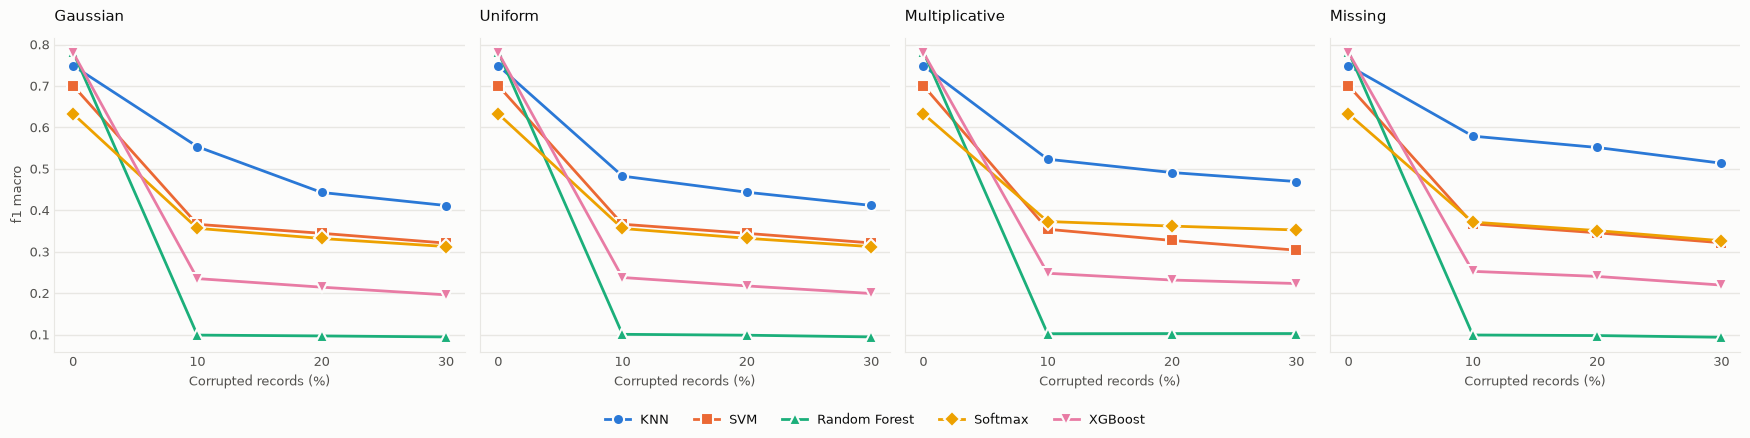

In [148]:
plot_noise_degradation(noise_comparison)

In [ ]:
def plot_noise_retention(degradation: pd.DataFrame) -> None:
    surface, ink, muted = "#fcfcfb", "#0b0b0b", "#52514e"
    ramp = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
    colours = matplotlib.colors.LinearSegmentedColormap.from_list("retention", ramp)

    order = [scenario for _, _, scenario in list_noise_scenarios()]
    table = degradation.pivot_table(index="model", columns="scenario", values="retention")
    table = table.reindex(
        index=[name for name in NOISE_MODEL_COLOURS if name in table.index],
        columns=[scenario for scenario in order if scenario in table.columns],
    )

    values = table.to_numpy(dtype=float)
    low, high = float(np.nanmin(values)), float(np.nanmax(values))
    span = max(high - low, 1e-9)

    figure, axes = plt.subplots(
        figsize=(0.95 * table.shape[1] + 3, 0.55 * table.shape[0] + 2.4)
    )
    figure.patch.set_facecolor(surface)
    image = axes.imshow(values, cmap=colours, vmin=low, vmax=high, aspect="auto")

    axes.set_xticks(range(table.shape[1]))
    axes.set_xticklabels([str(c) for c in table.columns], fontsize=9, rotation=45, ha="right")
    axes.set_yticks(range(table.shape[0]))
    axes.set_yticklabels([str(i) for i in table.index], fontsize=9)
    axes.set_title(
        "Share of the clean score kept under feature noise",
        color=ink, fontsize=11, loc="left", pad=12,
    )
    axes.tick_params(colors=muted, length=0)
    for side in ("top", "right", "bottom", "left"):
        axes.spines[side].set_visible(False)

    axes.set_xticks(np.arange(-0.5, table.shape[1], 1), minor=True)
    axes.set_yticks(np.arange(-0.5, table.shape[0], 1), minor=True)
    axes.grid(which="minor", color=surface, linewidth=2)
    axes.tick_params(which="minor", length=0)

    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            value = values[row, column]
            if np.isnan(value):
                continue
            axes.text(
                column, row, f"{value:.2f}",
                ha="center", va="center", fontsize=9,
                color=surface if (value - low) / span > 0.55 else ink,
            )

    bar = figure.colorbar(image, ax=axes)
    bar.set_label("retention (noisy / clean)", color=muted, fontsize=9)
    bar.ax.tick_params(colors=muted, labelsize=9, length=0)
    bar.outline.set_visible(False)

    figure.tight_layout()
    plt.show()

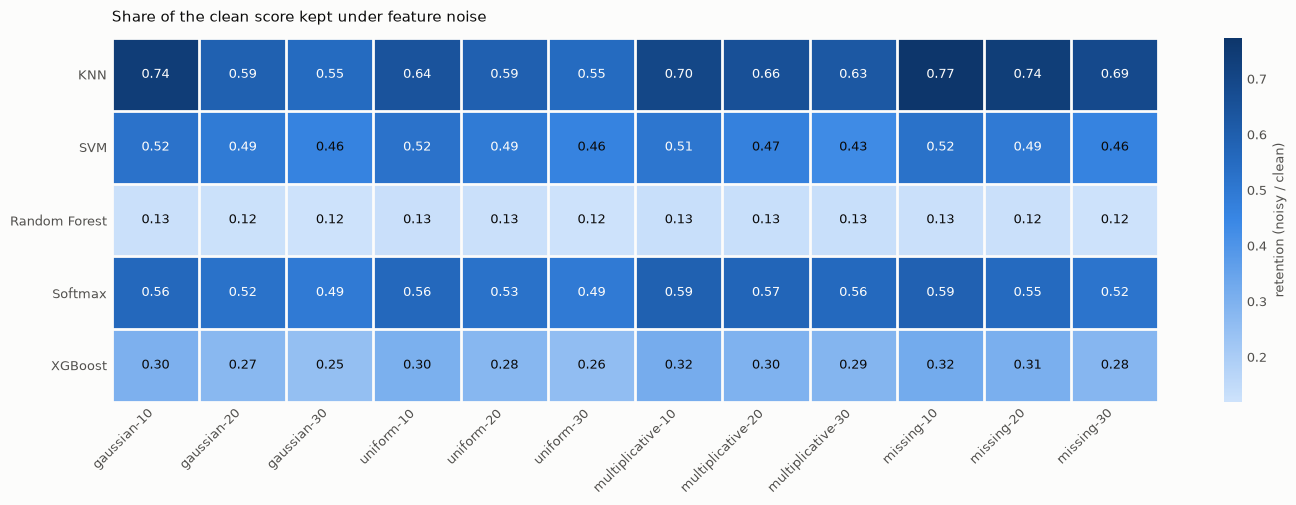

In [150]:
plot_noise_retention(noise_degradation)

## 19.10. Ranking

In [151]:
def rank_noise_robustness(degradation: pd.DataFrame) -> pd.DataFrame:
    ranking = degradation.groupby("model").agg(
        clean=("clean", "first"),
        mean_retention=("retention", "mean"),
        worst_retention=("retention", "min"),
        mean_drop=("drop", "mean"),
        worst_drop=("drop", "max"),
    )
    worst = degradation.loc[degradation.groupby("model")["retention"].idxmin()]
    ranking["worst_scenario"] = worst.set_index("model")["scenario"]

    ranking = ranking.sort_values("mean_retention", ascending=False)
    ranking.insert(0, "rank", range(1, len(ranking) + 1))
    return ranking

In [152]:
noise_ranking = rank_noise_robustness(noise_degradation)
save_search_results(
    noise_ranking.reset_index(), "noise-robustness-ranking.csv", PATH_FOLDER_SEARCH_RESULT
)
noise_ranking.round(4)

Saved search results to hyperparameter-search/noise-robustness-ranking.csv.


,rank,clean,mean_retention,worst_retention,mean_drop,worst_drop,worst_scenario
model,,,,,,,
KNN,1,0.7490,0.6536,0.5495,0.2595,0.3374,gaussian-30
Softmax,2,0.6328,0.5449,0.4935,0.2880,0.3205,uniform-30
SVM,3,0.7009,0.4855,0.4334,0.3606,0.3971,multiplicative-30
XGBoost,4,0.7806,0.2899,0.2510,0.5543,0.5847,gaussian-30
Random Forest,5,0.7825,0.1258,0.1196,0.6840,0.6889,missing-30


## 19.11. Per Class

In [153]:
def compare_noise_per_class_f1(
    scenario: str,
    true_labels,
    subfolders: dict[str, str] | None = None,
    class_names: list[str] | None = None,
) -> pd.DataFrame:
    return compare_per_class_f1(
        MODEL_SUBFOLDERS if subfolders is None else subfolders,
        true_labels,
        get_noise_split_name(scenario),
        CLASS_NAMES if class_names is None else class_names,
    )

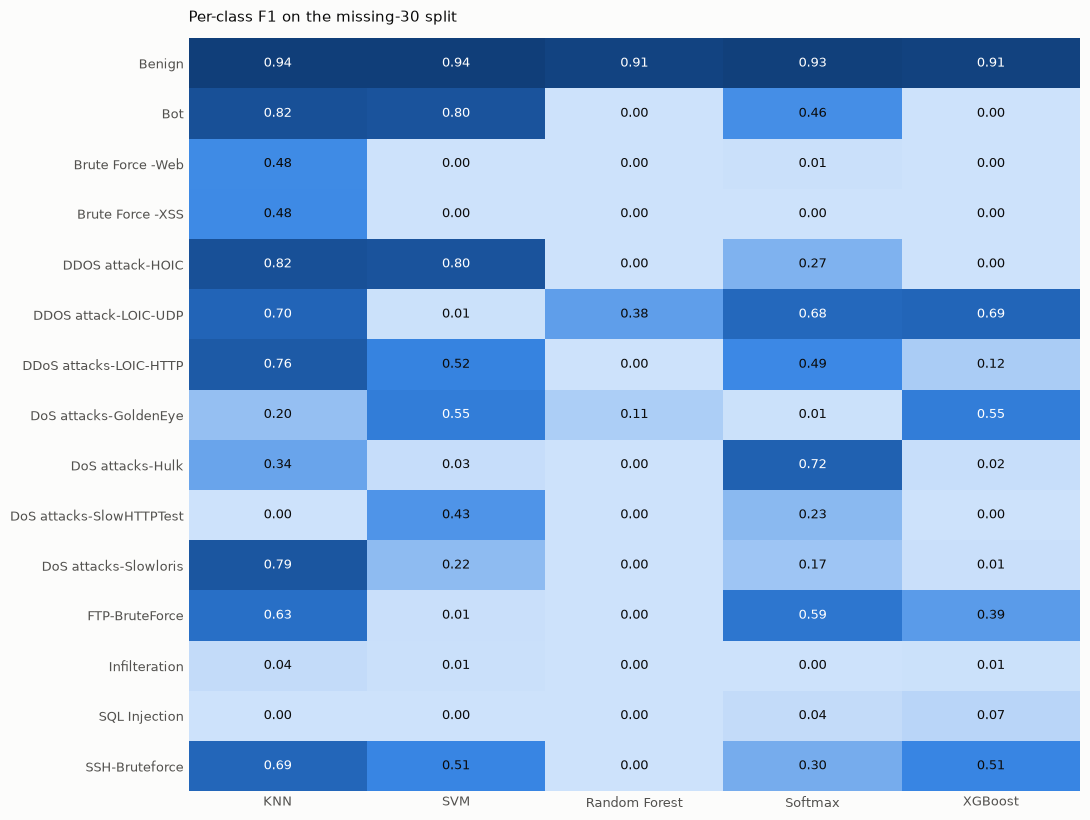

In [154]:
noise_per_class_f1 = compare_noise_per_class_f1("missing-30", test_y)
plot_per_class_f1(noise_per_class_f1, "missing-30")

# 20. Reading the Robustness Test

## 20.1. Settings

In [155]:
PATH_FOLDER_ANALYSIS = "analysis"
PATH_COVERAGE_MASKS = os.path.join(PATH_FOLDER_ANALYSIS, "coverage-masks.npz")

NOISE_POPULATIONS = ("intact", "corrupted")

MASK_PROBE_COMPONENTS = 4

## 20.2. Recovering the Coverage Mask

In [156]:
def recover_coverage_mask(
    scenario: str,
    features_folder_name: str = PATH_FOLDER_IPCA,
    noise_folder_name: str = PATH_FOLDER_NOISE_IPCA,
    split_name: str = NOISE_SPLIT,
    n_components: int = MASK_PROBE_COMPONENTS,
) -> np.ndarray:
    clean_paths = get_split_file_paths(features_folder_name, split_name)
    columns = pl.read_parquet(clean_paths[0]).columns[:n_components]
    noise_split_folder = get_split_folder(
        get_scenario_folder(noise_folder_name, scenario), split_name
    )

    parts = []
    for clean_path in clean_paths:
        clean = pl.read_parquet(clean_path, columns=columns).to_numpy()
        noisy = pl.read_parquet(
            os.path.join(noise_split_folder, os.path.basename(clean_path)), columns=columns
        ).to_numpy()
        parts.append((~np.isclose(noisy, clean, rtol=1e-7, atol=1e-10, equal_nan=True)).any(axis=1))

    return np.concatenate(parts)


def load_coverage_masks(
    scenarios: list[tuple[str, float, str]] | None = None,
    cache_file: str = PATH_COVERAGE_MASKS,
) -> dict[str, np.ndarray]:
    scenarios = list_noise_scenarios() if scenarios is None else scenarios
    names = [scenario for _, _, scenario in scenarios]

    if os.path.exists(cache_file):
        stored = np.load(cache_file)
        if all(name in stored.files for name in names):
            print(f"Read {len(names)} coverage masks from {cache_file}.")
            return {name: stored[name] for name in names}

    masks = {}
    for name in names:
        with step(f"recovering the coverage mask of '{name}'"):
            masks[name] = recover_coverage_mask(name)
        print(f"    {masks[name].mean() * 100:.3f}% of records corrupted")

    os.makedirs(os.path.dirname(cache_file), exist_ok=True)
    np.savez_compressed(cache_file, **masks)
    print(f"Saved {len(masks)} coverage masks to {cache_file}.")
    return masks

In [157]:
coverage_masks = load_coverage_masks()

for _, intensity, scenario in list_noise_scenarios():
    share = float(coverage_masks[scenario].mean())
    assert abs(share - intensity) < 1e-4, f"{scenario}: {share:.5f} corrupted, expected {intensity}"

print(f"All {len(coverage_masks)} masks match the coverage their scenario name claims.")

Read 12 coverage masks from analysis/coverage-masks.npz.
All 12 masks match the coverage their scenario name claims.


## 20.3. Auditing the Stored Baselines

`disagreement` must be **zero**. Anything else means the stored clean baseline and the noise pass came from different models — use `recovered_clean` instead of the 18.1 baseline.

In [158]:
def audit_noise_baselines(
    true_labels=None,
    scenarios: list[tuple[str, float, str]] | None = None,
    models: list[str] | None = None,
    masks: dict[str, np.ndarray] | None = None,
) -> pd.DataFrame:
    true = to_labels(test_y if true_labels is None else true_labels)
    scenarios = list_noise_scenarios() if scenarios is None else scenarios
    models = list(MODEL_SUBFOLDERS) if models is None else models
    masks = coverage_masks if masks is None else masks

    rows = []
    for model_name in models:
        subfolder = MODEL_SUBFOLDERS[model_name]
        try:
            baseline = load_prediction_chunks(
                get_prediction_folder(subfolder, get_noise_split_name(NOISE_BASELINE))
            )
        except FileNotFoundError:
            print(f"{model_name}: no cached clean predictions, skipped.")
            continue

        for _, _, scenario in scenarios:
            folder = get_prediction_folder(subfolder, get_noise_split_name(scenario))
            try:
                pred = load_prediction_chunks(folder)
            except FileNotFoundError:
                continue

            intact = ~masks[scenario]
            rows.append(
                {
                    "model": model_name,
                    "scenario": scenario,
                    "disagreement": float((baseline[intact] != pred[intact]).mean()),
                    "stored_clean": float((baseline == true).mean()),
                    "recovered_clean": float((pred[intact] == true[intact]).mean()),
                }
            )

    return pd.DataFrame(rows)

In [159]:
noise_baseline_audit = audit_noise_baselines()
noise_baseline_audit.groupby("model", sort=False).agg(
    disagreement=("disagreement", "mean"),
    stored_clean=("stored_clean", "first"),
    recovered_clean=("recovered_clean", "mean"),
).round(4)

,disagreement,stored_clean,recovered_clean
model,,,
KNN,0.0830,0.9800,0.9020
SVM,0.0736,0.9792,0.9163
Random Forest,0.1619,0.9836,0.8310
Softmax,0.0854,0.9633,0.8889
XGBoost,0.1469,0.9839,0.8454


## 20.4. The Two Populations

In [160]:
def score_noise_populations(
    true_labels=None,
    scenarios: list[tuple[str, float, str]] | None = None,
    models: list[str] | None = None,
    masks: dict[str, np.ndarray] | None = None,
) -> pd.DataFrame:
    true = to_labels(test_y if true_labels is None else true_labels)
    scenarios = list_noise_scenarios() if scenarios is None else scenarios
    models = list(MODEL_SUBFOLDERS) if models is None else models
    masks = coverage_masks if masks is None else masks
    labels = get_noise_labels()

    rows = []
    for noise_type, intensity, scenario in scenarios:
        for model_name in models:
            folder = get_prediction_folder(
                MODEL_SUBFOLDERS[model_name], get_noise_split_name(scenario)
            )
            try:
                pred = load_prediction_chunks(folder)
            except FileNotFoundError:
                print(f"{model_name} / {scenario}: no cached predictions, skipped.")
                continue

            corrupted = masks[scenario]
            for population, selected in (("intact", ~corrupted), ("corrupted", corrupted)):
                scores = evaluate(pred=pred[selected], true=true[selected], labels=labels).iloc[0]
                rows.append(
                    {
                        "model": model_name,
                        "noise": noise_type,
                        "intensity": intensity,
                        "scenario": scenario,
                        "population": population,
                        **{name: float(value) for name, value in scores.items()},
                        "rows": int(selected.sum()),
                    }
                )

    return pd.DataFrame(rows)

In [161]:
noise_populations = score_noise_populations()
save_search_results(noise_populations, "noise-populations.csv", PATH_FOLDER_SEARCH_RESULT)
noise_populations.head(10)

Saved search results to hyperparameter-search/noise-populations.csv.


,model,noise,intensity,scenario,population,accuracy,precision_macro,recall_macro,f1_macro,rows
0,KNN,gaussian,0.1,gaussian-10,intact,0.921446,0.627622,0.661781,0.552584,2921931
1,KNN,gaussian,0.1,gaussian-10,corrupted,0.921522,0.641025,0.653675,0.562953,324663
2,SVM,gaussian,0.1,gaussian-10,intact,0.916248,0.608857,0.355310,0.386697,2921931
3,SVM,gaussian,0.1,gaussian-10,corrupted,0.828955,0.210620,0.067206,0.061778,324663
4,Random Forest,gaussian,0.1,gaussian-10,intact,0.831046,0.291765,0.098362,0.101495,2921931
5,Random Forest,gaussian,0.1,gaussian-10,corrupted,0.830603,0.099818,0.070270,0.067164,324663
6,Softmax,gaussian,0.1,gaussian-10,intact,0.888876,0.468649,0.424258,0.385836,2921931
7,Softmax,gaussian,0.1,gaussian-10,corrupted,0.507686,0.242070,0.298438,0.217026,324663
8,XGBoost,gaussian,0.1,gaussian-10,intact,0.845450,0.453262,0.238231,0.259928,2921931
9,XGBoost,gaussian,0.1,gaussian-10,corrupted,0.800741,0.251041,0.122140,0.088281,324663


In [162]:
def pivot_noise_populations(
    populations: pd.DataFrame, score_column: str = SCORE_COLUMN
) -> pd.DataFrame:
    table = populations.pivot_table(
        index="model", columns=["population", "noise"], values=score_column
    )
    return table.reindex(
        index=[name for name in MODEL_SUBFOLDERS if name in table.index],
        columns=pd.MultiIndex.from_product([list(NOISE_POPULATIONS), list(NOISE_TYPES)]),
    )

In [163]:
pivot_noise_populations(noise_populations).round(4)

intact                                corrupted          \
              gaussian uniform multiplicative missing  gaussian uniform   
model                                                                     
KNN             0.5905  0.6128         0.6110  0.6112    0.3083  0.1791   
SVM             0.3871  0.3867         0.3864  0.3864    0.0619  0.0613   
Random Forest   0.1022  0.1034         0.1025  0.1027    0.0648  0.0672   
Softmax         0.3858  0.3881         0.3887  0.3881    0.2058  0.2010   
XGBoost         0.2590  0.2632         0.2646  0.2648    0.0880  0.0894   

                                      
              multiplicative missing  
model                                 
KNN                   0.3006  0.0605  
SVM                   0.1672  0.0605  
Random Forest         0.1004  0.0605  
Softmax               0.2815  0.0605  
XGBoost               0.1442  0.0605

## 20.5. The Mixture Identity

In [164]:
def measure_mixture_residual(
    populations: pd.DataFrame, folder_name: str = PATH_FOLDER_NOISE_SCORES
) -> pd.DataFrame:
    rows = []
    for (model_name, scenario), group in populations.groupby(["model", "scenario"], sort=False):
        stored = load_noise_score(model_name, scenario, folder_name)
        if stored is None:
            continue

        indexed = group.set_index("population")
        share = float(indexed["intensity"].iloc[0])
        mixed = (
            (1.0 - share) * float(indexed.loc["intact", "accuracy"])
            + share * float(indexed.loc["corrupted", "accuracy"])
        )
        rows.append(
            {
                "model": model_name,
                "scenario": scenario,
                "scored": float(stored["accuracy"]),
                "mixed": mixed,
                "residual": float(stored["accuracy"]) - mixed,
            }
        )

    return pd.DataFrame(rows)

In [165]:
noise_mixture = measure_mixture_residual(noise_populations)
print(f"largest residual over {len(noise_mixture)} passes: {noise_mixture['residual'].abs().max():.3e}")
noise_mixture.head(10)

largest residual over 60 passes: 4.970e-07


,model,scenario,scored,mixed,residual
0,KNN,gaussian-10,0.921454,0.921454,8.342227e-11
1,SVM,gaussian-10,0.907518,0.907518,-9.679474e-08
2,Random Forest,gaussian-10,0.831002,0.831002,-4.917865e-10
3,Softmax,gaussian-10,0.850757,0.850757,-4.226836e-07
4,XGBoost,gaussian-10,0.840979,0.840979,-4.957547e-08
5,KNN,gaussian-20,0.879072,0.879072,-3.928052e-08
6,SVM,gaussian-20,0.898804,0.898804,-3.235077e-08
7,Random Forest,gaussian-20,0.830975,0.830975,-2.656904e-10
8,Softmax,gaussian-20,0.812442,0.812442,-1.413492e-07
9,XGBoost,gaussian-20,0.836531,0.836531,-1.652729e-08


## 20.6. Per Class

In [166]:
def compare_population_per_class(
    scenario: str,
    population: str,
    true_labels=None,
    masks: dict[str, np.ndarray] | None = None,
    subfolders: dict[str, str] | None = None,
    class_names: list[str] | None = None,
    metric: str = "f1",
) -> pd.DataFrame:
    true = to_labels(test_y if true_labels is None else true_labels)
    masks = coverage_masks if masks is None else masks
    subfolders = MODEL_SUBFOLDERS if subfolders is None else subfolders
    class_names = CLASS_NAMES if class_names is None else class_names

    corrupted = masks[scenario]
    selected = corrupted if population == "corrupted" else ~corrupted

    columns = {}
    for model_name, subfolder in subfolders.items():
        folder = get_prediction_folder(subfolder, get_noise_split_name(scenario))
        try:
            pred = load_prediction_chunks(folder)
        except FileNotFoundError:
            print(f"{model_name}: no cached predictions for {scenario}, skipped.")
            continue

        report = get_classification_report(
            pred=pred[selected], true=true[selected], class_names=class_names
        )
        columns[model_name] = report.set_index("class")[metric]

    return pd.DataFrame(columns).reindex(class_names)

In [167]:
compare_population_per_class("gaussian-30", "corrupted").round(3)

,KNN,SVM,Random Forest,Softmax,XGBoost
class,,,,,
Benign,0.894,0.907,0.907,0.681,0.895
Bot,0.058,0.005,0.000,0.105,0.001
Brute Force -Web,0.003,0.000,0.000,0.001,0.000
Brute Force -XSS,0.001,0.000,0.000,0.001,0.000
DDOS attack-HOIC,0.187,0.000,0.000,0.210,0.001
DDOS attack-LOIC-UDP,0.041,0.000,0.065,0.484,0.318
DDoS attacks-LOIC-HTTP,0.138,0.005,0.000,0.277,0.000
DoS attacks-GoldenEye,0.105,0.006,0.000,0.035,0.020
DoS attacks-Hulk,0.075,0.002,0.000,0.186,0.001


## 20.7. Conditional Confusion and Error Composition

In [168]:
def build_conditional_confusion(
    model_name: str,
    scenario: str,
    population: str,
    true_labels=None,
    masks: dict[str, np.ndarray] | None = None,
    labels: list[int] | None = None,
) -> np.ndarray:
    true = to_labels(test_y if true_labels is None else true_labels)
    masks = coverage_masks if masks is None else masks
    labels = get_noise_labels() if labels is None else labels

    pred = load_prediction_chunks(
        get_prediction_folder(MODEL_SUBFOLDERS[model_name], get_noise_split_name(scenario))
    )
    corrupted = masks[scenario]
    selected = corrupted if population == "corrupted" else ~corrupted

    return confusion_matrix(true[selected], pred[selected], labels=labels)


def measure_error_composition(
    population: str = "corrupted",
    scenarios: list[tuple[str, float, str]] | None = None,
    models: list[str] | None = None,
    benign_label: int = 0,
    **kwargs,
) -> pd.DataFrame:
    scenarios = list_noise_scenarios() if scenarios is None else scenarios
    models = list(MODEL_SUBFOLDERS) if models is None else models

    rows = []
    for model_name in models:
        for noise_type in NOISE_TYPES:
            matrices = [
                build_conditional_confusion(model_name, scenario, population, **kwargs)
                for kind, _, scenario in scenarios
                if kind == noise_type
            ]
            if not matrices:
                continue

            matrix = np.sum(matrices, axis=0).astype(float)
            attack = [i for i in range(matrix.shape[0]) if i != benign_label]
            errors = matrix.sum() - np.trace(matrix)
            if errors == 0:
                continue

            attack_block = matrix[np.ix_(attack, attack)]
            rows.append(
                {
                    "model": model_name,
                    "noise": noise_type,
                    "error_rate": float(errors / matrix.sum()),
                    "attack_to_benign": float(matrix[attack, benign_label].sum() / errors),
                    "attack_to_attack": float((attack_block.sum() - np.trace(attack_block)) / errors),
                    "benign_to_attack": float(matrix[benign_label, attack].sum() / errors),
                }
            )

    return pd.DataFrame(rows)

In [169]:
noise_error_composition = measure_error_composition()
save_search_results(noise_error_composition, "noise-error-composition.csv", PATH_FOLDER_SEARCH_RESULT)
noise_error_composition.round(4)

Saved search results to hyperparameter-search/noise-error-composition.csv.


,model,noise,error_rate,attack_to_benign,attack_to_attack,benign_to_attack
0,KNN,gaussian,0.1846,0.6156,0.1102,0.2742
1,KNN,uniform,0.2062,0.6225,0.1049,0.2726
2,KNN,multiplicative,0.1637,0.6527,0.1222,0.2251
3,KNN,missing,0.1692,1.0000,0.0000,0.0000
4,SVM,gaussian,0.1711,0.9782,0.0113,0.0106
5,SVM,uniform,0.1703,0.9845,0.0080,0.0075
6,SVM,multiplicative,0.1669,0.6030,0.2088,0.1883
7,SVM,missing,0.1692,1.0000,0.0000,0.0000
8,Random Forest,gaussian,0.1695,1.0000,0.0000,0.0000
9,Random Forest,uniform,0.1691,1.0000,0.0000,0.0000


## 20.8. Plots

In [170]:
NOISE_POPULATION_COLOURS = {"intact": "#2a78d6", "corrupted": "#eb6834"}

NOISE_SURFACE, NOISE_GRID = "#fcfcfb", "#e8e7e3"
NOISE_INK, NOISE_MUTED = "#0b0b0b", "#52514e"


def _dress(axes, title: str | None = None, xlabel: str | None = None, ylabel: str | None = None):
    axes.set_facecolor(NOISE_SURFACE)
    for side in ("top", "right"):
        axes.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        axes.spines[side].set_color(NOISE_GRID)
    axes.tick_params(colors=NOISE_MUTED, length=0, labelsize=8)
    axes.grid(color=NOISE_GRID, linewidth=0.7)
    axes.set_axisbelow(True)
    if title:
        axes.set_title(title, color=NOISE_INK, fontsize=10, loc="left", pad=8)
    if xlabel:
        axes.set_xlabel(xlabel, color=NOISE_MUTED, fontsize=9)
    if ylabel:
        axes.set_ylabel(ylabel, color=NOISE_MUTED, fontsize=9)

In [171]:
def plot_baseline_audit(audit: pd.DataFrame) -> None:
    summary = audit.groupby("model", sort=False).agg(
        stored=("stored_clean", "first"),
        recovered=("recovered_clean", "mean"),
        disagreement=("disagreement", "mean"),
    )
    summary = summary.reindex([name for name in MODEL_SUBFOLDERS if name in summary.index])
    models = list(summary.index)
    positions = np.arange(len(models))
    width = 0.36

    figure, (left, right) = plt.subplots(1, 2, figsize=(12.5, 4.4))
    figure.patch.set_facecolor(NOISE_SURFACE)

    for offset, column, population in (
        (-width / 2 - 0.01, "stored", "intact"),
        (+width / 2 + 0.01, "recovered", "corrupted"),
    ):
        values = summary[column].to_numpy(dtype=float)
        left.bar(
            positions + offset, values, width,
            color=NOISE_POPULATION_COLOURS[population], zorder=3,
            label="stored test/ baseline" if column == "stored" else "recovered (model on disk)",
        )
        for position, value in zip(positions + offset, values):
            left.text(position, value + 0.008, f"{value:.3f}", ha="center", fontsize=7.5, color=NOISE_MUTED)

    benign_share = float((to_labels(test_y) == 0).mean())
    left.axhline(benign_share, color=NOISE_MUTED, ls=(0, (4, 3)), lw=1.1, zorder=2)
    left.text(-0.45, benign_share - 0.016, f"all-Benign = {benign_share:.3f}",
              ha="left", fontsize=7.5, color=NOISE_MUTED)
    left.set_xticks(positions)
    left.set_xticklabels(models, rotation=18, ha="right")
    left.set_ylim(0.75, 1.06)
    left.legend(frameon=False, fontsize=8, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.16))
    _dress(left, "a. Clean accuracy: stored vs actual", ylabel="accuracy")

    shares = summary["disagreement"].to_numpy(dtype=float) * 100
    right.barh(positions, shares, 0.55,
               color=[NOISE_MODEL_COLOURS.get(name, "#2a78d6") for name in models], zorder=3)
    for position, value in zip(positions, shares):
        right.text(value + 0.25, position, f"{value:.2f}%", va="center", fontsize=8, color=NOISE_MUTED)
    right.set_yticks(positions)
    right.set_yticklabels(models)
    right.invert_yaxis()
    right.set_xlim(0, max(shares.max(), 1.0) * 1.25)
    _dress(right, "b. Disagreement on records that were never corrupted",
           xlabel="share of intact records predicted differently (%)")
    right.text(0.99, -0.20,
               "these records' features are bit-identical to the clean split,\n"
               "so a correctly-paired baseline would read 0.00%",
               transform=right.transAxes, ha="right", va="top",
               fontsize=7.5, color=NOISE_MUTED, style="italic")

    figure.tight_layout()
    plt.show()

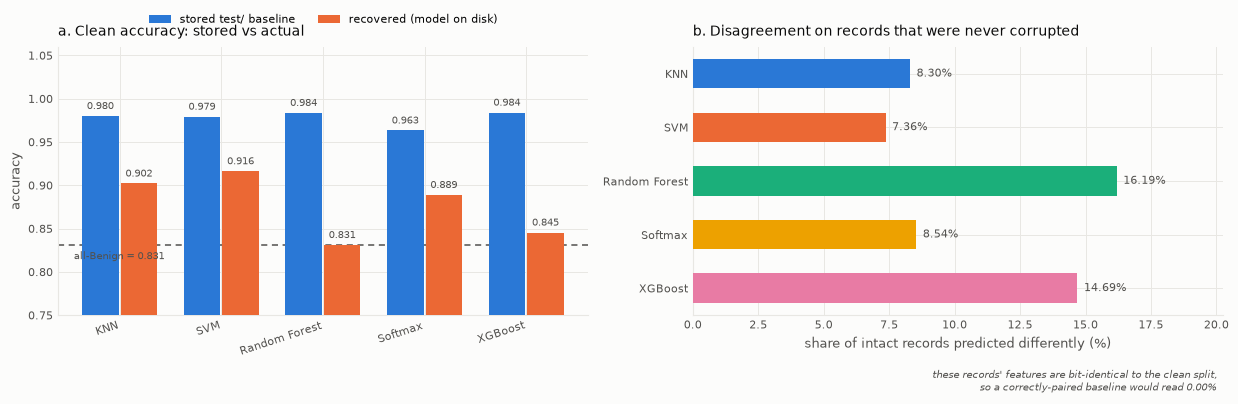

In [172]:
plot_baseline_audit(noise_baseline_audit)

In [173]:
def plot_mixture_parity(mixture: pd.DataFrame) -> None:
    figure, axes = plt.subplots(figsize=(5.6, 5.0))
    figure.patch.set_facecolor(NOISE_SURFACE)

    low = float(min(mixture["mixed"].min(), mixture["scored"].min())) - 0.01
    high = float(max(mixture["mixed"].max(), mixture["scored"].max())) + 0.01
    axes.plot([low, high], [low, high], color=NOISE_MUTED, ls=(0, (4, 3)), lw=1.1, zorder=2)

    for model_name in MODEL_SUBFOLDERS:
        rows = mixture[mixture["model"] == model_name]
        if rows.empty:
            continue
        axes.scatter(
            rows["mixed"], rows["scored"], s=46,
            color=NOISE_MODEL_COLOURS.get(model_name, "#2a78d6"),
            marker=NOISE_MODEL_MARKERS.get(model_name, "o"),
            edgecolor=NOISE_SURFACE, linewidth=1.2, label=model_name, zorder=3,
        )

    axes.text(0.04, 0.95, f"largest residual over all {len(mixture)} passes: "
                          f"{mixture['residual'].abs().max():.1e}",
              transform=axes.transAxes, fontsize=8, color=NOISE_MUTED)
    axes.legend(frameon=False, fontsize=8, loc="lower right")
    _dress(axes, "Pooled accuracy is the mixture of the two populations",
           xlabel=r"$(1-p)\cdot$acc$_{intact} + p\cdot$acc$_{corrupted}$",
           ylabel="pooled accuracy as scored in 19.8")

    figure.tight_layout()
    plt.show()

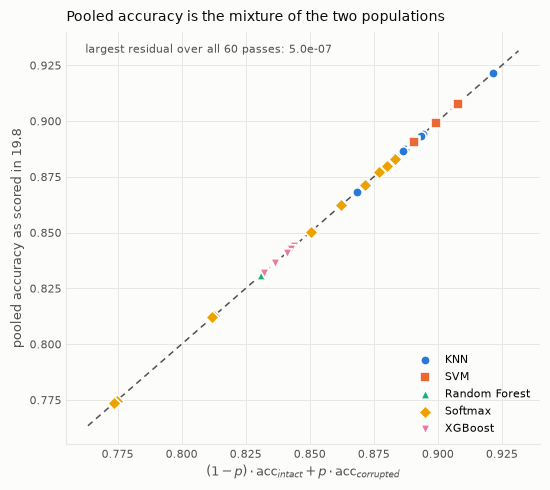

In [174]:
plot_mixture_parity(noise_mixture)

In [175]:
def plot_noise_populations(
    populations: pd.DataFrame, score_column: str = SCORE_COLUMN
) -> None:
    models = [name for name in MODEL_SUBFOLDERS if name in set(populations["model"])]
    short = {"Random Forest": "RF", "XGBoost": "XGB"}
    positions = np.arange(len(models))
    width = 0.36

    figure, axes_row = plt.subplots(1, len(NOISE_TYPES), figsize=(3.7 * len(NOISE_TYPES), 4.2), sharey=True)
    figure.patch.set_facecolor(NOISE_SURFACE)

    for axes, noise_type in zip(np.atleast_1d(axes_row), NOISE_TYPES):
        panel = populations[populations["noise"] == noise_type]
        for offset, population in ((-width / 2 - 0.01, "intact"), (+width / 2 + 0.01, "corrupted")):
            values = [
                panel[(panel["model"] == name) & (panel["population"] == population)][score_column].mean()
                for name in models
            ]
            axes.bar(
                positions + offset, values, width, zorder=3,
                color=NOISE_POPULATION_COLOURS[population],
                label=population if noise_type == NOISE_TYPES[0] else None,
            )
        axes.set_xticks(positions)
        axes.set_xticklabels([short.get(name, name) for name in models], fontsize=8.5)
        _dress(axes, noise_type, ylabel=score_column if noise_type == NOISE_TYPES[0] else None)

    np.atleast_1d(axes_row)[0].legend(frameon=False, fontsize=8, loc="upper right")
    figure.suptitle(
        f"{score_column} on uncorrupted vs corrupted records of the same run",
        x=0.5, y=1.02, fontsize=10.5, color=NOISE_INK,
    )
    figure.tight_layout()
    plt.show()

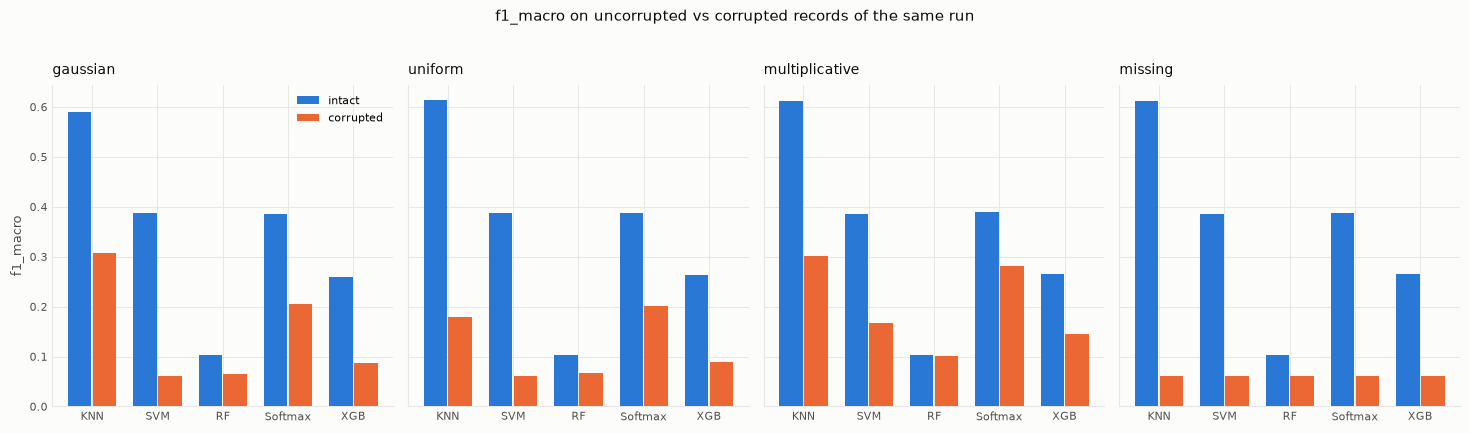

In [176]:
plot_noise_populations(noise_populations)

In [177]:
def plot_population_confusion(
    model_name: str,
    scenario: str,
    class_names: list[str] | None = None,
    **kwargs,
) -> None:
    class_names = CLASS_NAMES if class_names is None else class_names
    ramp = ["#eef4fd", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
    colours = matplotlib.colors.LinearSegmentedColormap.from_list("confusion", ramp)

    figure, axes_row = plt.subplots(1, 2, figsize=(13, 5.9))
    figure.patch.set_facecolor(NOISE_SURFACE)

    for axes, population in zip(axes_row, NOISE_POPULATIONS):
        matrix = build_conditional_confusion(model_name, scenario, population, **kwargs).astype(float)
        shares = matrix / np.clip(matrix.sum(axis=1, keepdims=True), 1, None)
        image = axes.imshow(shares, cmap=colours, vmin=0.0, vmax=1.0, aspect="auto")

        for row in range(shares.shape[0]):
            for column in range(shares.shape[1]):
                value = shares[row, column]
                if value < 0.005:
                    continue
                axes.text(
                    column, row, "1.0" if value >= 0.995 else f"{value:.2f}"[1:],
                    ha="center", va="center", fontsize=6,
                    color="#ffffff" if value > 0.55 else NOISE_INK,
                )

        axes.set_xticks(range(len(class_names)))
        axes.set_xticklabels(class_names, rotation=90, fontsize=7)
        axes.set_yticks(range(len(class_names)))
        axes.set_yticklabels(class_names if population == "intact" else [], fontsize=7)
        axes.grid(False)
        axes.tick_params(colors=NOISE_MUTED, length=0)
        for side in ("top", "right", "bottom", "left"):
            axes.spines[side].set_visible(False)
        axes.set_title(f"{model_name}, {scenario} — {population} records",
                       color=NOISE_INK, fontsize=10, loc="left", pad=8)
        axes.set_xlabel("predicted", color=NOISE_MUTED, fontsize=9)
        if population == "intact":
            axes.set_ylabel("true", color=NOISE_MUTED, fontsize=9)

    figure.colorbar(image, ax=axes_row, fraction=0.02, pad=0.02,
                    label="share of the true class's records")
    plt.show()

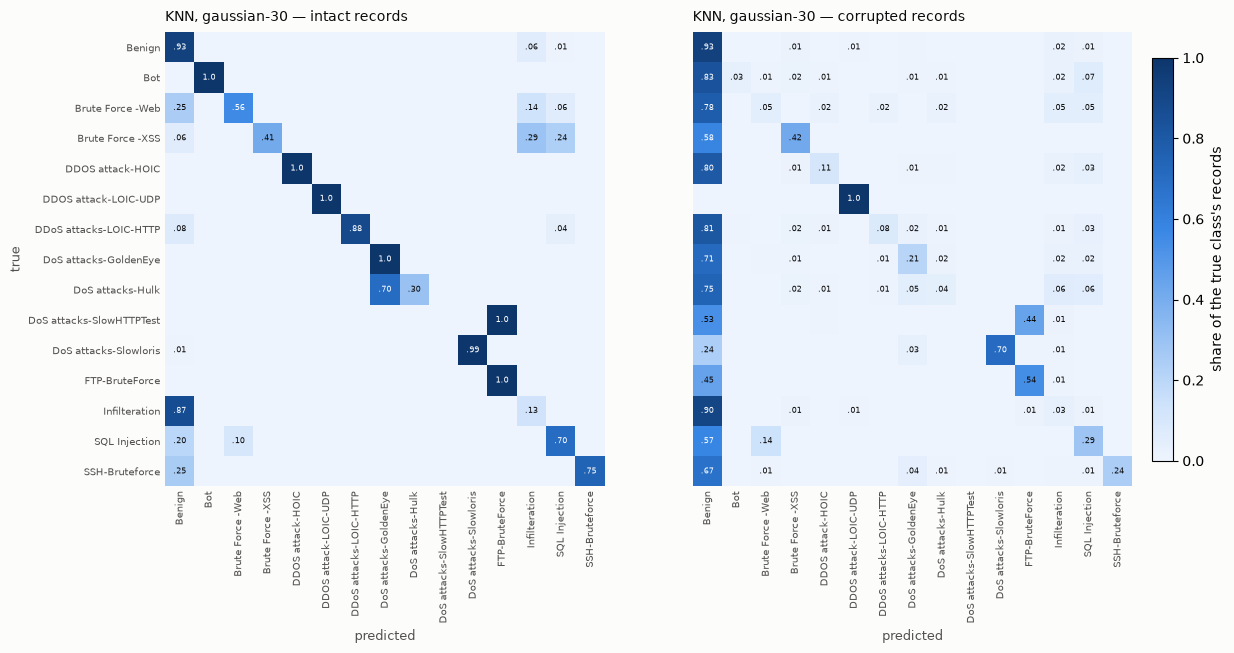

In [178]:
plot_population_confusion("KNN", "gaussian-30")